# 1. <a id='toc1_'></a>[科学技術計算7](#toc0_)

この演習トピックでは，非線形方程式および最小二乗法の数値解法について学ぶ．まず，非線形連立方程式の定式化と，1次元の球根法であるニュートン法やセカント法などを学ぶ．次に多次元の球根法であるニュートン法，準ニュートン法の一つのBroyden法などを理解した後，非線形最小二乗問題に特化した最適化手法であるGauss-Newton法とLevenberg-Marquardt法を理解する．さらに，線形最小二乗問題の解法として正規方程式，リッジ回帰，および特異値分解（SVD）を用いた擬似逆行列を学ぶ．


In [1]:
import numpy as np
# from numpy import , cos, sin

import scipy

from numpy.linalg import inv, norm, solve, det, matrix_rank, cond
from numpy import diag
rng = np.random.default_rng()

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams["savefig.bbox"] = "tight"

from typing import List, Optional, Union, Tuple, Dict


**目次**<a id='toc0_'></a>    
- 1. [科学技術計算7](#toc1_)    
  - 1.1. [非線形連立方程式の定式化](#toc1_1_)    
    - 1.1.1. [最適化問題との関連](#toc1_1_1_)    
    - 1.1.2. [不動点問題](#toc1_1_2_)    
  - 1.2. [1次元（$m=1$）](#toc1_2_)    
    - 1.2.1. [ニュートン法](#toc1_2_1_)    
      - 1.2.1.1. [ニュートン法のアルゴリズム](#toc1_2_1_1_)    
      - 1.2.1.2. [更新式の導出](#toc1_2_1_2_)    
      - 1.2.1.3. [実装](#toc1_2_1_3_)    
      - 1.2.1.4. [コールバック](#toc1_2_1_4_)    
      - 1.2.1.5. [ニュートン法の実装](#toc1_2_1_5_)    
      - 1.2.1.6. [scipy の 1 次元ニュートン法ソルバー](#toc1_2_1_6_)    
    - 1.2.2. [セカント法](#toc1_2_2_)    
      - 1.2.2.1. [セカント法のアルゴリズム](#toc1_2_2_1_)    
      - 1.2.2.2. [scipy のセカント法ソルバー](#toc1_2_2_2_)    
    - 1.2.3. [Halley法](#toc1_2_3_)    
      - 1.2.3.1. [scipy のHalley法ソルバー](#toc1_2_3_1_)    
    - 1.2.4. [2分法](#toc1_2_4_)    
      - 1.2.4.1. [scipy の 2 分法ソルバー](#toc1_2_4_1_)    
    - 1.2.5. [Brent法](#toc1_2_5_)    
      - 1.2.5.1. [scipy のBrent法ソルバー](#toc1_2_5_1_)    
  - 1.3. [多次元（$m=n$）](#toc1_3_)    
    - 1.3.1. [ニュートン法](#toc1_3_1_)    
      - 1.3.1.1. [ニュートン法のアルゴリズム](#toc1_3_1_1_)    
      - 1.3.1.2. [関数の実装](#toc1_3_1_2_)    
      - 1.3.1.3. [等高線の描画](#toc1_3_1_3_)    
      - 1.3.1.4. [コールバック](#toc1_3_1_4_)    
      - 1.3.1.5. [ニュートン法の実装](#toc1_3_1_5_)    
    - 1.3.2. [準ニュートン法：Broyden法](#toc1_3_2_)    
      - 1.3.2.1. [Broyden法のアルゴリズム](#toc1_3_2_1_)    
      - 1.3.2.2. [Broyden法の実装](#toc1_3_2_2_)    
      - 1.3.2.3. [scipyの実装](#toc1_3_2_3_)    
    - 1.3.3. [信頼領域法：Powell法](#toc1_3_3_)    
  - 1.4. [多次元（$m \neq n$）](#toc1_4_)    
    - 1.4.1. [非線形最小二乗問題](#toc1_4_1_)    
    - 1.4.2. [最小二乗問題のヘッセ行列の導出と近似](#toc1_4_2_)    
      - 1.4.2.1. [$m=1$の場合](#toc1_4_2_1_)    
      - 1.4.2.2. [$m > 1$の場合](#toc1_4_2_2_)    
    - 1.4.3. [Gauss-Newton法（GN）](#toc1_4_3_)    
      - 1.4.3.1. [GN法のアルゴリズム](#toc1_4_3_1_)    
    - 1.4.4. [Levenberg-Marquardt法（LM）](#toc1_4_4_)    
      - 1.4.4.1. [LM法のアルゴリズム](#toc1_4_4_1_)    
      - 1.4.4.2. [等高線の描画](#toc1_4_4_2_)    
        - 1.4.4.2.1. [3つの非線形関数を重ねてプロットする](#toc1_4_4_2_1_)    
        - 1.4.4.2.2. [目的関数のノルムの二乗をプロットする](#toc1_4_4_2_2_)    
        - 1.4.4.2.3. [非線形関数と目的関数のプロットを重ねる](#toc1_4_4_2_3_)    
      - 1.4.4.3. [Levenberg-Marquardt法の実装](#toc1_4_4_3_)    
      - 1.4.4.4. [scipyの実装](#toc1_4_4_4_)    
    - 1.4.5. [最小二乗法による解釈](#toc1_4_5_)    
      - 1.4.5.1. [連立方程式の最小二乗解](#toc1_4_5_1_)    
      - 1.4.5.2. [リッジ回帰](#toc1_4_5_2_)    
  - 1.5. [最小二乗法とその解法](#toc1_5_)    
    - 1.5.1. [最小二乗解](#toc1_5_1_)    
    - 1.5.2. [最小ノルム解](#toc1_5_2_)    
    - 1.5.3. [numpy/scipyの実装](#toc1_5_3_)    
    - 1.5.4. [最小二乗解とQR分解](#toc1_5_4_)    
      - 1.5.4.1. [正規方程式による解法](#toc1_5_4_1_)    
      - 1.5.4.2. [QR分解による解法](#toc1_5_4_2_)    
      - 1.5.4.3. [注意：QR分解による解法の補足](#toc1_5_4_3_)    
  - 1.6. [一般逆行列と特異値分解](#toc1_6_)    
    - 1.6.1. [一般逆行列・擬似逆行列](#toc1_6_1_)    
      - 1.6.1.1. [Moore-Penrose擬似逆行列](#toc1_6_1_1_)    
    - 1.6.2. [numpy/scipyの実装](#toc1_6_2_)    
    - 1.6.3. [擬似逆行列を用いたGauss-Newton法](#toc1_6_3_)    
      - 1.6.3.1. [Newton法に一致する例（$n = m = 2$の場合）](#toc1_6_3_1_)    
      - 1.6.3.2. [Gauss-Newton法に一致する例（$n=2, m=3$の場合）](#toc1_6_3_2_)    
    - 1.6.4. [SVDと擬似逆行列](#toc1_6_4_)    
      - 1.6.4.1. [SVDの復習](#toc1_6_4_1_)    
      - 1.6.4.2. [フルランクの場合](#toc1_6_4_2_)    
        - 1.6.4.2.1. [優決定（$m > n$）の場合](#toc1_6_4_2_1_)    
        - 1.6.4.2.2. [劣決定（$m < n$）の場合](#toc1_6_4_2_2_)    
      - 1.6.4.3. [ランク落ちの場合](#toc1_6_4_3_)    
      - 1.6.4.4. [scipyとnumpyの実装](#toc1_6_4_4_)    
  - 1.7. [$A \boldsymbol{x} = 0$](#toc1_7_)    
    - 1.7.1. [連立方程式の解法](#toc1_7_1_)    
      - 1.7.1.1. [最小二乗解](#toc1_7_1_1_)    
      - 1.7.1.2. [リッジ回帰](#toc1_7_1_2_)    
      - 1.7.1.3. [最小ノルム解](#toc1_7_1_3_)    
    - 1.7.2. [勾配法による最適化](#toc1_7_2_)    
      - 1.7.2.1. [ニュートン法](#toc1_7_2_1_)    
      - 1.7.2.2. [ニュートン法＋固定ステップサイズ](#toc1_7_2_2_)    
      - 1.7.2.3. [最急降下法](#toc1_7_2_3_)    
    - 1.7.3. [解：最小固有値に対応する固有ベクトル](#toc1_7_3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## 1.1. <a id='toc1_1_'></a>[非線形連立方程式の定式化](#toc0_)

$n$次元ベクトル$\boldsymbol{x} \in R^n$が与えられているとする．ここで，ベクトル値関数$\boldsymbol{f}(\boldsymbol{x}) \in R^m$について，次の関係を満たす$\boldsymbol{x}$を求める問題を考える．

$$
\boldsymbol{f}(\boldsymbol{x}) = \boldsymbol{0}
$$

このような$\boldsymbol{x}$を**解**（solution）または**根**（root）と呼ぶ．この問題は**非線形連立方程式**（nonlinear system of equations）または**求根**（root finding）と呼ばれる．

- https://en.wikipedia.org/wiki/Root-finding_algorithm
    > In numerical analysis, a root-finding algorithm is an algorithm for finding zeros, also called "roots", of continuous functions.



### 1.1.1. <a id='toc1_1_1_'></a>[最適化問題との関連](#toc0_)

非線形連立方程式は，以下のような最適化問題と類似しているが，異なる問題である．

$$
\min_{\boldsymbol{x} \in D} f(\boldsymbol{x})
$$

最適化問題では，目的関数$f(\boldsymbol{x}) \in \mathbb{R}$は通常スカラー値関数であり，その最小値が0である必要はない．さらに，目的関数の値が正か負かも問題に影響を与えない．例えば，目的関数に任意の定数を加えても最適解は変化しない．

一方，非線形方程式の左辺$\boldsymbol{f}(\boldsymbol{x})$はベクトル値関数であり，各要素の値が正にも負にもなる可能性がある．その解$\boldsymbol{x}$では，すべての$\boldsymbol{f}(\boldsymbol{x})$の要素が厳密に0となる．

実際には，これら2つの問題は以下のように関連している．ある最適化問題$\min f(\boldsymbol{x})$の勾配ベクトルを$\boldsymbol{g}(\boldsymbol{x}) = \nabla f(\boldsymbol{x})$と定義すると，最適化問題は次の非線形連立方程式を解くことに等しい．

$$
\boldsymbol{g}(\boldsymbol{x}) = \boldsymbol{0}
$$

この関連性は，ニュートン法などの解法の基礎となっている．

さらに，非線形方程式$\boldsymbol{f}(\boldsymbol{x}) = \boldsymbol{0}$を解くために，以下の最適化問題を考えることも可能である．

$$
\min \| \boldsymbol{f}(\boldsymbol{x}) \|^2
$$

このアプローチはGauss-NewtonやLevenberg-Marquardtなどのアルゴリズムとなり，目的関数が二乗和の場合の最適化問題を解くために広く用いられる．


- [最適化ハンドブック, 朝倉書店, 1995](https://www.amazon.co.jp/%E6%9C%80%E9%81%A9%E5%8C%96%E3%83%8F%E3%83%B3%E3%83%89%E3%83%96%E3%83%83%E3%82%AF-G-L-Nemhauser/dp/4254121024), p.1 I. 無制約最適化の概説
    > 無制約最適化に対する基本的な解法は，非線形方程式（nonlinear equation）に対する基本的な解法と関連づけることによって容易に理解できる．（略）この章では，無制約最適化を理解するために，必要に応じて非線形方程式を解く問題も議論する．




### 1.1.2. <a id='toc1_1_2_'></a>[不動点問題](#toc0_)

非線形連立方程式$\boldsymbol{f}(\boldsymbol{x}) = \boldsymbol{0}$は，次のように書き換えることができる．

$$
\boldsymbol{x} = K(\boldsymbol{x})
$$

これを**不動点問題**（fixed-point problem）と呼ぶ．この問題に基づき，次の**不動点反復**（fixed-point iteration）が得られる．

$$
\boldsymbol{x}_{k+1} = K(\boldsymbol{x}_k)
$$

ここで，不動点写像$K$が**非拡大性**などの適切な性質を持つ場合には，反復によって$\boldsymbol{x}^* = K(\boldsymbol{x}^*)$を満たす不動点$\boldsymbol{x}^*$に収束する．すなわち，以下が成り立つ．

$$
\boldsymbol{x}^* = \lim_{k \to \infty} \boldsymbol{x}_k
$$

この不動点$\boldsymbol{x}^*$は，元の非線形連立方程式$\boldsymbol{f}(\boldsymbol{x}) = \boldsymbol{0}$の解となる．なお，（線形の）連立一次方程式を解く様々な反復解法も，この考え方を基礎としている．

- https://en.wikipedia.org/wiki/Fixed_point_(mathematics)
    > In mathematics, a fixed point (sometimes shortened to fixpoint), also known as an invariant point, is a value that does not change under a given transformation.

## 1.2. <a id='toc1_2_'></a>[1次元（$m=1$）](#toc0_)

### 1.2.1. <a id='toc1_2_1_'></a>[ニュートン法](#toc0_)

ここでは，ニュートン法（Newton's method）またはニュートン・ラフソン法（Newton-Raphson method）について説明する．

- https://en.wikipedia.org/wiki/Newton%27s_method
    > In numerical analysis, Newton's method, also known as the Newton–Raphson method, named after Isaac Newton and Joseph Raphson, is a root-finding algorithm which produces successively better approximations to the roots (or zeroes) of a real-valued function.
- [朝倉 数学ハンドブック 応用編, 朝倉書店, 2011](https://www.asakura.co.jp/detail.php?book_code=11130), p.299, 3.1 単独非線形方程式.
- [幸谷智紀, Python数値計算プログラミング, 講談社, 2021](https://www.kspub.co.jp/book/detail/5227350.html), p.157, 1次元1変数方程式に対するニュートン法.
- [三井田惇郎, 須田宇宙, 数値計算法(第3版), 森北出版, 2023](https://www.morikita.co.jp/books/mid/080154), p.5, 1.2 ニュートン法.
- [橋本修, 毛塚敦, Pythonによる数値計算法の基礎, 森北出版, 2021](https://www.morikita.co.jp/books/mid/074431), p.7, 1.2 ニュートン法.
- [河村哲也, 桑名杏奈, Pythonによる数値計算入門, 朝倉書店, 2021](https://www.asakura.co.jp/detail.php?book_code=12900), p.21, 2.3 ニュートン法―その1.
- [川上一郎, 数値計算の基礎, GitHub, 2008](https://psymonmarkrine.github.io/numerical_computation_kawa7/02.html#221-%E3%83%8B%E3%83%A5%E3%83%BC%E3%83%88%E3%83%B3%E6%B3%95%E3%81%AE%E5%85%AC%E5%BC%8F), 2.2 ニュートン法.
- [水島二郎, 柳瀬眞一郎, 石原卓, 理工学のための数値計算法［第3版］, 数理工学社, 2019](https://www.saiensu.co.jp/search/?isbn=978-4-86481-061-6&y=2019), p.79, 4.3.1 1次元ニュートン・ラフソン法.


#### 1.2.1.1. <a id='toc1_2_1_1_'></a>[ニュートン法のアルゴリズム](#toc0_)

ニュートン法の基本的な考え方は，解が未知の非線形方程式$f(x)=0$を，現在の解$x^{(k)}$周辺で1次近似することで解を求めることである．この1次近似を繰り返すことで，解を改良しながら収束を目指す．以下にアルゴリズムを示す．

- 収束するまで以下を反復
    1. $x^{(k)}$において$f$を1次関数$\tilde{f}^{(k)}$で近似する
    2. $\tilde{f}^{(k)}(x) = 0$の解を$x^{(k+1)}$とする．

これは実際には以下のような反復更新式となる．

- 初期値$x^{(0)}$, $k=0$
- 収束するまで以下を反復
    1. $x^{(k+1)} = x^{(k)} - \dfrac{f(x^{(k)})}{f'(x^{(k)})}$
- 解$\hat{x} = x^{(k)}$を出力


#### 1.2.1.2. <a id='toc1_2_1_2_'></a>[更新式の導出](#toc0_)

ニュートン法の更新式は，方程式$f(x)=0$を現在の解$x^{(k)}$の周りで1次テーラー展開することで得られる．

\begin{align*}
f(x) \simeq \tilde{f}(x) &=
f(x^{(k)})
+ f'(x^{(k)}) (x - x^{(k)}) = 0
\end{align*}

この1次近似$\tilde{f}(x)$において，$\tilde{f}(x) = 0$の解を求めると，以下の式が得られる．

\begin{align*}
x = x^{(k)} - \dfrac{f(x^{(k)})}{f'(x^{(k)})}
\end{align*}

この$x$を次の反復点$x^{(k+1)}$とする．これを繰り返すことで，解の近似値を逐次改善する．

この反復は，現在の解$x^{(k)}$における接線（$\tilde{f}(x^{(k)})$）を求め，
その接線と$x$軸との交点（$\tilde{f}(x^{(k)}) = 0$）を求めていることに相当する．

下図はこのプロセスを視覚的に示している．初期点$x^{(0)}$から始め，接線を利用して$x^{(1)}$，$x^{(2)}$と徐々に解に近づく様子が描かれている．

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/9d/Newton%E2%80%93Raphson.png/410px-Newton%E2%80%93Raphson.png">

[Johannes Landin - Own work, CC BY-SA 4.0](https://commons.wikimedia.org/wiki/File:Newton%E2%80%93Raphson.png#/media/File:Newton%E2%80%93Raphson.png)

上記の導出と更新式は，最適化問題におけるニュートン法と非常によく似ている．最適化問題において，目的関数$g(x)$を最小化するニュートン法は，その導関数（勾配）$g'(x)$がゼロとなる点を探す手法である．このとき，$g'(x)$がここでの非線形方程式$f(x)$に対応しており，$g''(x)$（目的関数の2次導関数）は$f'(x)$に相当する．


#### 1.2.1.3. <a id='toc1_2_1_3_'></a>[実装](#toc0_)

ニュートン法を実装するために，以下の非線形方程式を例にとる．関数`f`とその導関数（勾配）`f.grad`，および2次導関数`f.second_grad`を以下のように設定する．

In [2]:
class Objective1D():
    """1次元の目的関数"""

    def do_callback(self, x, *callbacks):
        """
        コールバック関数を実行する

        Args:
            x (np.ndarray): 入力値 x
            callbacks (List[callable]): コールバック関数のリスト
        """
        for callback in callbacks:
            callback(x)

    def __call__(self, x: np.ndarray, *args) -> float:
        """
        関数 f(x)

        Args:
            x (np.ndarray): 入力値 x
            args (callable): コールバック関数（任意）

        Returns:
            float: 関数値 f(x)
        """
        self.do_callback(x, *args)
        return 0.05 * x**4 - 1.3 * x**2 + 0.8 * x + 4.75

    def grad(self, x: np.ndarray, *args) -> np.ndarray:
        """f(x) の勾配（1次導関数）f'(x)"""
        return 0.2 * x**3 - 2.6 * x + 0.8

    def second_grad(self, x: np.ndarray, *args) -> np.ndarray:
        """f(x) の2次導関数f''(x)"""
        return 0.6 * x**2 - 2.6


In [3]:
# インスタンスの作成
f = Objective1D()


以下のコードは，関数$f(x)$およびその1次導関数$f'(x)$をプロットする．また，ニュートン法の収束挙動を理解しやすくするために，$f'(x)=0$の基準線も描画する．

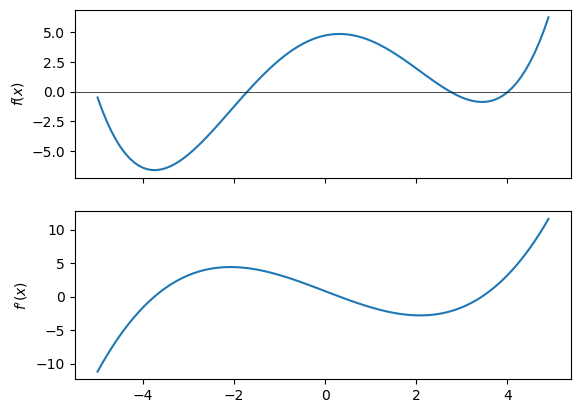

In [4]:
# x の範囲を指定
x_list = np.arange(-5, 5, 0.1)

# プロットの設定
fig = plt.figure()
axs = fig.subplots(2, sharex=True)

# f(x) のプロット
ax = axs[0]
ax.plot(x_list, f(x_list))
ax.axhline(y=0, lw=0.5, color="k")
ax.set_ylabel("$f(x)$")

# f'(x) のプロット
ax = axs[1]
ax.plot(x_list, f.grad(x_list))
ax.set_ylabel("$f'(x)$")

plt.show()


#### 1.2.1.4. <a id='toc1_2_1_4_'></a>[コールバック](#toc0_)

解の反復の様子を記録し，可視化するために，1次元用のコールバッククラス`CacheXk1D`を定義する．このクラスは，各反復ごとに$x_k$，$f(x_k)$，および$|f'(x_k)|$の値を記録する．

In [5]:
class CacheXk1D():
    """
    1次元の反復過程をキャッシュするクラス
    """

    def is_scalar(
            self,
            x: float | int | np.ndarray
        ) -> bool:
        """
        入力がスカラー値または単一要素のndarrayかを確認

        Args:
            x (float | int | np.ndarray): 入力値

        Returns:
            bool: xがスカラー値または単一要素のndarrayならTrue
        """
        return isinstance(x, float) \
            or isinstance(x, int) \
            or (isinstance(x, np.ndarray) \
                and x.ndim == 1 \
                and len(x) == 1)

    def __init__(
            self,
            f: callable,
            g: callable,
            x0: float | int | np.ndarray,
            name: str
        ) -> None:
        """
        コンストラクタ

        Args:
            f (callable): 目的関数 f(x)
            g (callable): f'(x), f(x) の1次導関数
            x0 (float | int | np.ndarray): 初期値
            name (str): キャッシュの名前
        """
        assert self.is_scalar(x0), "x must be scalar"
        self.__x_series = [x0]
        self.__f_series = [f(x0)]
        self.__g_series = [abs(g(x0))]
        self.f = f
        self.g = g
        self.__name = str(name)


    def __call__(self, xk: float) -> None:
        """
        解の反復過程をキャッシュに記録

        Args:
            xk (float): 現在の解 x_k
        """
        assert self.is_scalar(xk), "x must be float or int"
        self.__x_series.append(xk)
        self.__f_series.append(self.f(xk))
        self.__g_series.append(abs(self.g(xk)))

    def get_x(self) -> np.ndarray:
        """記録された x_k を取得"""
        return np.array(self.__x_series)

    def get_f(self) -> np.ndarray:
        """記録された f(x_k) を取得"""
        return np.array(self.__f_series)

    def get_g(self) -> np.ndarray:
        """記録された |f'(x_k)| を取得"""
        return np.array(self.__g_series)

    def get_name(self) -> str:
        """キャッシュの名前を取得"""
        return str(self.__name)


解の反復結果を可視化するために，`PlotCacheXk1D`を定義する．このクラスは解の収束過程や関数の挙動をプロットする．

In [6]:
class PlotCacheXk1D():
    """
    CacheXk1D の記録データをプロットするクラス
    """

    def __init__(self, cache: CacheXk1D) -> None:
        assert isinstance(cache, CacheXk1D)
        self.cache = cache
        self.x_label = "iterations k"

    def plot_1d(self, draw_y0_line: bool = False) -> Dict[str, plt.figure]:
        """
        解の収束過程と目的関数の挙動をプロット

        Args:
            draw_y0_line (bool, optional): y=0の水平線を描画するかどうか（デフォルト: False）

        Returns:
            Dict[str, plt.figure]: 作成したプロット
        """
        return {
            "convergence": self.plot_convergence(),
            "x_over_f": self.plot_x_over_f(draw_y0_line)
        }

    def plot_convergence(self) -> plt.figure:
        """各反復における x, f(x), |f'(x)| の挙動をプロット"""
        fig = plt.figure()
        axs = fig.subplots(3, sharex=True)

        # x_k のプロット
        ax = axs[0]
        ax.plot(self.cache.get_x(), ".-", label=self.cache.get_name())
        ax.set_ylabel("$x_k$")
        ax.legend()

        # |f'(x_k)| のプロット
        ax = axs[1]
        ax.plot(self.cache.get_f(), ".-", label=self.cache.get_name())
        ax.axhline(y=0, lw=0.5, color="k")
        ax.set_ylabel("$f(x_k)$")
        ax.legend()

        ax = axs[2]
        ax.plot(self.cache.get_g(), ".-", label=self.cache.get_name())
        ax.set_ylabel("$|f'(x_k)|$")
        ax.legend()

        ax.set_xlabel(self.x_label)

        plt.show()
        return fig

    def plot_x_over_f(
        self,
        draw_y0_line: bool,
        xmin: float = -5,
        xmax: float = 5,
        xstep: float = 0.2,
    ) -> plt.figure:
        """
        f(x) と反復点の関係をプロット

        Args:
            draw_y0_line (bool): y=0の水平線を描画するかどうか
            xmin (float): x の範囲の最小値（デフォルト-5）
            xmax (float): x の範囲の最大値（デフォルト5）
            xstep (float): x のステップ幅（デフォルト0.2）

        Returns:
            plt.figure: プロットされたfigオブジェクト
        """
        fig = plt.figure()
        ax = fig.subplots()

        x_list = np.arange(xmin, xmax, xstep)
        plt.plot(x_list, f(x_list), label="$f(x)$")

        # 初期値 x0 の描画
        ax.scatter(
            self.cache.get_x()[0],
            self.cache.get_f()[0],
            color="w",
            s=150,
            edgecolors="k",
            label="$x_0$")

        # 解の系列の描画
        ax.scatter(
            self.cache.get_x(),
            self.cache.get_f(),
            color="r",
            label="$x_k$")

        # 最適解の描画
        ax.scatter(
            self.cache.get_x()[-1],
            self.cache.get_f()[-1],
            color="w",
            s=150,
            marker=",",
            zorder=-10,
            edgecolors="k",
            label="$\hat{x}$")

        # y=0の水平線を描画
        if draw_y0_line:
            ax.axhline(y=0, lw=1, color="k")

        ax.set_xlabel("x")
        ax.set_ylabel("f(x)")
        ax.grid()
        ax.legend()
        ax.set_title(self.cache.get_name())

        plt.show()
        return fig


<>:104: SyntaxWarning: invalid escape sequence '\h'
<>:104: SyntaxWarning: invalid escape sequence '\h'
C:\Users\sayuk\AppData\Local\Temp\ipykernel_50352\2599950995.py:104: SyntaxWarning: invalid escape sequence '\h'
  label="$\hat{x}$")


#### 1.2.1.5. <a id='toc1_2_1_5_'></a>[ニュートン法の実装](#toc0_)

非線形方程式 $f(x) = 0$ を解くための1次元のニュートン法の実装は，以下のように最適化用の1次元のニュートン法のコードを少し修正したものである．
（なお，最適化問題を解くための反復法とは異なり，非線形方程式を解くためのニュートン法では通常はステップサイズを使用せず，単純に次の点を計算していく）

In [7]:
def newton_method_1d(
        f: callable,
        g: callable,
        x0: float,
        maxiter: int = 100,
        callback: callable = None
) -> float:
    """
    1次元関数のニュートン法

    Args:
        f (callable): 関数 f(x)
        g (callable): f'(x), f(x) の1次導関数
        x0 (float): 初期値
        maxiter (int, optional): 最大反復回数（デフォルト: 100）
        callback (callable, optional): 反復ごとに呼び出すコールバック関数（デフォルト: None）

    Returns:
        float: 解 $\hat{x}$
    """

    x = x0
    for k in range(maxiter):
        x = x - f(x) / g(x)  # ニュートン法の更新式

        if callback:
            callback(x)

        if np.isclose(np.abs(f(x)), 0):
            break

    return x


<>:19: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\h'
C:\Users\sayuk\AppData\Local\Temp\ipykernel_50352\3536418734.py:19: SyntaxWarning: invalid escape sequence '\h'
  float: 解 $\hat{x}$


以下は，目的関数 `f` を用いて，初期値 $x_0 = -2.5$ からニュートン法を適用するコードである．反復過程はコールバックのインスタンス `cache_callback` に記録される．


In [8]:
# 目的関数の定義
f = Objective1D()

# 初期値の設定
x0 = -3.5  # -2.5

# コールバックのインスタンス
cache_callback = CacheXk1D(f, f.grad, x0, "Newton's method")

# ニュートン法の実行
x = newton_method_1d(
    f,         # 目的関数
    f.grad,    # 導関数
    x0,        # 初期値
    maxiter=5, # 最大反復回数
    callback=cache_callback  # コールバック関数
)

# 結果の表示
print("x", x)
print("f(x)", f(x))


x 2.74014606730669
f(x) 1.236433346818444e-07


解の収束過程を可視化するために，`PlotCacheXk1D` クラスを使用する．以下のコードで，収束の様子をグラフとして描画する．


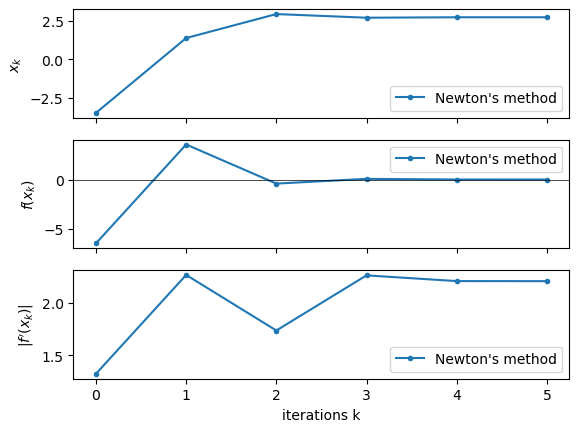

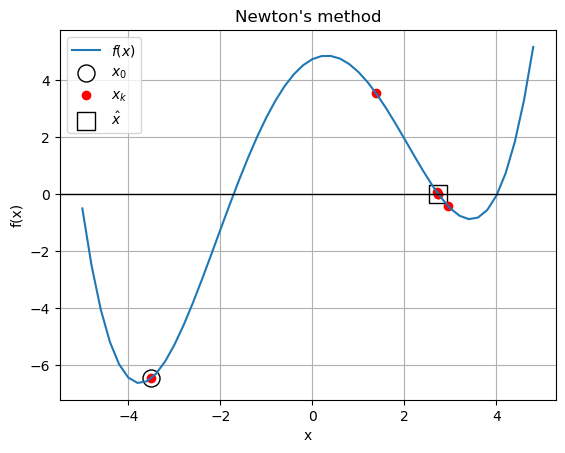

In [9]:
# プロットクラスのインスタンス
plot_cache = PlotCacheXk1D(cache_callback)

# プロットの実行
figs = plot_cache.plot_1d(draw_y0_line=True)

#### 1.2.1.6. <a id='toc1_2_1_6_'></a>[scipy の 1 次元ニュートン法ソルバー](#toc0_)

[Scipy](https://docs.scipy.org/) には，1 次元の非線形方程式を解くためのソルバー `scipy.optimize.root_scalar()` が実装されている．この関数を使用することで，ニュートン法などの一般的な手法を簡単に適用できる．

目的関数 `f` とその導関数 `f.grad` を引数に指定し，初期値として `x0` を与える．また，`method` 引数には用いる解法の文字列を指定する．ニュートン法を使用するためには，`"newton"` を指定する．

- <https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root_scalar.html>
    > Find a root of a scalar function.

なお，`scipy.optimize.root_scalar()` ではコールバック関数を直接引数として指定することができない．そのため，可変長引数 `args` にコールバックを渡し，目的関数 `f` の内部でコールバックを明示的に呼び出している．

この実装の影響で，プロットにおける横軸は反復回数ではなく，実際には目的関数 `f` を評価した回数（呼び出し回数）となる．これは，ニュートン法の反復が関数評価と一致しない場合に注意が必要である．

以下はscipyのニュートン法で1 次元の非線形方程式を解くコードである．


In [10]:
f = Objective1D()

x0 = -3.5  # -2.5
cache_callback = CacheXk1D(f, f.grad, x0, "scipy.root_scalar")

result = scipy.optimize.root_scalar(
    f,                  # 目的関数
    fprime=f.grad,      # 導関数
    x0=x0,              # 初期値
    method="newton",    # ニュートン法ソルバーの指定
    args=cache_callback # コールバック関数を args に渡す
)
print(result)

x = result.root
print("x", x)
print("f(x)", f(x))


      converged: True
           flag: converged
 function_calls: 14
     iterations: 7
           root: 2.74014612326512
         method: newton
x 2.74014612326512
f(x) -8.881784197001252e-16


`root_scalar()` は，実行時の情報オブジェクト（[RootResults](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.RootResults.html)）を返す．
このオブジェクトには以下の属性が含まれる．

- root：得られた解（根）
- iterations：反復回数
- function_calls：関数`f`を評価した（呼び出した）回数
- converged：反復が収束したかどうか
- flag：終了条件の種類


以下は，`CacheXk1D` に記録された解の収束過程を可視化するコードである．


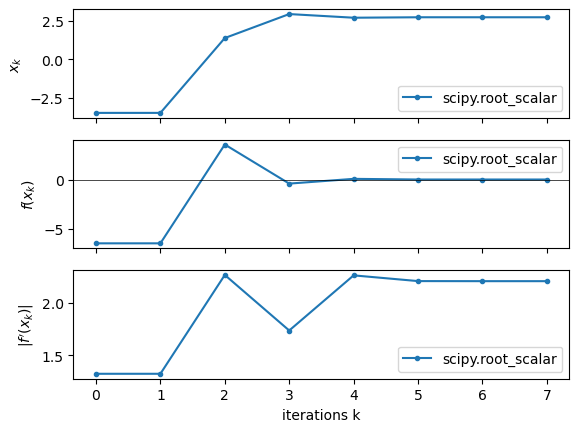

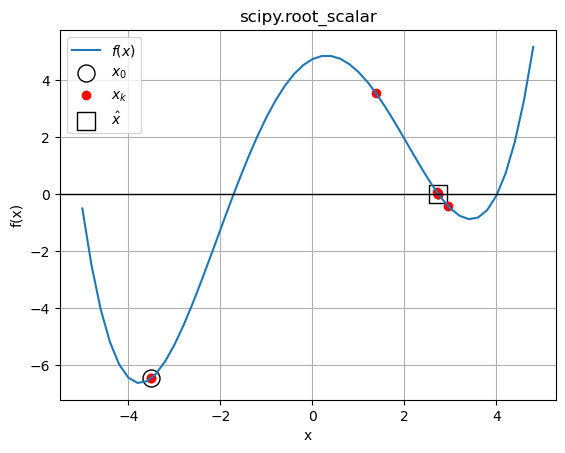

In [11]:
plot_cache = PlotCacheXk1D(cache_callback)
figs = plot_cache.plot_1d(draw_y0_line=True)

### 1.2.2. <a id='toc1_2_2_'></a>[セカント法](#toc0_)

曲線と1点で接する接線（tangent line）に対して，曲線と2点（以上）で交差する線を割線（secant line）と呼ぶ．
セカント法（secant method）は，ニュートン法における導関数 $f'(x)$ を，次のように割線による差分で近似することで導出される．

$$
f'(x^{(k)}) = \frac{f(x^{(k)}) - f(x^{(k-1)})}{x^{(k)} - x^{(k-1)}}
$$

点 $x^{(k)}$ と $x^{(k-1)}$ における関数値 $f(x)$ を通る直線（割線）は以下のように表される．

$$
y = \frac{f(x^{(k)}) - f(x^{(k-1)})}{x^{(k)} - x^{(k-1)}} (x - x^{(k)}) + f(x^{(k)})
$$

この割線が $x$ 軸と交わる点は次のように計算される．

$$
x = x^{(k)} - \frac{x^{(k)} - x^{(k-1)}}{f(x^{(k)}) - f(x^{(k-1)})} f(x^{(k)})
$$

セカント法は，これを次の解 $x^{(k+1)}$ として反復を行う．


- [水島二郎, 柳瀬眞一郎, 石原卓, 理工学のための数値計算法［第3版］, 数理工学社, 2019](https://www.saiensu.co.jp/search/?isbn=978-4-86481-061-6&y=2019), p.89, 4.4.1 割線法.
- https://en.wikipedia.org/wiki/Secant_method
    > In numerical analysis, the secant method is a root-finding algorithm that uses a succession of roots of secant lines to better approximate a root of a function f.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/40/Secant_method_2.svg/535px-Secant_method_2.svg.png">

[Public Domain](https://commons.wikimedia.org/wiki/File:Secant_method_2.svg#/media/File:Secant_method_2.svg)



#### 1.2.2.1. <a id='toc1_2_2_1_'></a>[セカント法のアルゴリズム](#toc0_)

セカント法のアルゴリズムは次の通りである．

1. 初期値として $x^{(0)}$ と $x^{(1)}$ を与える（2つの初期値が必要）．
2. 収束するまで次を反復
    1. $x^{(k+1)} = x^{(k)} - \dfrac{x^{(k)} - x^{(k-1)}}{f(x^{(k)}) - f(x^{(k-1)})} f(x^{(k)})$

セカント法の利点は，導関数を計算する必要がないことである．
一方でセカント法の欠点は，2つの初期値が必要であること，割線の傾きによる粗い導関数の近似を使用するため，ニュートン法より収束が遅い場合があることである．



#### 1.2.2.2. <a id='toc1_2_2_2_'></a>[scipy のセカント法ソルバー](#toc0_)


以下は `scipy.optimize.root_scalar()` を使用してセカント法を実行する例である．ソルバー引数`method` には `"secant"` を指定し，2つの初期値を `x0` と `x1` に与える．

In [12]:
f = Objective1D()

# 2つの初期値の設定
x0 = -2.5  # -1.0, -2.0
x1 = -2.0

cache_callback = CacheXk1D(f, f.grad, x0, "Secant method")

result = scipy.optimize.root_scalar(
    f,                  # 目的関数
    x0=x0,              # 初期値1
    x1=x1,              # 初期値2
    method="secant",    # セカント法ソルバーの指定
    args=cache_callback # コールバック関数を args に渡す
)

print(result)
x = result.root
print("x", x)
print("f(x)", f(x))


      converged: True
           flag: converged
 function_calls: 5
     iterations: 4
           root: -1.711928062341185
         method: secant
x -1.711928062341185
f(x) 0.0


収束の様子をプロットするには，これまで同様に`CacheXk1D` に記録されたデータを可視化する．

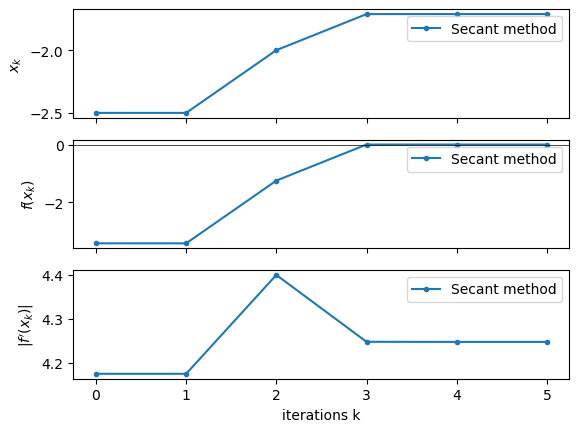

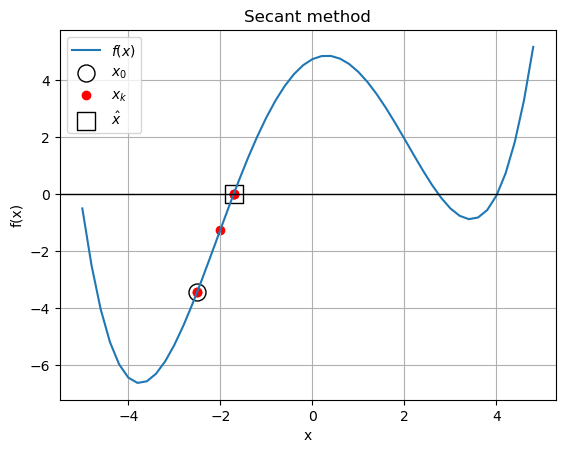

In [13]:
plot_cache = PlotCacheXk1D(cache_callback)
figs = plot_cache.plot_1d(draw_y0_line=True)

### 1.2.3. <a id='toc1_2_3_'></a>[Halley法](#toc0_)

ニュートン法が1次近似を用いるのに対し，Halley法（Halley's method）は2次近似を用いて解を求める手法である．この手法は，関数 $f(x)$ を現在の解の周りで2次テーラー展開し，その近似から次の解を求める．

- [朝倉 数学ハンドブック 応用編, 朝倉書店, 2011.](https://www.asakura.co.jp/detail.php?book_code=11130) V 数値解析, 3 非線形方程式, 3.1 単独非線形方程式, p301.
- [河村哲也, 桑名杏奈, Pythonによる数値計算入門, 朝倉書店, 2021](https://www.asakura.co.jp/detail.php?book_code=12900), p.27, 2.4 ニュートン法―その2.
- https://en.wikipedia.org/wiki/Halley%27s_method
    > In numerical analysis, Halley's method is a root-finding algorithm used for functions of one real variable with a continuous second derivative. Edmond Halley was an English mathematician and astronomer who introduced the method now called by his name.


まず，方程式$f(x)=0$を，現在の解$x^{(k)}$の周りで2次テーラー近似する．

\begin{align*}
f(x) \simeq \tilde{f}(x) =
f(x^{(k)})
+ f'(x^{(k)}) (x - x^{(k)})
+ \frac{1}{2} f''(x^{(k)}) (x - x^{(k)})^2
\end{align*}

この近似を用いた近似方程式$\tilde{f}(x) = 0$を満たす解を，
次の解$x^{(k+1)}$とする．
つまり$\tilde{f}(x^{(k+1)})=0$となる．
これを用いて，上式に$x=x^{(k+1)}$を代入して0とおくと，次のようになる．

\begin{align*}
f(x^{(k)})
+ f'(x^{(k)}) (x^{(k+1)}  - x^{(k)})
+ \frac{1}{2} f''(x^{(k)}) (x^{(k+1)}  - x^{(k)})^2
&= 0
\\
f(x^{(k)})
+
(x^{(k+1)} - x^{(k)})
\left(
f'(x^{(k)})
+ \frac{1}{2} f''(x^{(k)}) (x^{(k+1)} - x^{(k)})
\right)
&= 0
\end{align*}

しかし2次近似の場合，近似した放物線が$x$軸と交差しない可能性がある．
そこで，さらにここでニュートン法の1次近似

\begin{align*}
x^{(k+1)} &= x^{(k)} - \frac{f(x^{(k)})}{f'(x^{(k)})}
\\
x^{(k+1)} - x^{(k)} &= - \frac{f(x^{(k)})}{f'(x^{(k)})}
\end{align*}

を用いて2次微分の係数を置き換える．すると以下のようになる．

\begin{align*}
f(x^{(k)})
+
(x^{(k+1)} - x^{(k)})
\left(
f'(x^{(k)})
- \frac{1}{2} f''(x^{(k)}) \frac{f(x^{(k)})}{f'(x^{(k)})}
\right)
&= 0
\end{align*}

となる（これは双曲線近似に相当する）．
これを変形すると，以下の更新式が得られる．

\begin{align*}
x^{(k+1)}
&=
x^{(k)}
-
\frac{f(x^{(k)}) f'(x^{(k)})}{f'(x^{(k)})^2 - \frac{1}{2} f''(x^{(k)}) f(x^{(k)})}
\end{align*}



#### 1.2.3.1. <a id='toc1_2_3_1_'></a>[scipy のHalley法ソルバー](#toc0_)

以下のコードは，`scipy.optimize.root_scalar()` を使用して Halley法を実行する例である．引数`method` に `"halley"` を指定し，1次導関数 `fprime` と2次導関数 `fprime2` を引数に渡す．



In [14]:
f = Objective1D()

x0 = -2.5  # -1.0, -2.0
cache_callback = CacheXk1D(f, f.grad, x0, "Halley's method")

result = scipy.optimize.root_scalar(
    f,                  # 目的関数
    x0=x0,              # 初期値
    fprime=f.grad,      # 1次導関数
    fprime2=f.second_grad,  # 2次導関数
    method="halley",    # Halley法ソルバーの指定
    args=cache_callback # コールバック関数を args に渡す
)
print(result)
x = result.root
print("x", x)
print("f(x)", f(x))


      converged: True
           flag: converged
 function_calls: 10
     iterations: 3
           root: -1.711928062341185
         method: halley
x -1.711928062341185
f(x) 0.0


解の収束過程を可視化するために，`CacheXk1D` の記録を用いてプロットを作成する．

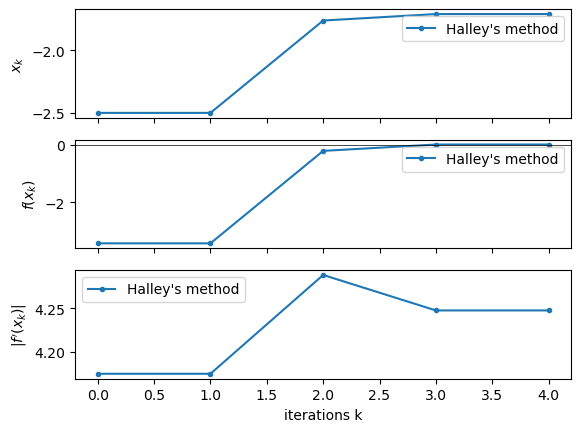

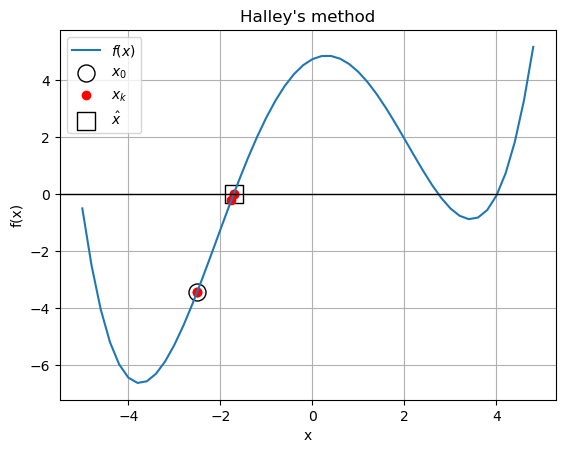

In [15]:
plot_cache = PlotCacheXk1D(cache_callback)
figs = plot_cache.plot_1d(draw_y0_line=True)

### 1.2.4. <a id='toc1_2_4_'></a>[2分法](#toc0_)

2分法（bisection method）は，不動点反復とは異なる方法で1次元の非線形方程式 $f(x) = 0$ を解く手法である．この方法では，解が存在する範囲（bracket）があらかじめ閉区間 $[a, b]$ として与えられ，かつ $f(a)$ と $f(b)$ が異符号（すなわち $f(a) f(b) < 0$）である場合，中間値の定理に基づいて解がその区間内に存在することが保証される．

そこで，この範囲を各反復で
$[a_0, b_0] \supset [a_1, b_1] \supset \cdots \supset [a_k, b_k]$
のように狭めていくことで，解が存在する範囲を次第に小さくしていく．
つまり，各反復で解が区間に存在するように，
$i=0,1,\ldots,k$について$x \in [a_i, b_i] \subset [a_{i-1}, b_{i-1}]$が成り立つように，次の区間を決定する．
このような方法の総称がbracketingである．

その中でも 2分法（bisection）は代表的なアルゴリズムであり，
他にも黄金分割法（golden-section search）などがある．


- https://en.wikipedia.org/wiki/Bisection_method
    > In mathematics, the bisection method is a root-finding method that applies to any continuous function for which one knows two values with opposite signs.
- https://en.wikipedia.org/wiki/Golden-section_search
    > The golden-section search is a technique for finding an extremum (minimum or maximum) of a function inside a specified interval.
- [William H. Press, Saul A. Teukolsky, William T. Vetterling, Brian P. Flannery, Numerical Recipes 3rd Edition: The Art of Scientific Computing, 2007](https://numerical.recipes/book.html), p445, 9.1 Bracketing and Bisection
    > We will say that a root is bracketed in the interval (a, b) if f(a) and f(b) have opposite signs.
- [Mykel J. Kochenderfer, Tim A. Wheeler, 最適化アルゴリズム, 共立出版, 2022](https://www.kyoritsu-pub.co.jp/book/b10024250.html), p.33, 3 囲い込み法, p.44, 3.7 二分法.
- [三井田惇郎, 須田宇宙, 数値計算法(第3版), 森北出版, 2023](https://www.morikita.co.jp/books/mid/080154), p.1, 1.1 2分法.
- [橋本修, 毛塚敦, Pythonによる数値計算法の基礎, 森北出版, 2021](https://www.morikita.co.jp/books/mid/074431), p.1, 1.1 はさみうち法.
- [河村哲也, 桑名杏奈, Pythonによる数値計算入門, 朝倉書店, 2021](https://www.asakura.co.jp/detail.php?book_code=12900), p.18, 2.2 2分法.


2分法では，解が存在する区間 $[a_k, b_k]$ を次のように半分に狭めていく．

- 初期区間$[a_0, b_0]$, $k=0$
    - $a_0 < b_0$
    - $f(a_0) f(b_0) < 0$（異符号の条件）
- $|a_k - b_k|$が十分小さくなるまで以下を反復
    - 区間の中点を計算：$c_k = \dfrac{a_k + b_k}{2}$
    - $f(a_k)$ と $f(c_k)$ の符号に基づいて次の区間を更新：
      - もし$f(a_k) f(c_k) < 0$なら
          - 区間を$[a_k, c_k]$に更新：$b_{k+1} \leftarrow c_k$
      - もし$f(a_k) f(c_k) > 0$なら
          - 区間を$[c_k, b_k]$に更新：$a_{k+1} \leftarrow c_k$


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/8/8c/Bisection_method.svg/412px-Bisection_method.svg.png">

[Tokuchan derivative work CC BY-SA 3.0](https://commons.wikimedia.org/wiki/File:Bisection_method.svg#/media/File:Bisection_method.svg)


#### 1.2.4.1. <a id='toc1_2_4_1_'></a>[scipy の 2 分法ソルバー](#toc0_)

以下は2分法を`scipy.optimize.root_scalar()`で実行した例である．
`method`には`"bisect"`を指定する．
初期区間`bracket`には`[-4, 0]`を指定している．


In [16]:
f = Objective1D()

cache_callback = CacheXk1D(f, f.grad, x0, "Bisection")

result = scipy.optimize.root_scalar(
    f,                   # 目的関数
    bracket=[-4, 0],     # 初期区間 [a, b]
    method="bisect",     # 2分法ソルバーの指定
    args=cache_callback  # コールバック関数を args に渡す
)
print(result)
x = result.root
print("x", x)
print("f(x)", f(x))


      converged: True
           flag: converged
 function_calls: 43
     iterations: 41
           root: -1.7119280623428494
         method: bisect
x -1.7119280623428494
f(x) -7.069900220812997e-12


以下が解の収束の様子をプロットしたものである．

なお2分法では，関数評価の回数と反復回数が一致しない．そのため，プロットの横軸は「iteration（反復回数）」ではなく，「関数評価の回数」を意味していることに注意が必要である．

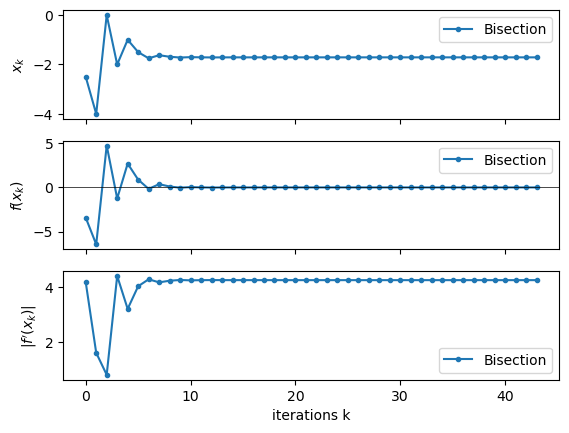

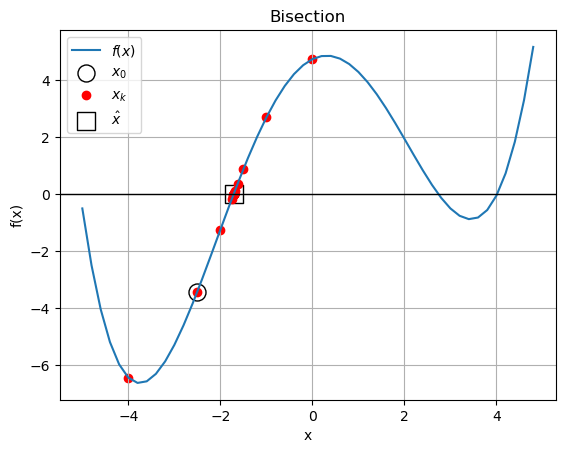

In [17]:
plot_cache = PlotCacheXk1D(cache_callback)
figs = plot_cache.plot_1d(draw_y0_line=True)

### 1.2.5. <a id='toc1_2_5_'></a>[Brent法](#toc0_)

Brent法（Brent's method）は，1次元の非線形方程式を解くために広く使用される手法である．この手法は，bracketing，2分法，および2次補間を組み合わせた高度なアルゴリズムであり，収束の堅牢性と効率性を両立している．

`scipy.optimize.root_scalar()` には，2種類の Brent法が実装されている．
1. `"brentq"`:
   - 逆2次外挿を利用するアルゴリズム．最も一般的に用いられる1次元球根法．
1. `"brenth"`:
   - 双曲線外挿を利用するアルゴリズム．

- <https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.brentq.html>
    > Find a root of a function in a bracketing interval using Brent’s method.
- <https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.brenth.html>
    > Find a root of a function in a bracketing interval using Brent’s method with hyperbolic extrapolation.


#### 1.2.5.1. <a id='toc1_2_5_1_'></a>[scipy のBrent法ソルバー](#toc0_)

以下のコードは，`scipy.optimize.root_scalar()` を用いて Brent法を実行する例である．`method` 引数に `"brentq"` または `"brenth"` を指定する．2分法を用いるため，初期区間も引数`bracket`に指定する．


In [18]:
f = Objective1D()

x0 = -2.5  # -1.0, -2.0
cache_callback = CacheXk1D(f, f.grad, x0, "Brent's method")

result = scipy.optimize.root_scalar(
    f,                   # 目的関数
    bracket=[-4, 0],     # 初期区間 [a, b]
    method="brentq",     # 解法の指定 ("brentq" または "brenth")
    args=cache_callback  # コールバック関数を args に渡す
)

print(result)
x = result.root
print("x", x)
print("f(x)", f(x))


      converged: True
           flag: converged
 function_calls: 7
     iterations: 6
           root: -1.711928062341185
         method: brentq
x -1.711928062341185
f(x) 0.0


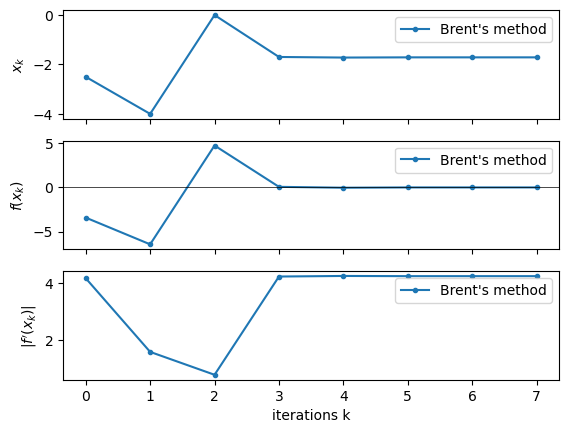

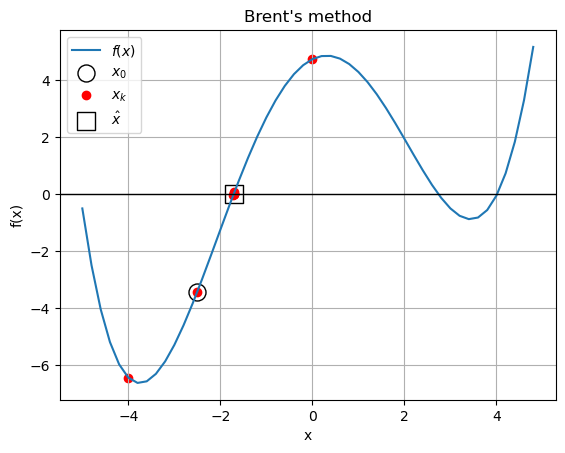

In [19]:
plot_cache = PlotCacheXk1D(cache_callback)
figs = plot_cache.plot_1d(draw_y0_line=True)

## 1.3. <a id='toc1_3_'></a>[多次元（$m=n$）](#toc0_)

### 1.3.1. <a id='toc1_3_1_'></a>[ニュートン法](#toc0_)

多次元の場合のニュートン法（Newton's method）は，$n=m$ を仮定して，$n$ 次元ベクトル $\boldsymbol{x} \in R^n$ を入力とし，ベクトル値関数 $\boldsymbol{f}(\boldsymbol{x}) \in R^n$ を出力とする非線形方程式 $\boldsymbol{f}(\boldsymbol{x}) = \boldsymbol{0}$ を解く手法である．

多次元の場合のニュートン法は，1次元のニュートン法と同様に，
1次近似に基づいて解の更新を行う．

- [C. T. Kelley, Iterative Methods for Linear and Nonlinear Equations, siam, 1995](https://epubs.siam.org/doi/10.1137/1.9781611970944), Chapter 5. Newton Methods.
- [幸谷智紀, Python数値計算プログラミング, 講談社, 2021](https://www.kspub.co.jp/book/detail/5227350.html), p.160, n次元n変数方程式に対するニュートン法.
- [河村哲也, 桑名杏奈, Pythonによる数値計算入門, 朝倉書店, 2021](https://www.asakura.co.jp/detail.php?book_code=12900), p.29, 2.5 多変数のニュートン法.
- [最適化ハンドブック, 朝倉書店, 1995](https://www.amazon.co.jp/%E6%9C%80%E9%81%A9%E5%8C%96%E3%83%8F%E3%83%B3%E3%83%89%E3%83%96%E3%83%83%E3%82%AF-G-L-Nemhauser/dp/4254121024), p.8, 2.1 非線形方程式に対するNewton法.



まず方程式$\boldsymbol{f}(\boldsymbol{x})=\boldsymbol{0}$を現在の解$\boldsymbol{x}^{(k)}$の周りで1次テーラー近似する．


\begin{align*}
\boldsymbol{f}(\boldsymbol{x}) \simeq
\tilde{\boldsymbol{f}}(\boldsymbol{x})
&=
\boldsymbol{f}(\boldsymbol{x}^{(k)})
+ J(\boldsymbol{x}^{(k)})
(\boldsymbol{x} - \boldsymbol{x}^{(k)})
\end{align*}

ここで$J(\boldsymbol{x}^{(k)})$はヤコビ行列$\frac{\partial \boldsymbol{f}}{\partial \boldsymbol{x}}$であり，各成分は以下のように定義される．

$$
J(\boldsymbol{x}) = \frac{\partial \boldsymbol{f}}{\partial \boldsymbol{x}} =
\begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n} \\
\vdots & \ddots & \vdots \\
\frac{\partial f_n}{\partial x_1} & \cdots & \frac{\partial f_n}{\partial x_n}
\end{bmatrix}.
$$

$m=n$ の場合，ヤコビ行列$J(\boldsymbol{x})$ は正方行列となり，正則であれば逆行列 $J(\boldsymbol{x})^{-1}$ が存在する．


この1次近似を用いて$\tilde{\boldsymbol{f}}(\boldsymbol{x})=\boldsymbol{0}$を解くと，次の連立一次方程式が得られる．

\begin{align*}
J(\boldsymbol{x}^{(k)}) (\boldsymbol{x} - \boldsymbol{x}^{(k)}) = -  \boldsymbol{f}(\boldsymbol{x}^{(k)})
\end{align*}

この方程式を $\boldsymbol{x}$ について解くと，次のようになる．

\begin{align*}
\boldsymbol{x} - \boldsymbol{x}^{(k)} = - J(\boldsymbol{x}^{(k)})^{-1} \boldsymbol{f}(\boldsymbol{x}^{(k)})
\\
\boldsymbol{x} = \boldsymbol{x}^{(k)} - J(\boldsymbol{x}^{(k)})^{-1} \boldsymbol{f}(\boldsymbol{x}^{(k)})
\end{align*}

これを次の解$\boldsymbol{x}^{(k+1)}$とするのが，次のニュートン法の更新式である．

\begin{align*}
\boldsymbol{x}^{(k+1)} = \boldsymbol{x}^{(k)} - J(\boldsymbol{x}^{(k)})^{-1} \boldsymbol{f}(\boldsymbol{x}^{(k)})
\end{align*}

この更新式は，更新方向ベクトル$\boldsymbol{d} = \boldsymbol{x}^{(k+1)} - \boldsymbol{x}^{(k)}$を用いて，
連立一次方程式を直接解く形で次のように記述されることもある．
$$
J \boldsymbol{d} = - \boldsymbol{f}
$$
ここで$J=J(\boldsymbol{x}), \boldsymbol{f}=\boldsymbol{f}(\boldsymbol{x})$である．

#### 1.3.1.1. <a id='toc1_3_1_1_'></a>[ニュートン法のアルゴリズム](#toc0_)

多次元のニュートン法のアルゴリズムは以下のようになる．

- 初期値$\boldsymbol{x}^{(0)}$，$k=0$
- 収束するまで以下を反復
    - $\boldsymbol{d}^{(k)} = - J(\boldsymbol{x}^{(k)})^{-1} \boldsymbol{f}(\boldsymbol{x}^{(k)})$
        - $J(\boldsymbol{x}^{(k)}) \boldsymbol{d}^{(k)} = -  \boldsymbol{f}(\boldsymbol{x}^{(k)})$を解く
    - $\boldsymbol{x}^{(k+1)} = \boldsymbol{x}^{(k)} +\boldsymbol{d}^{(k)}$



多次元の非線形方程式の例として，$n=m=2$である以下の関数を考える．
このクラスは非線形関数`f`と，そのヤコビ行列`f.jac()`を実装している．

#### 1.3.1.2. <a id='toc1_3_1_2_'></a>[関数の実装](#toc0_)

多次元の非線形方程式の例として，$n=m=2$ の場合を考える．以下のクラスでは，非線形関数 `f` とそのヤコビ行列 `f.jac()` を実装している．
（なお$m=3$ を設定した場合には出力ベクトルが 3 次元となるが，これは後述の$n \neq m$の例で用いる）


In [20]:
class Function2D():
    """
    2次元の非線形関数を表すクラス．
    入力次元 n=2，出力次元 m=2 または 3．
    """

    def __init__(self, n:int = 2, m:int = 2) -> None:
        """
        コンストラクタ．n と m を設定する．

        Args:
            n (int): 入力の次元（固定で 2）．
            m (int): 出力の次元（2 または 3）．
        """
        assert n == 2
        assert m == 2 or m == 3

        self.n = n
        self.m = m

    def do_callback(self, x, *callbacks):
        """
        コールバック関数を呼び出す．

        Args:
            x (np.ndarray): 入力 x．
            callbacks (List[callable]): コールバック関数のリスト．
        """
        for callback in callbacks:
            callback(x)

    def __call__(self, x: np.ndarray, *args) -> np.ndarray:
        """
        非線形関数 f(x) を計算する．

        Args:
            x (np.ndarray): 入力 x（n次元ベクトル）
            args (callable): コールバック関数（任意）

        Returns:
            np.ndarray: 出力 f(x)（m次元ベクトル）
        """
        assert len(x) == self.n
        self.do_callback(x, *args)
        x_1, x_2 = x
        f_1 = np.exp(-np.exp(-x_1 - x_2)) - x_2 * (1 + x_1**2)
        f_2 = x_1 * np.cos(x_2) + x_2 * np.sin(x_1) - 0.5
        f_3 = x_2 * np.cos(x_1) + x_1 * np.sin(x_2) - 0.1
        if self.m == 2:
            fx = np.array([f_1, f_2])
        else:
            fx = np.array([f_1, f_2, f_3])
        return fx

    def jac(self, x: np.ndarray, *args) -> np.ndarray:
        """
        関数 f(x) のヤコビ行列 J(x) を計算する．

        Args:
            x (np.ndarray): 入力 x（n次元ベクトル）

        Returns:
            np.ndarray: ヤコビ行列 J(x)（shape: (m, n)）．
        """
        assert len(x) == self.n
        x_1, x_2 = x
        f_1_x_1 = np.exp(-np.exp(-x_1 - x_2)) * np.exp(-x_1 - x_2) - 2 * x_1 * x_2
        f_1_x_2 = np.exp(-np.exp(-x_1 - x_2)) * np.exp(-x_1 - x_2) - (1 + x_1**2)
        f_2_x_1 = np.cos(x_2) + x_2 * np.cos(x_1)
        f_2_x_2 = -x_1 * np.sin(x_2) + np.sin(x_1)
        f_3_x_1 = -x_2 * np.sin(x_1) + np.sin(x_2)
        f_3_x_2 = np.cos(x_1) + x_1 * np.cos(x_2)
        if self.m == 2:
            J = np.array([
                [f_1_x_1, f_1_x_2],
                [f_2_x_1, f_2_x_2],
            ])
        else:
            J = np.array([
                [f_1_x_1, f_1_x_2],
                [f_2_x_1, f_2_x_2],
                [f_3_x_1, f_3_x_2],
            ])
        return J


#### 1.3.1.3. <a id='toc1_3_1_3_'></a>[等高線の描画](#toc0_)

2次元の場合に，非線形関数 $\boldsymbol{f}(\boldsymbol{x})$ の各成分 $f_1(x_1, x_2)$ と $f_2(x_1, x_2)$ の等高線を重ねて表示するために，`visualize_f()` 関数を定義する．この関数は，$x$ と $y$ が $[-1, 1]$ の範囲の格子状の点で関数値を計算し，等高線を `matplotlib` を用いて描画する．

In [21]:
def visualize_f(
        f: callable,
        ax: matplotlib.axis.Axis,
        x_min: float = -2.0,
        x_max: float = 2.0,
        y_min: float = -2.0,
        y_max: float = 2.0,
        levels: int | List[int] | None = None,
        plot_mse: bool = False,
        plot_index: List[int] = None,
        colors: List[str] = None,
        ) -> None:
    """目的関数 f を可視化する関数

    Args:
        f (callable, 'f(x: np.ndarray)'): 対象関数 f(x)
        ax (matplotlib.figure.Axis): matplotlib の axis オブジェクト
        x_min (float, optional): x 軸の最小値．デフォルトは -1.0．
        x_max (float, optional): x 軸の最大値．デフォルトは 1.0．
        y_min (float, optional): y 軸の最小値．デフォルトは -1.0．
        y_max (float, optional): y 軸の最大値．デフォルトは 1.0．
        levels (int, optional): 等高線の本数．デフォルトは 20．
        plot_mse (bool, optional): False の場合は各成分 f_i の等高線を描画，
                                   True の場合はベクトルノルム ||f||^2 を描画．
        plot_index (List(int), optional): 描画する関数のインデックス．None（デフォルト）の場合はすべてを描画．
        """

    # プロット範囲を設定
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # グリッドを作成
    XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
    # グリッド上の各点で関数 f を評価
    Z = np.array([f(x) for x in np.c_[XX.ravel(), YY.ravel()]])
    # reshape (hw, 1) --> (h, w, 2)
    Z = Z.reshape(*XX.shape, -1)  # グリッドの元の形状に再変形

    if plot_mse:  # ベクトルノルムの二乗 ||f||^2 を計算する場合
        Z = (Z**2).mean(axis=2)  # 各成分の二乗平均を計算 (h, w, 2) --> (h, w)
        Z = np.expand_dims(Z, 2)  # --> (h, w, 1)
        # 等高線のデフォルトの色を定義
        color_names = ["darkorange"] if colors is None else colors
        # 等高線のデフォルトを設定
        level=np.logspace(-1, 10) if levels is None else levels
    else:
        # 等高線のデフォルトの色を定義
        color_names = ["crimson", "indigo", "darkgreen", "orange"] if colors is None else colors
        # 等高線のデフォルトを設定
        level=20 if levels is None else levels

    # 等高線を描画
    for i in range(Z.shape[2]) if plot_index is None else plot_index:
        # 太線で 0 の等高線を描画（ゼロ交点を強調）
        ax.contour(XX, YY, Z[:, :, i], colors=color_names[i], levels=[0], linewidths=2)
        # 他の等高線を描画
        cs = ax.contour(XX, YY, Z[:, :, i], colors=color_names[i], levels=level, linewidths=0.5)
        # 等高線にラベルを付ける
        ax.clabel(cs, colors=color_names[i], fontsize="xx-small")


以下に，`Function2D` を対象としたプロットの例を示す．

- 各関数の等高線は異なる色で描画される．
- 関数値が正の領域では実線，負の領域では破線を使用する．
- 特に，関数値がゼロとなる等高線（解の候補）は太線で強調される．
- 求めるべき解は，2本のゼロ等高線が交差する点として視覚的に確認できる．


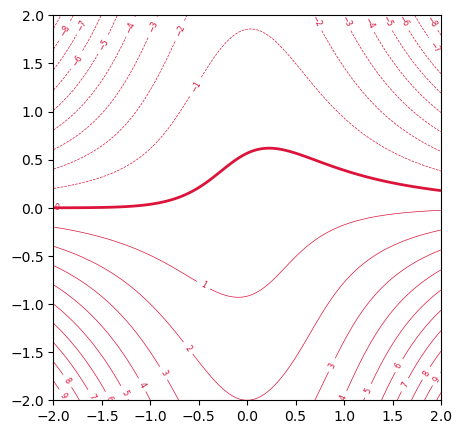

In [22]:
f = Function2D()

fig = plt.figure(figsize=(5, 5))
ax = fig.subplots()

visualize_f(f, ax, plot_index=[0])  # f1のみをプロット

plt.show()


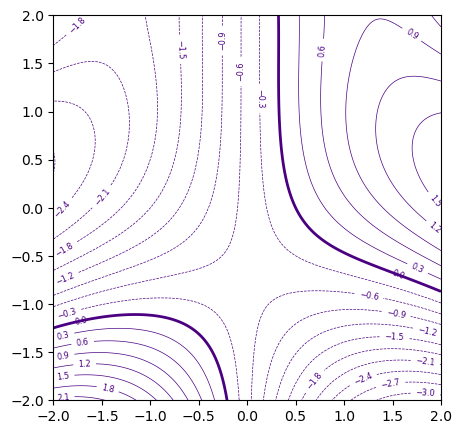

In [23]:
f = Function2D()

fig = plt.figure(figsize=(5, 5))
ax = fig.subplots()

visualize_f(f, ax, plot_index=[1])  # f2のみをプロット

plt.show()


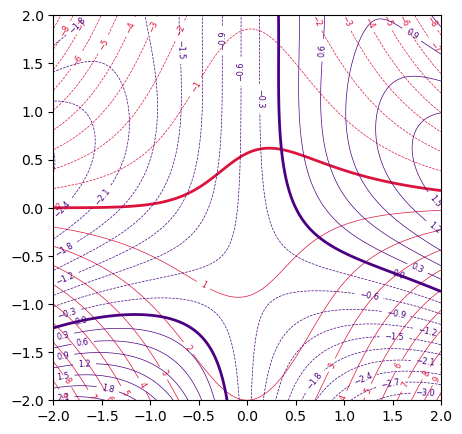

In [24]:
f = Function2D()

fig = plt.figure(figsize=(5, 5))
ax = fig.subplots()

visualize_f(f, ax)  # すべてをプロット

plt.show()


なお`plot_mse` を `True` に設定すると，関数 $f_1$，$f_2$ の個別の等高線を描画するのではなく，関数値ベクトル $\boldsymbol{f}(\boldsymbol{x}) = [f_1(\boldsymbol{x}), f_2(\boldsymbol{x})]$ のノルムの二乗 $\|\boldsymbol{f}(\boldsymbol{x})\|^2$ をプロットする．これは，後述する非線形最小二乗問題を視覚化する際に有用である．


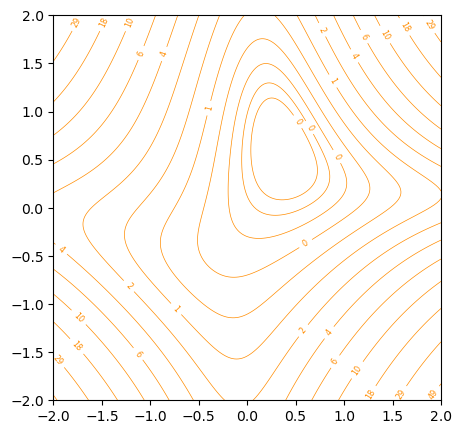

In [25]:
f = Function2D()

fig = plt.figure(figsize=(5, 5))
ax = fig.subplots()

visualize_f(f, ax, plot_mse=True)  # ノルムの二乗をプロット

plt.show()


また，関数の等高線を重ねて描画することも可能である．以下のコードは，個別の等高線とベクトルノルムの二乗を同時に描画する例である．

ただし，この場合，異なるプロットが重なるため，表示が複雑になる場合がある．視覚的な判読性を高めるために，必要に応じてプロット範囲や色の設定を調整するとよい．

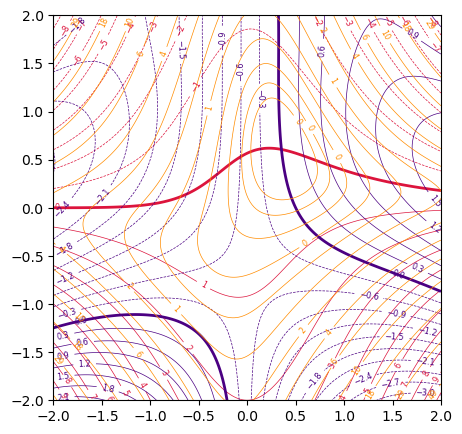

In [26]:
f = Function2D()

fig = plt.figure(figsize=(5, 5))
ax = fig.subplots()

visualize_f(f, ax)
visualize_f(f, ax, plot_mse=True)


plt.show()


#### 1.3.1.4. <a id='toc1_3_1_4_'></a>[コールバック](#toc0_)

解の反復の様子を記録し，可視化するために，1次元用のコールバッククラス`CacheXk`を定義する．このクラスは，各反復ごとに$\boldsymbol{x}_k$ とその関数値のノルム $\|f(\boldsymbol{x}_k)\|$ を記録する．


In [27]:
class CacheXk(object):
    '''
    多次元の反復過程をキャッシュするクラス
    '''

    def __init__(
            self,
            f: callable,
            x0: np.ndarray,
            name: str
        ):
        """
        コンストラクタ

        Args:
            f (callable): 目的関数 f(x)
            x0 (np.ndarray): 初期値 x_0
            name (str): キャッシュの名前
        """
        assert hasattr(x0, "copy")
        self.__x_series = [x0.copy()]  # 解の履歴を記録
        self.__f_series = [norm(f(x0))]  # 関数値のノルムを記録
        self.x_label = "iterations k"  # x 軸ラベル
        self.f = f  # 目的関数を保存
        self.__name = str(name)  # 名前を保存

    def __call__(self, xk: np.ndarray) -> None:
        """
        コールバックとして現在の x_k を記録する

        Args:
            xk (np.ndarray): 現在の点 x_k
        """
        assert hasattr(xk, "copy")
        self.__x_series.append(xk.copy())
        self.__f_series.append(norm(self.f(xk)))

    def get_x(self) -> np.ndarray:
        """記録された x_k を取得"""
        return np.array(self.__x_series)

    def get_f(self) -> np.ndarray:
        """記録された $\|f(\boldsymbol{x}_k)\|$ を取得"""
        return np.array(self.__f_series)

    def get_name(self) -> str:
        """キャッシュの名前を取得"""
        return str(self.__name)


<>:43: SyntaxWarning: invalid escape sequence '\|'
<>:43: SyntaxWarning: invalid escape sequence '\|'
C:\Users\sayuk\AppData\Local\Temp\ipykernel_50352\2079960471.py:43: SyntaxWarning: invalid escape sequence '\|'
  """記録された $\|f(\boldsymbol{x}_k)\|$ を取得"""


`CacheXk`をプロットするクラス`PlotCacheXk`も定義する．

In [28]:
class PlotCacheXk(object):
    """CacheXk クラスのデータをプロットするクラス"""

    def __init__(self, caches: List[CacheXk]) -> None:
        assert isinstance(caches, List), "should be a list of CacheXk"
        self.caches = caches
        self.f = caches[0].f
        self.x_label = "iterations k"
        self.colors = ['r', 'g', 'b', 'c', 'm', 'y']

    def plot_2d(
            self,
            plot_mse: bool = False,
            figsize:tuple = (5, 5)
        ) -> Dict[str, plt.figure]:
        """
        解の収束と関数値をプロットする

        Args:
            plot_mse (bool, optional): ノルムの二乗を描画するかどうか．デフォルトは False．
            figsize (tuple, optional): 図のサイズ．デフォルトは (5, 5)．

        Returns:
            Dict[str, plt.figure]: 各プロットの Figure オブジェクト
        """
        return {
            "convergence": self.plot_convergence(),
            "x_over_f": self.plot_x_over_f(plot_mse, figsize)
        }

    def plot_convergence(self) -> None:
        """
        各反復における $\boldsymbol{x}_k$ と $\|f(\boldsymbol{x}_k)\|$ をプロット

        Returns:
            plt.figure: プロットの fig オブジェクト
        """
        fig = plt.figure()
        axs = fig.subplots(2, sharex=True)

        # 各次元 x_k をプロット
        ax = axs[0]
        for cache, color in zip(self.caches, self.colors):
            ax.plot(cache.get_x()[:, 0], '.-', color=color,
                    label="x of " + cache.get_name())
            ax.plot(cache.get_x()[:, 1], '.--', color=color,
                    label="y of " + cache.get_name())
        ax.set_ylabel("$x_k$")
        ax.legend()

        # 関数値のノルムをプロット
        ax = axs[1]
        for cache, color in zip(self.caches, self.colors):
            ax.plot(cache.get_f(), '.-', color=color, label=cache.get_name())
        ax.set_ylabel("$\\| f(x_k) \\|$")
        ax.set_xlabel(self.x_label)
        ax.legend()

        plt.show()
        return fig

    def plot_x_over_f(self, plot_mse: bool, figsize: tuple) -> None:
        """
        軌跡と関数の等高線を描画

        Args:
            plot_mse (bool): ノルムの二乗を描画するかどうか
            figsize (tuple): 図のサイズ

        Returns:
            plt.figure: 軌跡プロットの Figure オブジェクト
        """
        fig = plt.figure(figsize=figsize)
        ax = fig.subplots()

        for cache, color in zip(self.caches, self.colors):
            x_series = cache.get_x()
            ax.scatter(
                x_series[0, 0],
                x_series[0, 1],
                color="w",
                s=50,
                edgecolors=color)
            ax.scatter(
                x_series[-1, 0],
                x_series[-1, 1],
                color=color,
                s=5,
                label=cache.get_name())
            ax.plot(
                x_series[:, 0],
                x_series[:, 1],
                marker='.',
                markersize=3,
                lw=1,
                color=color)

        visualize_f(self.f, ax)

        if plot_mse:
            visualize_f(self.f, ax, plot_mse=True)

        ax.legend()
        plt.show()

        return fig


<>:33: SyntaxWarning: invalid escape sequence '\|'
<>:33: SyntaxWarning: invalid escape sequence '\|'
C:\Users\sayuk\AppData\Local\Temp\ipykernel_50352\2904304801.py:33: SyntaxWarning: invalid escape sequence '\|'
  各反復における $\boldsymbol{x}_k$ と $\|f(\boldsymbol{x}_k)\|$ をプロット


#### 1.3.1.5. <a id='toc1_3_1_5_'></a>[ニュートン法の実装](#toc0_)

以下が多次元のニュートン法の実装である．


In [29]:
def newton_method(
        f: callable,
        J: callable,
        x0: np.ndarray,
        maxiter: int = 100,
        callback: callable = None
) -> np.ndarray:
    """ニュートン法

    Args:
        f (callable): 目的関数 f(x)．ベクトル値関数．
        J (callable): ヤコビ行列 J(x)．
        x0 (np.ndarray): 初期値．
        maxiter (int, optional): 最大反復回数．デフォルトは 100．
        callback (callable, optional): 各反復で呼び出されるコールバック関数．デフォルトは None．

    Returns:
        np.ndarray: 解 \hat{x}
    """
    n = len(x0)
    assert len(f(x0)) == n
    assert J(x0).shape == (n, n)

    x = x0.copy()
    for k in range(maxiter):
        f_x = f(x)  # 現在の関数ベクトルの計算

        # 解の更新方向dを計算
        d = solve(J(x), -f_x)

        x = x + d  # 解を更新

        if callback:
            callback(x)

        if np.isclose(norm(f_x), 0):
            return x

    return x


<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
C:\Users\sayuk\AppData\Local\Temp\ipykernel_50352\1705635090.py:18: SyntaxWarning: invalid escape sequence '\h'
  np.ndarray: 解 \hat{x}


callbackの使い方やプロットの使い方は，`sc6.ipynb`のものと同様である．

以下のコードは，多次元のニュートン法を実行し，解の収束の様子をプロットしたものである．いずれの初期値から始めても，2つの非線形関数がどちらも0になる点へ収束していることが分かる．


x [0.35324662 0.60608174]
fx [0. 0.]
x [0.35324662 0.60608174]
fx [-1.11022302e-16 -5.55111512e-17]
x [0.35324662 0.60608174]
fx [1.11022302e-16 0.00000000e+00]
x [0.35324662 0.60608174]
fx [0. 0.]


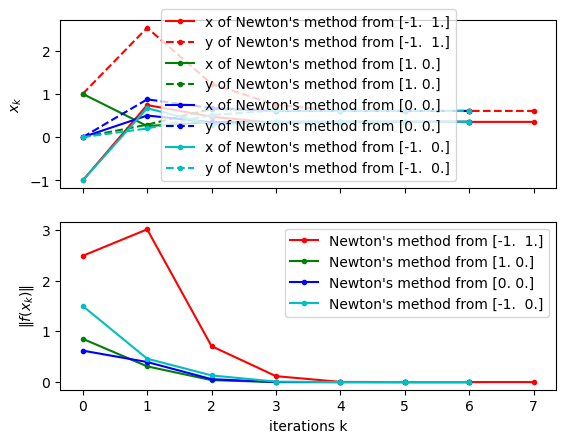

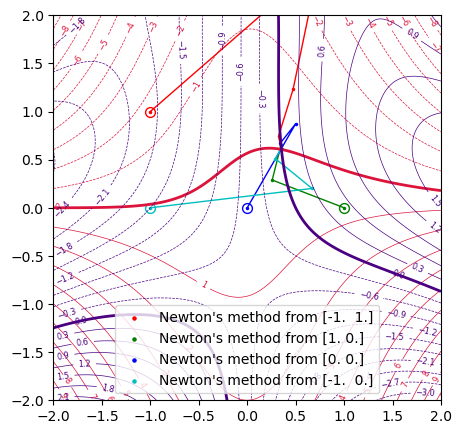

In [30]:
f = Function2D()

callback_list = []

x0_list = [
    np.array([-1.0, 1.0]),
    np.array([1.0, 0.0]),
    np.array([0.0, 0.0]),
    np.array([-1.0, 0.0]),
]
for x0 in x0_list:

    cache_callback = CacheXk(f, x0, f"Newton's method from {x0}")

    x = newton_method(
        f,      # 目的関数
        f.jac,  # ヤコビ行列
        x0,     # 初期値
        callback=cache_callback  # コールバック
    )
    print("x", x)
    print("fx", f(x))

    callback_list.append(cache_callback)

plot_cache = PlotCacheXk(callback_list)
figs = plot_cache.plot_2d()
# figs = plot_cache.plot_2d(plot_mse=True)

### 1.3.2. <a id='toc1_3_2_'></a>[準ニュートン法：Broyden法](#toc0_)

ニュートン法には，ヤコビ行列の計算コストが高いこと，およびヤコビ行列の条件数が大きい場合や行列式が0に近い場合に数値的安定性が悪化するという問題がある．

これらの問題を解決する方法の1つは，ニュートン法の方程式

$$
J \boldsymbol{d} = - \boldsymbol{f}
$$

を近似的に解く「非厳密ニュートン法（inexact Newton's method）」である．

- [C. T. Kelley, Iterative Methods for Linear and Nonlinear Equations, siam, 1995](https://epubs.siam.org/doi/10.1137/1.9781611970944), Chapter 6. Inexact Newton Methods.
- [最適化ハンドブック, 朝倉書店, 1995](https://www.amazon.co.jp/%E6%9C%80%E9%81%A9%E5%8C%96%E3%83%8F%E3%83%B3%E3%83%89%E3%83%96%E3%83%83%E3%82%AF-G-L-Nemhauser/dp/4254121024), p.11, 2.3 不正確Newton法.

もう1つの方法として，「準ニュートン法（quasi-Newton method）」がある．これは，ヤコビ行列 $J$ を直接計算せず，初期行列 $B^{(0)}$ から反復ごとに更新する手法である．準ニュートン法の中で最も有名なものが「Broyden法（Broyden's method）」である．

#### 1.3.2.1. <a id='toc1_3_2_1_'></a>[Broyden法のアルゴリズム](#toc0_)

以下が Broyden 法のアルゴリズムである．

- 初期値$\boldsymbol{x}^{(0)}$，初期ヤコビ行列$B^{(0)}$, $k=0$
- 収束するまで以下を反復
    - $\boldsymbol{d}^{(k)} = - (B^{(k)})^{-1} \boldsymbol{f}(\boldsymbol{x}^{(k)})$
        - $B^{(k)} \boldsymbol{d}^{(k)} = -  \boldsymbol{f}(\boldsymbol{x}^{(k)})$を解く
    - 解を更新：$\boldsymbol{x}^{(k+1)} = \boldsymbol{x}^{(k)} +\boldsymbol{d}^{(k)}$
    - 移動量（解の変化量）を計算：$\boldsymbol{s}^{(k)} = \boldsymbol{x}^{(k+1)} - \boldsymbol{x}^{(k)}$
    - 関数値の変化量を計算：$\boldsymbol{y}^{(k)} = \boldsymbol{f}(\boldsymbol{x}^{(k+1)}) - \boldsymbol{f}(\boldsymbol{x}^{(k)})$
    - $B^{(k)}, \boldsymbol{s}^{(k)}, \boldsymbol{y}^{(k)}$を用いて$B^{(k+1)}$を更新

Broyden法は次式でヤコビ行列を更新する．

\begin{align*}
B^{(k+1)}
&=
B^{(k)} +
\frac{(\boldsymbol{y}^{(k)} - B^{(k)} \boldsymbol{s}^{(k)}) \boldsymbol{s}^{(k)}{}^T}
{\boldsymbol{s}^{(k)}{}^T \boldsymbol{s}^{(k)}}
\\
&=
B^{(k)} +
\frac{\boldsymbol{f}(\boldsymbol{x}^{(k+1)}) \boldsymbol{s}^{(k)}{}^T}
{\boldsymbol{s}^{(k)}{}^T \boldsymbol{s}^{(k)}}
\\
\end{align*}

**注意点**

更新式の分母 $\boldsymbol{s}^{(k)}{}^T \boldsymbol{s}^{(k)}$ は，解の更新が小さくなるにつれて非常に小さくなる可能性がある．この場合，計算が不安定になるため，分母が一定のしきい値以下になった場合には反復を終了する必要がある．


- [C. T. Kelley, Iterative Methods for Linear and Nonlinear Equations, siam, 1995](https://epubs.siam.org/doi/10.1137/1.9781611970944), Chapter 7. Broyden's method.
- [最適化ハンドブック, 朝倉書店, 1995](https://www.amazon.co.jp/%E6%9C%80%E9%81%A9%E5%8C%96%E3%83%8F%E3%83%B3%E3%83%89%E3%83%96%E3%83%83%E3%82%AF-G-L-Nemhauser/dp/4254121024), p.20, 3.3 Broyden法.
    > 非線形方程式に対して最も一般的に使われれいるセカント法であるBroyden法


#### 1.3.2.2. <a id='toc1_3_2_2_'></a>[Broyden法の実装](#toc0_)

以下のコードは、Broyden法を用いた多次元の非線形方程式の解法を実装したものである．初期ヤコビ行列 `B0` を与えない場合には単位行列で初期化する．

In [31]:
def broyden_method(
        f: callable,
        x0: np.ndarray,
        B0: np.ndarray = None,
        maxiter: int = 100,
        callback: callable = None
) -> np.ndarray:
    """Broyden法

    Args:
        f (callable): 目的関数 f(x)，ベクトル値関数．
        x0 (np.ndarray): 初期値．
        B0 (np.ndarray, optional): 初期ヤコビ行列．デフォルトでは None（単位行列で初期化）．
        maxiter (int, optional): 最大反復回数．デフォルトは 100．
        callback (callable, optional): 各反復で呼び出されるコールバック関数．デフォルトは None．

    Returns:
        np.ndarray: 解 \hat{x}
    """
    n = len(x0)
    assert len(f(x0)) == n

    def broyden_update(B, s, f_x):
        """
        近似ヤコビ行列をBroyden公式で更新する関数

        Args:
            B (np.ndarray): 現在の近似ヤコビ行列
            s (np.ndarray): 解の変化量 s^k
            f_x (np.ndarray): 現在の関数値

        Returns:
            np.ndarray: 更新された近似ヤコビ行列
        """
        return B + np.outer(f_x, s) / (s @ s)

    # 初期ヤコビ行列の設定
    if B0 is not None:
        assert B0.shape == (n, n)
        B = B0.copy()
    else:
        B = np.eye(n)

    x = x0.copy()
    for k in range(maxiter):

        f_x = f(x)

        # 解の更新方向dを計算
        d = solve(B, -f_x)

        x = x + d  # 解を更新

        s = d  # 解の変化量（移動量）を計算
        B = broyden_update(B, s, f(x))

        if callback:
            callback(x)

        if np.isclose(norm(s), 0) or np.isclose(norm(f_x), 0):
            return x

    return x


<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
C:\Users\sayuk\AppData\Local\Temp\ipykernel_50352\453147758.py:18: SyntaxWarning: invalid escape sequence '\h'
  np.ndarray: 解 \hat{x}


以下のコードはBroyden 法を実行する例である．

初期ヤコビ行列`B0`に，
初期値`x0`におけるヤコビ行列$J(\boldsymbol{x}^{(0)})$を与えている．
この場合には，ニュートン法と同様に，0へ収束していることがわかる．


x [0.35324662 0.60608174]
fx [ 3.32525785e-10 -2.72009082e-11]
x [0.35324662 0.60608174]
fx [ 5.66213743e-15 -4.32986980e-15]
x [0.35324662 0.60608174]
fx [ 1.06581410e-14 -1.02140518e-14]
x [0.35324662 0.60608174]
fx [-4.68736161e-12 -1.49196766e-11]


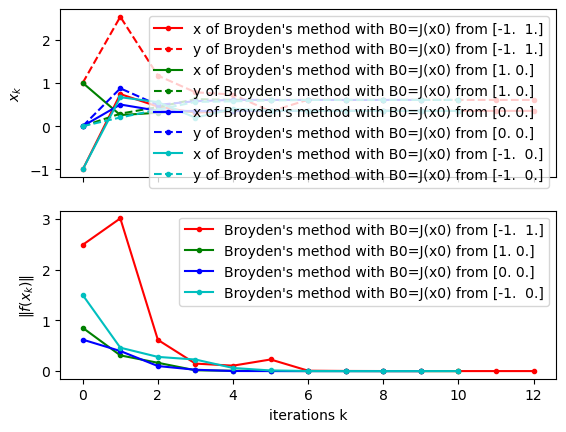

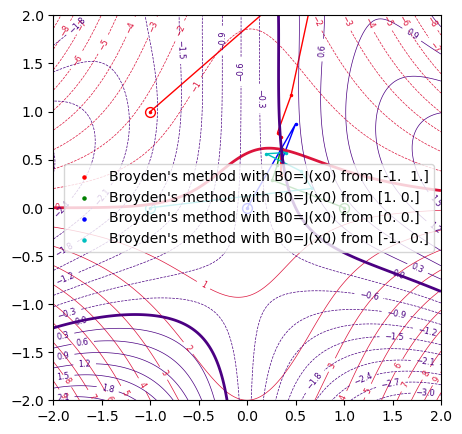

In [32]:
f = Function2D()

callback_list = []

x0_list = [
    np.array([-1.0, 1.0]),
    np.array([1.0, 0.0]),
    np.array([0.0, 0.0]),
    np.array([-1.0, 0.0]),
]
for x0 in x0_list:

    cache_callback = CacheXk(f, x0, f"Broyden's method with B0=J(x0) from {x0}")

    x = broyden_method(
        f,      # 目的関数
        x0,     # 初期値
        B0=f.jac(x0),
        callback=cache_callback  # コールバック
    )
    print("x", x)
    print("fx", f(x))

    callback_list.append(cache_callback)

plot_cache = PlotCacheXk(callback_list)
figs = plot_cache.plot_2d()
# figs = plot_cache.plot_2d(plot_mse=True)

しかし，引数に初期ヤコビ行列与えない場合（単位行列で初期化）には収束が難しいことが分かる．


x [0.35324662 0.60608174]
fx [1.05471187e-14 1.77635684e-15]
x [0.35324662 0.60608174]
fx [-4.45754544e-13  2.17936780e-13]
x [0.35324662 0.60608174]
fx [8.83737528e-14 4.42978987e-14]


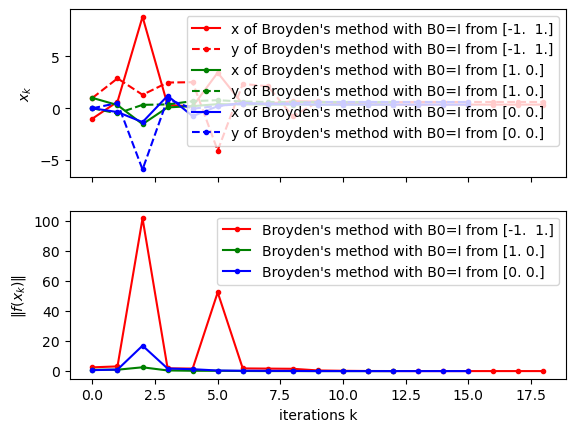

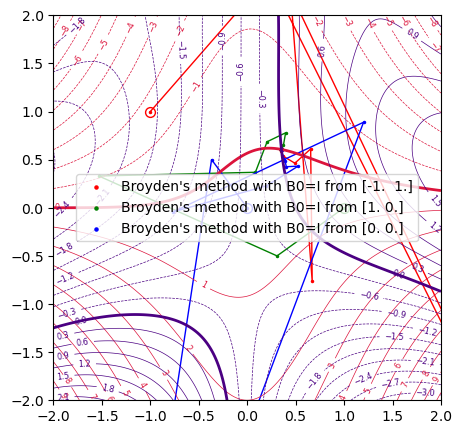

In [33]:
f = Function2D()

callback_list = []

x0_list = [
    np.array([-1.0, 1.0]),
    np.array([1.0, 0.0]),
    np.array([0.0, 0.0]),
    # np.array([-1.0, 0.0]),  # 収束しない
]
for x0 in x0_list:

    cache_callback = CacheXk(f, x0, f"Broyden's method with B0=I from {x0}")

    x = broyden_method(
        f,      # 目的関数
        x0,     # 初期値
        callback=cache_callback  # コールバック
    )
    print("x", x)
    print("fx", f(x))

    callback_list.append(cache_callback)

plot_cache = PlotCacheXk(callback_list)
figs = plot_cache.plot_2d()
# figs = plot_cache.plot_2d(plot_mse=True)

#### 1.3.2.3. <a id='toc1_3_2_3_'></a>[scipyの実装](#toc0_)


[scipy](https://docs.scipy.org/)には，多次元非線形方程式を解くためのソルバー`scipy.optimize.root()`が提供されている．
引数には目的関数`f`と初期値`x0`を与える．
引数`method`にはソルバーを指定する文字列を与える．
一般的なソルバーが複数実装されており，
Broyden法については，ヤコビ行列の近似方法が異なる2種類の実装されている．

- `"broyden1"`：Broyden’s "good" method．上記で説明した，一般的に用いられているヤコビ行列の更新式．
- `"broyden2"`：Broyden’s "bad" method．

- <https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root.html>
    > Find a root of a vector function.

なお`scipy.optimize.root()`はコールバック用の引数`callback`を持っているが，
対応していないソルバーが多い．そこで1次元の場合と同様に，
可変長引数`args`にコールバックに与え，関数`f`の中でコールバックを呼び出す．

以下のコードでは，このソルバーを用いて多次元非線形方程式を解き，それぞれの手法の挙動を確認する．


In [34]:
f = Function2D()

x0 = np.array([0.8, 0.2])


cache_callback_broyden1 = CacheXk(f, x0, "Boryden's of scipy broyden1")
result = scipy.optimize.root(
    f,      # 目的関数
    x0,     # 初期値
    method="broyden1",  # Broyden’s good method．これが上記で紹介した更新式
    args=cache_callback_broyden1,  # コールバック
)
print("x", result.x)
print("fx", f(result.x))
print(result)


cache_callback_broyden2 = CacheXk(f, x0, "Boryden's of scipy broyden2")
result = scipy.optimize.root(
    f,      # 目的関数
    x0,     # 初期値
    method="broyden2",  # Broyden’s bad method
    args=cache_callback_broyden2,  # コールバック
)
print("x", result.x)
print("fx", f(result.x))
print(result)


x [0.35324776 0.60608041]
fx [9.57348688e-07 1.39664448e-06]
 message: A solution was found at the specified tolerance.
 success: True
  status: 1
     fun: [ 9.573e-07  1.397e-06]
       x: [ 3.532e-01  6.061e-01]
     nit: 10
  method: broyden1
    nfev: 20
x [0.35324666 0.60608189]
fx [-1.38822562e-07  7.47963189e-08]
 message: A solution was found at the specified tolerance.
 success: True
  status: 1
     fun: [-1.388e-07  7.480e-08]
       x: [ 3.532e-01  6.061e-01]
     nit: 12
  method: broyden2
    nfev: 33


返り値は，実行終了時の情報を持つオブジェクト（[OptimizeResult](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.OptimizeResult.html)）である．

- **x**：得られた最適解（関数の根）．
- **fun**：最適解における非線形方程式の値．
- **nit**：反復回数．
- その他，収束状況を示す情報が含まれる．


以下のコードは，異なるBroyden法の収束の様子をプロットするものである．
ヤコビ行列の近似方法や初期値が異なるため，挙動は異なる．


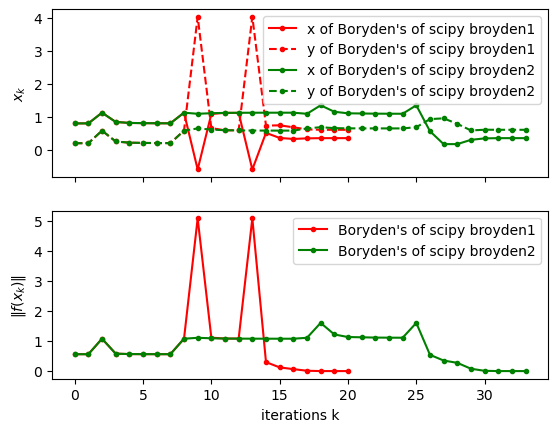

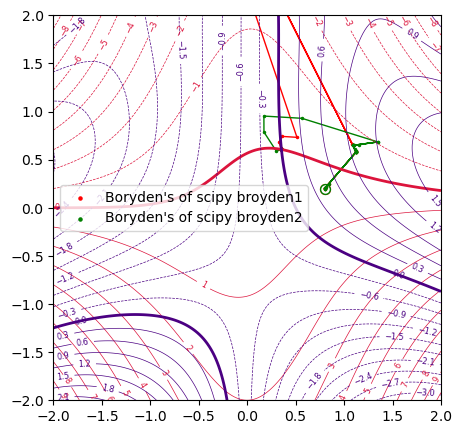

In [35]:
plot_cache = PlotCacheXk([
    cache_callback_broyden1,
    cache_callback_broyden2,
])
figs = plot_cache.plot_2d()
# figs = plot_cache.plot_2d(plot_mse=True)


以下のコードはBroyden's good methodをソルバーとするBroyden法を，異なる初期値から実行する例である．


x [0.35324642 0.60608221]
fx [-3.71643897e-07 -2.14820764e-07]
x [0.35324664 0.60608171]
fx [2.10926280e-08 2.03730322e-08]
x [0.35324646 0.60608299]
fx [-1.05287475e-06 -4.67854753e-08]


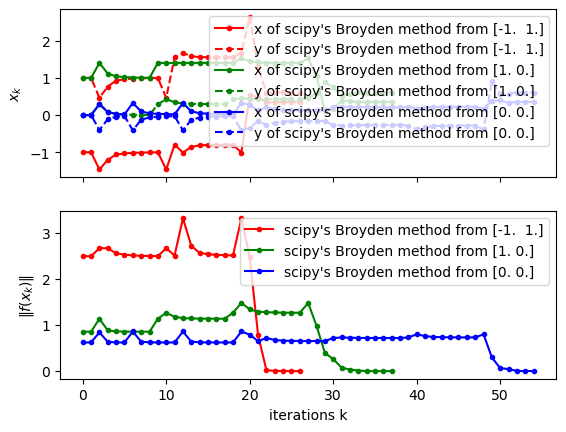

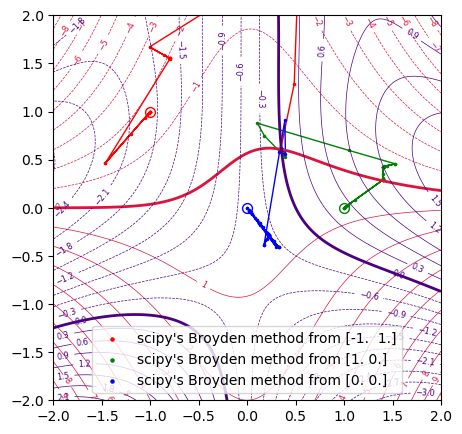

In [36]:
f = Function2D()

callback_list = []

x0_list = [
    np.array([-1.0, 1.0]),
    np.array([1.0, 0.0]),
    np.array([0.0, 0.0]),
    # np.array([-1.0, 0.0]),  # 収束しない
]
for x0 in x0_list:

    cache_callback = CacheXk(f, x0, f"scipy's Broyden method from {x0}")

    x = scipy.optimize.root(
        f,
        x0,
        # method="broyden1",
        method="broyden2",
        args=cache_callback,
        options={
            'maxiter': 20,
        }
    ).x

    print("x", x)
    print("fx", f(x))

    callback_list.append(cache_callback)

plot_cache = PlotCacheXk(callback_list)
figs = plot_cache.plot_2d()
# figs = plot_cache.plot_2d(plot_mse=True)

### 1.3.3. <a id='toc1_3_3_'></a>[信頼領域法：Powell法](#toc0_)

ニュートン法の数値的不安定性を回避するためにｍ，信頼領域法（dogleg法）を用いた手法が提案されている．その中でも代表劇な手法がPowell法（Powell's method）であり，
ヤコビ行列の近似更新や，解の更新量の判定などを組み合わせて，収束を安定させている．

`scipy.optimize.root()`には，修正ハイブリッドPowell法`"hybr"`が実装されている．内部的には，非線形方程式を解くための有名なパッケージである[MINPACK](https://ja.wikipedia.org/wiki/MINPACK)の`hybrd`（ヤコビ行列を前進差分で近似）および`hybrj`（解析的に与えられたヤコビ行列を利用）を利用している．

- https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root.html
  > Method hybr uses a modification of the Powell hybrid method as implemented in MINPACK [1].
  <!-- - https://github.com/scipy/scipy/blob/bf819ba58a6ccd51cc6d6dacf88ab18a80355148/scipy/optimize/_minpack_py.py#L243C39-L243C39
  - https://github.com/scipy/scipy/blob/bf819ba58a6ccd51cc6d6dacf88ab18a80355148/scipy/optimize/_minpack_py.py#L249 -->
- [minpack on netlib](https://www.netlib.org/minpack/)
  - solve systems of nonlinear equations (analytic jacobian) https://www.netlib.org/minpack/hybrj.f
      <!-- > the purpose of hybrj is to find a zero of a system of
      > n nonlinear functions in n variables by a modification
      > of the powell hybrid method. the user must provide a
      > subroutine which calculates the functions and the jacobian. -->
  - solve systems of nonlinear equations (approximate jacobian) https://www.netlib.org/minpack/hybrd.f
      <!-- > the purpose of hybrd is to find a zero of a system of
      > n nonlinear functions in n variables by a modification
      > of the powell hybrid method. the user must provide a
      > subroutine which calculates the functions. the jacobian is
      > then calculated by a forward-difference approximation. -->
    <!-- - ヤコビ行列は前進差分近似 -->



以下のコードは，`scipy.optimize.root()`を用いて修正ハイブリッドPowell法を実行する例である．Broyden法とは異なり，収束が安定していることがわかる．

x [0.35324662 0.60608174]
fx [-3.16413562e-14 -1.55431223e-15]
x [0.35324662 0.60608174]
fx [ 3.61932706e-14 -3.69704267e-14]
x [0.35324662 0.60608174]
fx [-4.37316849e-13  1.13709042e-12]
x [0.35324662 0.60608174]
fx [-1.89737115e-13  1.96398453e-13]


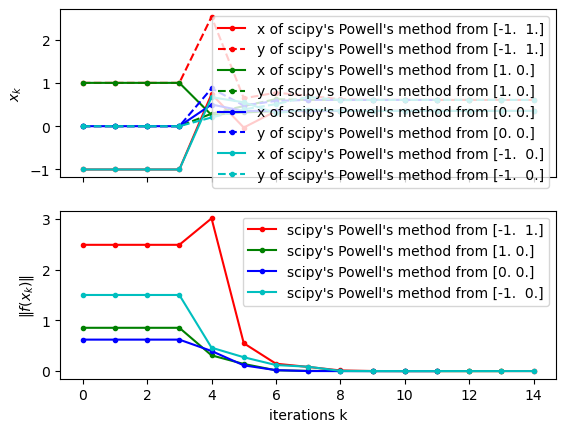

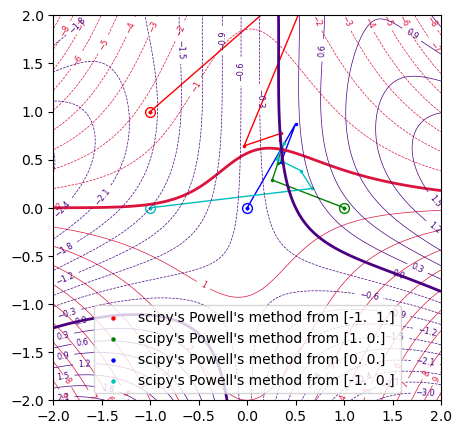

In [37]:
f = Function2D()

callback_list = []

x0_list = [
    np.array([-1.0, 1.0]),
    np.array([1.0, 0.0]),
    np.array([0.0, 0.0]),
    np.array([-1.0, 0.0]),
]
for x0 in x0_list:

    cache_callback = CacheXk(f, x0, f"scipy's Powell's method from {x0}")

    x = scipy.optimize.root(
        f,                # 目的関数
        x0,               # 初期値
        jac=f.jac,        # ヤコビ行列
        method="hybr",    # 修正ハイブリッドPowell法
        args=cache_callback,  # コールバック
    ).x

    print("x", x)
    print("fx", f(x))

    callback_list.append(cache_callback)

plot_cache = PlotCacheXk(callback_list)
figs = plot_cache.plot_2d()
# figs = plot_cache.plot_2d(plot_mse=True)

## 1.4. <a id='toc1_4_'></a>[多次元（$m \neq n$）](#toc0_)


多次元の場合で$m=n$のときには，ヤコビ行列が正則であれば連立方程式を解くことができた（逆行列が存在した）
そのため，ニュートン法などの手法を利用することができた．


しかし$m \neq n$の場合には，ヤコビ行列が正方行列ではないため，逆行列が存在せず，ニュートン法を適用することはできない．



そこで，次のような非線形方程式
$$
\boldsymbol{f}(\boldsymbol{x})=\boldsymbol{0},
\quad
\boldsymbol{x} \in R^n, \boldsymbol{f}(\boldsymbol{x}) \in R^m
$$
を解く問題を，以下の最適化問題に置き換えて解くことを考える．
$$
\min_{\boldsymbol{x}} \frac{1}{2} \| \boldsymbol{f}(\boldsymbol{x}) \|_2^2
$$
ここで，目的関数の$1/2$の係数と$L_2$ノルムの2乗は，後述する導出の都合上導入されている．

この最適化問題を解くために，様々な手法が利用可能である．特に，非線形最小二乗問題を効率的に解くための最適化手法として以下の2つが一般的に用いられる．

- Gauss-Newton法（GN法）
- Levenberg-Marquardt法（LM法）






### 1.4.1. <a id='toc1_4_1_'></a>[非線形最小二乗問題](#toc0_)

非線形最小二乗問題とは，複数の非線形関数の二乗和を最小化する最適化問題である．
ここでは，以下の非線形最小二乗問題を考える．
$$
\min_{\boldsymbol{x}} \frac{1}{2} \sum_{i=1}^m f_i^2(\boldsymbol{x})
$$
ここで非線形ベクトル値関数$\boldsymbol{f}(\boldsymbol{x})$を次のように定義する．
$$
\boldsymbol{f} (\boldsymbol{x}) = (f_1(\boldsymbol{x}), f_2(\boldsymbol{x}), \ldots, f_m(\boldsymbol{x}))^T
$$
すると，目的関数$F(\boldsymbol{x})$は以下のように書ける．
$$
F(\boldsymbol{x})
= \frac{1}{2} \sum_{i=1}^m f_i^2(\boldsymbol{x})
= \frac{1}{2} \| \boldsymbol{f}(\boldsymbol{x}) \|^2
$$

この最適化問題において，$\boldsymbol{f}(\boldsymbol{x}) = \boldsymbol{0}$を満たす解を求めたい場合，最適化問題の解が以下を満たすことを期待する．
$$
\min_{\boldsymbol{x}} F(\boldsymbol{x}) = 0
$$
ただし，実際の議論では，$F(\boldsymbol{x})$が0にならない場合も含む，より一般的な非線形最小二乗問題を考える．


非線形最小二乗問題は最適化問題であるため，目的関数の最小化のためには，勾配ベクトルとヘッセ行列を利用できる．ただし，ヘッセ行列の計算には大きな計算コストがかかる．そのため，計算量の大きいヘッセ行列を，計算量の小さい勾配ベクトルで近似することを考える．
この方法は最適化問題における準ニュートン法と類似しているが，準ニュートン法ではヘッセ行列自体を逐次更新するためメモリ消費が大きくなる．以下で説明する手法では，代わりに勾配ベクトルを用いてヘッセ行列を逐次的に近似する．


### 1.4.2. <a id='toc1_4_2_'></a>[最小二乗問題のヘッセ行列の導出と近似](#toc0_)

#### 1.4.2.1. <a id='toc1_4_2_1_'></a>[$m=1$の場合](#toc0_)

まず$m=1$の場合，つまり以下の場合を考える．
\begin{align*}
F(\boldsymbol{x}) &= \frac{1}{2} f (\boldsymbol{x})^2
\end{align*}

このときの，目的関数$F(\boldsymbol{x})$のヘッセ行列と，
二乗する前の関数$f(\boldsymbol{x})$のヘッセ行列との関係を考える．
なお以下では表記を簡単にするために$(\boldsymbol{x})$を省略する．


**勾配ベクトルの計算**

まず，$F(\boldsymbol{x})$の勾配ベクトルの各要素を計算すると，以下のようになる．

\begin{align*}
\frac{\partial}{\partial x_i} F
&= f \frac{\partial f}{\partial x_i}
\end{align*}

これをベクトル形式で表すと，次のようになる．

\begin{align*}
\frac{\partial}{\partial \boldsymbol{x}} F
&= f \frac{\partial f}{\partial \boldsymbol{x}}
\\
\nabla F &= f \nabla f
\end{align*}


**ヘッセ行列の計算**

次に，$F(\boldsymbol{x})$の2次微分であるヘッセ行列$\nabla^2 F$を計算する．
各要素を計算すると，以下のようになる．

\begin{align*}
\frac{\partial^2}{\partial x_i \partial x_j} F(\boldsymbol{x})
&=
\frac{\partial}{\partial x_i}
\left(
\frac{1}{2} \frac{\partial}{\partial x_j} f^2
\right)
\\
&=
\frac{\partial}{\partial x_i}
\left(
f \frac{\partial f}{\partial x_j}
\right)
\\
&=
\frac{\partial f}{\partial x_i}
\frac{\partial f}{\partial x_j}
+ f
\frac{\partial f}{\partial x_i \partial x_j}
\end{align*}

この行列の要素を並べて書くと，次のようになる．

\begin{align*}
\nabla^2 F
&=
\begin{pmatrix}
  \frac{\partial f}{\partial x_1} \frac{\partial f}{\partial x_1},
& \frac{\partial f}{\partial x_1} \frac{\partial f}{\partial x_2},
& \ldots \\
  \frac{\partial f}{\partial x_2} \frac{\partial f}{\partial x_1},
& \frac{\partial f}{\partial x_2} \frac{\partial f}{\partial x_2},
& \ldots \\
\vdots
\end{pmatrix}
+
f
\begin{pmatrix}
  \frac{\partial^2 f}{\partial x_1^2},
& \frac{\partial f}{\partial x_1 \partial x_2}
& \ldots \\
  \frac{\partial^2 f}{\partial x_2 \partial x_1},
& \frac{\partial^2 f}{\partial x_2^2},
& \ldots \\
\vdots
\end{pmatrix}
\end{align*}

これは行列とベクトルを用いて次のようにかける．

\begin{align*}
\nabla^2 F
&=
\nabla f (\nabla f)^T + f (\nabla^2 f)
\end{align*}

つまり$F$のヘッセ行列は，
$f$の勾配ベクトル$\nabla f$の直積による項（一次微分の項）と，
元の関数$f$とそのヘッセ行列$\nabla^2 f$による項（二次微分の項）の
2つの項に分離できることがわかる．


なお$(\boldsymbol{x})$を省略せずに書き直すと，以下のようになる．

\begin{align*}
\nabla^2 F(\boldsymbol{x})
&= \nabla f(\boldsymbol{x}) (\nabla f(\boldsymbol{x}))^T + f(\boldsymbol{x}) (\nabla^2 f(\boldsymbol{x}))
\end{align*}




#### 1.4.2.2. <a id='toc1_4_2_2_'></a>[$m > 1$の場合](#toc0_)

次に，$m > 1$の場合について同様に考える．この場合，目的関数$F(\boldsymbol{x})$は次のように定義される．

\begin{align*}
F(\boldsymbol{x})
&=
\frac{1}{2} \sum_{i=1}^m f_i (\boldsymbol{x})^2
=
\frac{1}{2}
\| \boldsymbol{f}(\boldsymbol{x}) \|_2^2
\end{align*}

以下では表記を簡単にするために$(\boldsymbol{x})$を省略する．

**勾配ベクトルの計算**

$m = 1$の場合の結果を利用して，以下のように各$i$について和を取ることで勾配ベクトルを求める．

\begin{align*}
\nabla F =
\sum_{i=1}^m f_i \nabla f_i
=
\left( \nabla f_1, \nabla f_2, \ldots \right)
\begin{pmatrix}
f_1 \\ f_2 \\ \vdots
\end{pmatrix}
=
J^T \boldsymbol{f}
\end{align*}

ここで$\nabla f_i$は$f_i$の勾配ベクトル，$J$はヤコビ行列である．


**ヘッセ行列の計算**

ヘッセ行列も，
$m = 1$の場合の結果を利用して，以下のように各$i$について和を取る．

\begin{align*}
H =
\nabla^2 F
&=
\sum_{i=1}^m \nabla f_i (\nabla f_i)^T + f_i (\nabla^2 f_i)
\\
&=
\left( \nabla f_1, \nabla f_2, \ldots \right)
\begin{pmatrix}
\nabla f_1^T \\ \nabla f_2^T \\ \vdots
\end{pmatrix}
+ \sum_{i=1}^m f_i (\nabla^2 f_i)
\\
&=
J^T J + \sum_{i=1}^m f_i (\nabla^2 f_i)
\end{align*}

したがって，$m=1$の結果と同様に，$F$のヘッセ行列は2つの項に分離できることが分かる．
第1項$J^T J$はヤコビ行列，つまり$f$の1次微分からなる．
第2項$\sum_{i=1}^m f_i (\nabla^2 f_i)$は
$f$の2次微分（ヘッセ行列）を含む．

このように，ヘッセ行列の計算には二次微分の項が含まれるため，計算コストが高くなる．
そのため，非線形最小二乗法では，このヘッセ行列の第2項を無視してヘッセ行列の近似を行うことがある．これにより，
ヘッセ行列は
$$
H \approx J^T J
$$
と近似できる．
これをヘッセ行列の**Gauss-Newton近似**と呼ぶ．



### 1.4.3. <a id='toc1_4_3_'></a>[Gauss-Newton法（GN）](#toc0_)

Gauss-Newton法は，ヘッセ行列のGauss-Newton近似を用いて$F$の最小化をニュートン法で行う方法である．


ニュートン法では，更新方向（ニュートンステップ）$\boldsymbol{d}$は以下の式で計算される．
$$
\boldsymbol{d} = - H^{-1} \nabla F
$$
ここで，$H$は$F(\boldsymbol{x})$のヘッセ行列，$\nabla F$は$F(\boldsymbol{x})$の勾配ベクトルである．

Gauss-Newton法では，ヘッセ行列を$H \approx J^T J$で近似する．
また非線形最小二乗法の場合には，
勾配ベクトルは上記で導出したように$\nabla F = J^T \boldsymbol{f}$であるので，
これらを代入すると，以下の式が得られる．
$$
\boldsymbol{d} = - (J^T J)^{-1} J^T \boldsymbol{f}
$$
となる．

#### 1.4.3.1. <a id='toc1_4_3_1_'></a>[GN法のアルゴリズム](#toc0_)

- 収束するまで以下を反復
    1. $\boldsymbol{d}^{(k)} = - ( J^T J )^{-1} J^T \boldsymbol{f}$
        - $J^T J  \boldsymbol{d}^{(k)} = - J^T \boldsymbol{f}$を解く
    1. $\boldsymbol{x}^{(k+1)} = \boldsymbol{x}^{(k)} + \alpha \boldsymbol{d}^{(k)}$

なお，実際には$\boldsymbol{x}^{(k)}$を省略せず，$J=J(\boldsymbol{x}^{(k)})$，$\boldsymbol{f}=\boldsymbol{f}(\boldsymbol{x}^{(k)})$であり，ステップ毎に計算される．

- [金森敬文, 鈴木大慈, 竹内一郎, 佐藤一誠, 機械学習のための連続最適化, 講談社, 2016](https://www.kspub.co.jp/book/detail/1529205.html), p.86, 5.4 ガウス・ニュートン法と関連する話題.
- [G. A. F. Seber, C. J. Wild, Nonlinear Regression, John Wiley & Sons, 1989](https://onlinelibrary.wiley.com/doi/book/10.1002/0471725315), p.621, 14.1 Gauss-Newton Algorithm
- [金谷健一, これなら分かる最適化数学, 共立出版, 2005](https://www.kyoritsu-pub.co.jp/book/b10010407.html), p.130, 4.3.1 ガウス・ニュートン法.
- [Dimitri P. Bertsekas, Nonlinear Programming, 3rd Edition,  Athena Scientific, 2016](http://www.athenasc.com/nonlinbook.html), p.112, The Gauss-Newton Method.
- [Amir Beck, Introduction to Nonlinear Optimization: Theory, Algorithms, and Applications with Python and MATLAB, SIAM, 2014](https://sites.google.com/site/amirbeck314/books), p.67, 4.5 The Gauss-Newton Method.



### 1.4.4. <a id='toc1_4_4_'></a>[Levenberg-Marquardt法（LM）](#toc0_)


Levenberg-Marquardt法は，Gauss-Newton法を改良した手法である．これは，最適化問題におけるニュートン法の改良手法である修正ニュートン法に対応するものであり，ヘッセ行列$J^T J$が正定値になるように，以下のように正則化項$\lambda^{(k)} \boldsymbol{I}$を加える．

$$
\boldsymbol{d} = - (J^T J + \lambda^{(k)} \boldsymbol{I})^{-1} J^T \boldsymbol{f}
$$
ここで$\boldsymbol{I}$は一般的には単位行列$I$であるが，
ヘッセ行列の対角要素だけからなる対角行列などが用いられる<sup>1</sup>こともある．

- <sup>1</sup> [G. A. F. Seber, C. J. Wild, Nonlinear Regression, John Wiley & Sons, 1989](https://onlinelibrary.wiley.com/doi/book/10.1002/0471725315), p.621, 14.2.2 Levenberg-Marquardt Methods
- [金谷健一, これなら分かる最適化数学, 共立出版, 2005](https://www.kyoritsu-pub.co.jp/book/b10010407.html)，4.3.1 レーベンバーグ・マーカート法, p.132
- [金森敬文, 鈴木大慈, 竹内一郎, 佐藤一誠, 機械学習のための連続最適化, 講談社, 2016](https://www.kspub.co.jp/book/detail/1529205.html), p.88, 5.4.2 レーベンバーグ・マーカート法.


#### 1.4.4.1. <a id='toc1_4_4_1_'></a>[LM法のアルゴリズム](#toc0_)

LM法のアルゴリズムは，単純に書けば以下のようになる．

- 収束するまで以下を反復
    1. $\boldsymbol{d}^{(k)} = - ( J^T J + \lambda^{(k)} \boldsymbol{I})^{-1} J^T \boldsymbol{f}$
        - $(J^T J + \lambda^{(k)} \boldsymbol{I}) \boldsymbol{d}^{(k)} = - J^T \boldsymbol{f}$を解く
    1. $\boldsymbol{x}^{(k+1)} = \boldsymbol{x}^{(k)} + \alpha \boldsymbol{d}^{(k)}$

ここで$\lambda^{(k)}$は反復ごとに調整される正則化パラメータである．
Levenberg-Marquardt法の特徴は，信頼領域法が信頼半径を反復毎に動的に調整したのと同じように，反復毎に$\lambda^{(k)}$を動的に調整する点にある．
目的関数値が下がる場合には小さくし（ニュートン方向に近くなる），
またそうでない場合には大きくする（最急降下方向に近くなる）ように更新する．

$\lambda^{(k)}$を動的に変更するLM法の実際のアルゴリズムは以下のようになる．

- 初期値$x^{(0)}, \lambda^{(0)}, k=0$
- 収束するまで以下を反復
    1. $\boldsymbol{d}^{(k)} = - \left(J^T J + \lambda^{(k)} \boldsymbol{I} \right)^{-1} J^T \boldsymbol{f}$
    1. 目的関数値が減少する（$\| \boldsymbol{f}(\boldsymbol{x}^{(k)}) \| > \| \boldsymbol{f}(\boldsymbol{x}^{(k)} + \alpha^{(k)} \boldsymbol{d}^{(k)}) \|$）なら
        1. 解を更新する：$\boldsymbol{x}^{(k+1)} = \boldsymbol{x}^{(k)} + \alpha^{(k)} \boldsymbol{d}^{(k)}$
        1. $\lambda^{(k)}$を減少させ，更新方向をニュートン方向に近づける：$\lambda^{(k+1)} \leftarrow \gamma_1 \lambda^{(k)}$
    1. 目的関数値が減少しない（$\| \boldsymbol{f}(\boldsymbol{x}^{(k)}) \| < \| \boldsymbol{f}(\boldsymbol{x}^{(k)} + \alpha^{(k)} \boldsymbol{d}^{(k)}) \|$）なら
        1. 解を更新しない：$\boldsymbol{x}^{(k+1)} = \boldsymbol{x}^{(k)}$
        1. $\lambda^{(k)}$を増加させ，更新方向を最急降下方向に近づける：$\lambda^{(k+1)} \leftarrow \gamma_2 \lambda^{(k)}$
    1. $k \leftarrow k + 1$

ここで減少率$\gamma_1 < 1$と増加率$\gamma_2 > 1$の値は経験的に決定する（例えば$\lambda^{(0)}=1, \gamma_1=0.8, \gamma_2=2$）．

#### 1.4.4.2. <a id='toc1_4_4_2_'></a>[等高線の描画](#toc0_)

##### 1.4.4.2.1. <a id='toc1_4_4_2_1_'></a>[3つの非線形関数を重ねてプロットする](#toc0_)

以下は，3つの非線形方程式を2次元に可視化する手順の説明である．`Function2D`クラスに`m=3`を指定すると，3つ目の非線形関数が表示される．各関数の等高線が異なる色で描画されるため，個別の関数を区別できる．また，等高線は次のルールで描画される．

1. **正の領域**：実線で描画．
2. **負の領域**：破線で描画．
3. **ゼロの等高線**：太線で描画（解の候補となる線）．

解は，存在するならば，3本の太いゼロの等高線が交差する点である．

以下のコードは3つの非線形関数を重ねてプロットする例である．


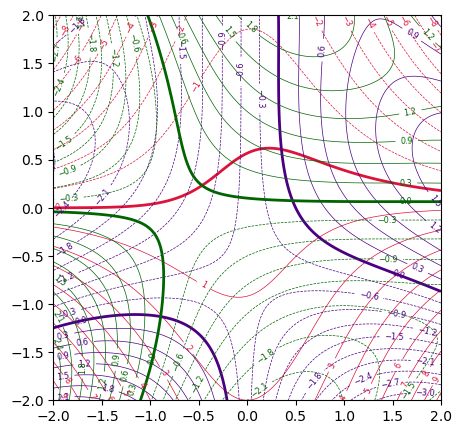

In [38]:
f = Function2D(m=3)

fig = plt.figure(figsize=(5, 5))
ax = fig.subplots()

visualize_f(f, ax)
# visualize_f(f, ax, plot_mse=True)

plt.show()


##### 1.4.4.2.2. <a id='toc1_4_4_2_2_'></a>[目的関数のノルムの二乗をプロットする](#toc0_)

`plot_mse=True`を指定すると，3つの非線形関数$f_1, f_2, f_3$そのものではなく，それらの値の二乗和$\|\boldsymbol{f}(\boldsymbol{x})\|^2$がプロットされる．これは非線形最小二乗法の目的関数である．
以下のコードはノルムの二乗をプロットする例である．


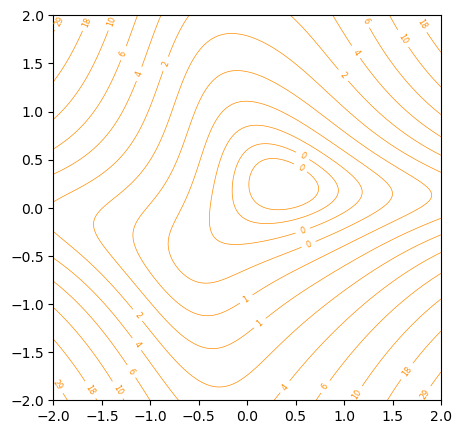

In [39]:
f = Function2D(m=3)

fig = plt.figure(figsize=(5, 5))
ax = fig.subplots()

# visualize_f(f, ax)
visualize_f(f, ax, plot_mse=True)

plt.show()


##### 1.4.4.2.3. <a id='toc1_4_4_2_3_'></a>[非線形関数と目的関数のプロットを重ねる](#toc0_)

次のコードは，3つの非線形関数の等高線と，目的関数を同時にプロットする．
重ねて描画することで，解の探索の様子が視覚的に把握しやすくなる．
ただし，プロットが込み入るため注意が必要である．


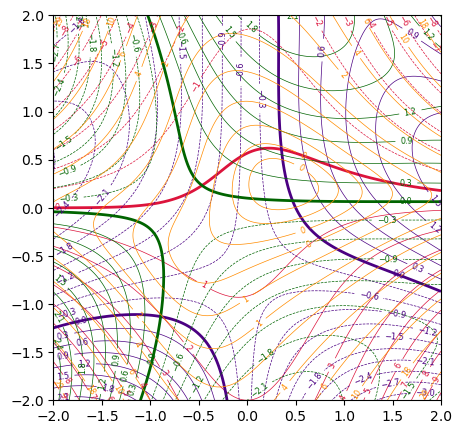

In [40]:
f = Function2D(m=3)

fig = plt.figure(figsize=(5, 5))
ax = fig.subplots()

visualize_f(f, ax)
visualize_f(f, ax, plot_mse=True)

plt.show()


#### 1.4.4.3. <a id='toc1_4_4_3_'></a>[Levenberg-Marquardt法の実装](#toc0_)

以下がLevenberg-Marquardt法の実装である．
ここで`lmd`は初期値$\lambda^{(0)}$を表す．


In [41]:
def levenberg_marquardt(
        f: callable,
        J: callable,
        x0: np.ndarray,
        lmd: float = 1.0,
        alpha: float = 0.5,
        gamma1: float = 0.8,
        gamma2: float = 2.0,
        maxiter: int = 100,
        callback: callable = None
) -> np.ndarray:
    """Levenberg-Marquardt 法

    Args:
        f (callable): 非線形方程式のベクトル値関数 f(x)
        J (callable): f(x) のヤコビ行列 J(x)
        x0 (np.ndarray): 初期値
        lmd (float, optional): 正則化パラメータ λ の初期値．デフォルトは 1.0
        alpha (float, optional): ステップサイズ．デフォルトは 0.5
        gamma1 (float, optional): λの減少率．デフォルトは 0.8
        gamma2 (float, optional): λの増加率．デフォルトは 2.0
        maxiter (int, optional): 最大反復回数．デフォルトは 100
        callback (callable, optional): 各反復ごとに呼び出されるコールバック関数．デフォルトは None

    Returns:
        np.ndarray: 解 \hat{x}
    """
    n = len(x0)
    m = len(f(x0))
    assert J(x0).shape == (m, n)

    x = x0.copy()
    I = np.eye(n)
    for k in range(maxiter):
        J_x = J(x)  # ヤコビ行列 J(x)
        f_x = f(x)  # 関数値 f(x)

        # 解の更新方向dを計算
        d = solve(J_x.T @ J_x + lmd * I, - J_x.T @ f_x)
        x_next = x + alpha * d  # 解を更新

        if norm(f_x) > norm(f(x_next)):  # 目的関数値が減少する場合
            x = x_next  # 解を更新
            lmd *= gamma1  # λ を減少
        else:  # 目的関数値が減少しない場合
            lmd *= gamma2  # λ を増加

        if callback:
            callback(x)

        if np.isclose(norm(f_x), 0):
            return x

    return x


<>:26: SyntaxWarning: invalid escape sequence '\h'
<>:26: SyntaxWarning: invalid escape sequence '\h'
C:\Users\sayuk\AppData\Local\Temp\ipykernel_50352\971431695.py:26: SyntaxWarning: invalid escape sequence '\h'
  np.ndarray: 解 \hat{x}


以下は，Levenberg-Marquardt法の収束の様子をプロットしたものである．
この非線形最小二乗問題では，3つの非線形関数を同時にゼロにする解は存在しないが，
目的関数を最小化する方向に収束していく様子がわかる．


x [0.36212601 0.23827601]
fx [ 0.30824088 -0.06369297  0.20829457]
x [0.36212601 0.23827601]
fx [ 0.30824088 -0.06369296  0.20829457]
x [0.362126   0.23827601]
fx [ 0.30824088 -0.06369298  0.20829457]
x [0.362126   0.23827601]
fx [ 0.30824088 -0.06369297  0.20829457]


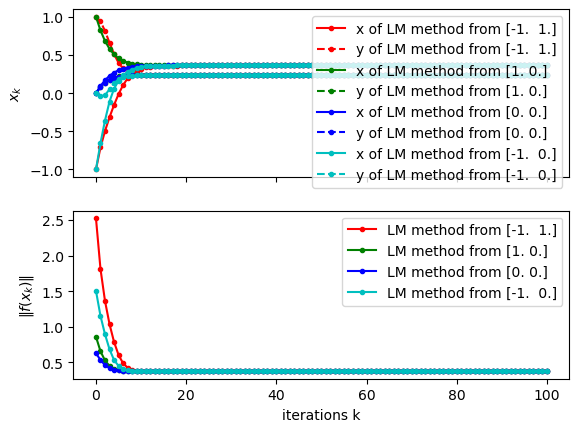

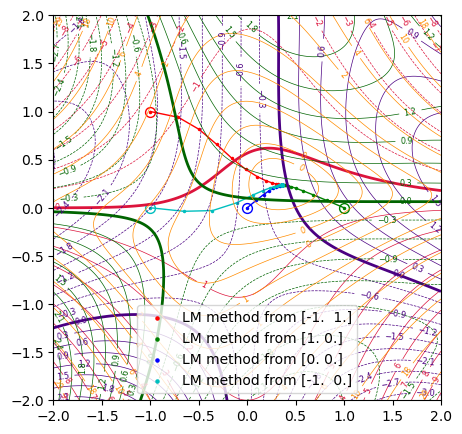

In [42]:
f = Function2D(m=3)

callback_list = []

x0_list = [
    np.array([-1.0, 1.0]),
    np.array([1.0, 0.0]),
    np.array([0.0, 0.0]),
    np.array([-1.0, 0.0]),
]
for x0 in x0_list:

    cache_callback = CacheXk(f, x0, f"LM method from {x0}")

    x = levenberg_marquardt(
        f,      # 目的関数
        f.jac,  # ヤコビ行列
        x0,     # 初期値
        # alpha=1.0,  # ステップサイズ
        # lmd=1.0,    # λの初期値
        callback=cache_callback  # コールバック
    )
    print("x", x)
    print("fx", f(x))

    callback_list.append(cache_callback)

plot_cache = PlotCacheXk(callback_list)
figs = plot_cache.plot_2d(plot_mse=True)

#### 1.4.4.4. <a id='toc1_4_4_4_'></a>[scipyの実装](#toc0_)

`scipy.optimize.root()`にはLM法`"lm"`が実装されている．この内部では，最小化手法で広く使用されているパッケージである[MINPACK](https://ja.wikipedia.org/wiki/MINPACK)のlmdif/lmderを利用している．

- https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root.html
    <!-- > Method lm solves the system of nonlinear equations in a least squares sense using a modification of the Levenberg-Marquardt algorithm as implemented in MINPACK [1].
    - https://github.com/scipy/scipy/blob/bf819ba58a6ccd51cc6d6dacf88ab18a80355148/scipy/optimize/_minpack_py.py#L433C27-L433C33
    - https://github.com/scipy/scipy/blob/bf819ba58a6ccd51cc6d6dacf88ab18a80355148/scipy/optimize/_minpack_py.py#L442C29-L442C29 -->
- [minpack on netlib](https://www.netlib.org/minpack/)
  - solve nonlinear least squares problem (analytic jacobian) https://www.netlib.org/minpack/lmder.f
      <!-- > the purpose of lmder is to minimize the sum of the squares of
      > m nonlinear functions in n variables by a modification of
      > the levenberg-marquardt algorithm. the user must provide a
      > subroutine which calculates the functions and the jacobian. -->
  - solve nonlinear least squares problem (approximate jacobian) https://www.netlib.org/minpack/lmdif.f
      <!-- > the purpose of lmdif is to minimize the sum of the squares of
      > m nonlinear functions in n variables by a modification of
      > the levenberg-marquardt algorithm. the user must provide a
      > subroutine which calculates the functions. the jacobian is
      > then calculated by a forward-difference approximation.
    - ヤコビ行列は前進差分近似 -->


x [0.362124   0.23827544]
fx [ 0.30824106 -0.06369552  0.20829353]
x [0.36212373 0.23827536]
fx [ 0.30824109 -0.06369587  0.20829338]
x [0.36212786 0.23827654]
fx [ 0.30824072 -0.06369062  0.20829553]
x [0.3621284 0.2382767]
fx [ 0.30824067 -0.06368992  0.20829582]


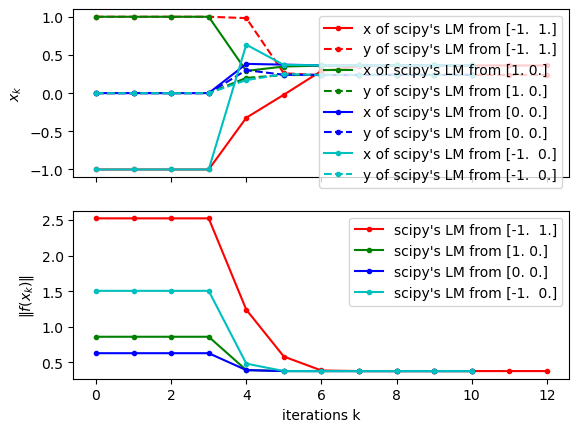

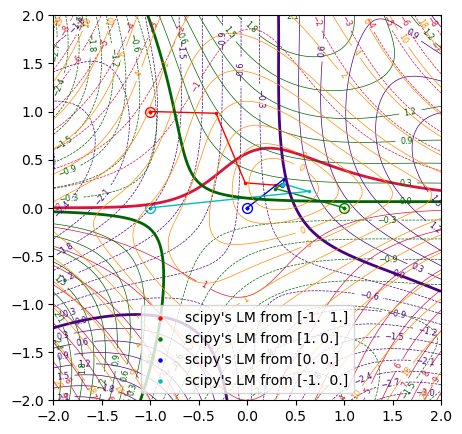

In [43]:
f = Function2D(m=3)

callback_list = []

x0_list = [
    np.array([-1.0, 1.0]),
    np.array([1.0, 0.0]),
    np.array([0.0, 0.0]),
    np.array([-1.0, 0.0]),
]
for x0 in x0_list:

    cache_callback = CacheXk(f, x0, f"scipy's LM from {x0}")

    x = scipy.optimize.root(
        f,            # 目的関数
        x0,           # 初期値
        jac=f.jac,    # ヤコビ行列
        method="lm",  # LM法
        args=cache_callback,  # コールバック
    ).x
    print("x", x)
    print("fx", f(x))

    callback_list.append(cache_callback)

plot_cache = PlotCacheXk(callback_list)
figs = plot_cache.plot_2d(plot_mse=True)

### 1.4.5. <a id='toc1_4_5_'></a>[最小二乗法による解釈](#toc0_)

これまで説明したGauss-Newton法やLevenberg-Marquardt法では，非線形連立方程式を非線形最小二乗問題に置き換え，ニュートン法をヘッセ行列のGauss-Newton近似を用いて最適化問題を解く，という導出を行った．

ここでは別の観点として，非線形連立方程式のニュートン法を**最小二乗法**で解釈する方法について述べる．


#### 1.4.5.1. <a id='toc1_4_5_1_'></a>[連立方程式の最小二乗解](#toc0_)

まず，$n$次元ベクトル$\boldsymbol{x} \in R^n$，
$m \times n$行列$A \in R^{m\times n}$，
$m$次元ベクトル$\boldsymbol{b} \in R^m$について，以下の連立方程式を考える．

$$
A \boldsymbol{x} = \boldsymbol{b}
$$

もし$m=n$かつ$A$が正則であれば，連立方程式の解法
（Gaussの消去法やLU分解などの直接法，Gauss-Seidel法などの反復法）
を用いて解を求めることができる．
しかし$m \neq n$の場合にはそれらの解法は使えない．

一方，$m > n$の場合には，上記の方法を適用することはできない．
この場合，次の最小二乗問題を解くことによって最小二乗解を求めることができる．

\begin{align*}
\min_{\boldsymbol{x}}
\frac{1}{2} \| A \boldsymbol{x} - \boldsymbol{b} \|^2
\end{align*}

まず目的関数を以下のように変形する．

\begin{align*}
f(\boldsymbol{x})
&=
\frac{1}{2} \| A \boldsymbol{x} - \boldsymbol{b} \|^2
\\
&=
\frac{1}{2} (A \boldsymbol{x} - \boldsymbol{b})^T
(A \boldsymbol{x} - \boldsymbol{b})\\
&=
\frac{1}{2} \boldsymbol{x}^T A^T A \boldsymbol{x}
- \boldsymbol{x}^T A^T \boldsymbol{b}
+ \frac{1}{2} \boldsymbol{b}^T \boldsymbol{b} \\
\end{align*}

つぎに勾配ベクトルを求め，0として解くと，次式が得られる．

\begin{align*}
\frac{\partial f}{\partial \boldsymbol{x}}
&=
A^T A \boldsymbol{x} - A^T \boldsymbol{b} = \boldsymbol{0} \\
A^T A \boldsymbol{x} &= A^T \boldsymbol{b}
\end{align*}

これは正規方程式（normal equation）と呼ばれる．
これを解くと，最小二乗解は次のように得られる．

\begin{align*}
\boldsymbol{x} &= (A^T A)^{-1} A^T \boldsymbol{b}
\end{align*}

ただし，この解を計算するためには$A^T A$が正則である（すなわち$|A^T A| \neq 0$）必要がある．


以下はランダムな連立方程式に対して，正規方程式を解いて解を求めるコードの例である．

In [44]:
m = 10
n = 3
A = rng.random(size=(m, n))
b = rng.random(m)

print("A\n", A)
print("b", b)

x = solve(A.T @ A, A.T @ b)
print("x", x)
print("Ax - b", A @ x - b)
print("||Ax - b||", norm(A @ x - b))


A
 [[0.4600282  0.6392561  0.28724969]
 [0.11769391 0.53395175 0.7851422 ]
 [0.88113488 0.82010711 0.00272813]
 [0.80588426 0.35360964 0.5163587 ]
 [0.95883756 0.36216679 0.0285035 ]
 [0.60192142 0.51410749 0.19530183]
 [0.47066589 0.526005   0.9782023 ]
 [0.23638861 0.11189935 0.5047428 ]
 [0.34343739 0.18775232 0.53240549]
 [0.25672052 0.49431509 0.13867233]]
b [0.96694456 0.24557168 0.3352986  0.06368491 0.03940643 0.82057764
 0.44962485 0.40420361 0.11174549 0.16505363]
x [-0.16409805  0.86357321  0.09439642]
Ax - b [-0.46327451  0.27033602  0.22858894  0.15818128  0.11869836 -0.45694652
  0.01972242 -0.29871533  0.04429215  0.23278647]
||Ax - b|| 0.85652766475106


この定式化を基に考えると，GN法は非線形連立方程式
$$
\boldsymbol{f}(\boldsymbol{x})=\boldsymbol{0}
$$
を解くために，まずニュートン法と同様に1次テーラー展開を適用して得られた連立1次方程式
$$
J \boldsymbol{d} = - \boldsymbol{f}
$$
を求める．次に，これに対応する最小二乗問題
$$
\min_{\boldsymbol{d}}
\frac{1}{2}
\| J \boldsymbol{d} + \boldsymbol{f} \|^2
$$
を考え，その正規方程式
$$
J^T J \boldsymbol{d} = - J^T \boldsymbol{f}
$$
の解である最小二乗解
$$
\boldsymbol{d} = - (J^T J)^{-1} J^T \boldsymbol{f}
$$
を，ニュートンステップ$\boldsymbol{d}$として採用している，とみなすことができる．


- [G. A. F. Seber, C. J. Wild, Nonlinear Regression, John Wiley & Sons, 1989](https://onlinelibrary.wiley.com/doi/book/10.1002/0471725315), p.621, 14.1 Gauss-Newton Algorithm


#### 1.4.5.2. <a id='toc1_4_5_2_'></a>[リッジ回帰](#toc0_)

上記の最小二乗問題の解法は，$|A^T A| = 0$の場合には対応できない．
これは$m < n$の場合はかならずそうなり，$m=n$や$m > n$であってもそうなる場合がある．

その場合には，$\boldsymbol{x}$に対する正則化項を追加するというアプローチが取られることが多い．
つまり$\boldsymbol{x}$の値に何らかのペナルティを与え，それを目的関数に追加する．
一般的に用いられているのは$L_2$ノルムを用いた以下の定式化である．

$$
 f(\boldsymbol{x}) = \frac{1}{2} \| A \boldsymbol{x} - \boldsymbol{b} \|^2
+
\frac{\lambda}{2} \| \boldsymbol{x} \|_2^2
$$

ここで$\lambda \in R^+$はあらかじめ与える定数である．
線形回帰（linear regression）に対してこの方法をリッジ回帰（ridge regression）と呼ぶ．


この解を求めるには，目的関数を変形して

\begin{align*}
 f(\boldsymbol{x}) &= \frac{1}{2} \| A \boldsymbol{x} - \boldsymbol{b} \|_2^2
+ \frac{\lambda}{2} \| \boldsymbol{x} \|_2^2
\\
&=
\frac{1}{2} \boldsymbol{x}^T A^T \boldsymbol{x} - \boldsymbol{x}^T A \boldsymbol{b}
+ \frac{1}{2} \boldsymbol{b}^T \boldsymbol{b} + \frac{\lambda}{2} \boldsymbol{x}^T \boldsymbol{x}
\end{align*}

勾配ベクトルを求め，0として解くと，以下の解が得られる．

\begin{align*}
\frac{\partial f}{\partial \boldsymbol{x}}
&=
A^T A \boldsymbol{x} - A^T \boldsymbol{b} + \lambda \boldsymbol{x} = \boldsymbol{0}
\\
(A^T A + \lambda I) \boldsymbol{x} &= A^T \boldsymbol{b}
\\
\boldsymbol{x} &= (A^T A + \lambda I)^{-1} A^T \boldsymbol{b}
\end{align*}

行列$A^T A$は半正定値であり，その固有値は0以上である．したがって
$\lambda > 0$であれば，$|A^T A + \lambda I| \neq 0$
が常に成立する．

ただし，数値的安定性を考慮するためには，$A^T A + \lambda I$の条件数を小さくする必要があるため，ある程度$\lambda$を大きくしたほうがよい．

以下はランダムな連立方程式に対して，リッジ回帰の解を求めるコードの例である．

In [45]:
m = 10
n = 3
A = rng.random(size=(m, n))
b = rng.random(m)

print("A\n", A)
print("b", b)

lmd = 1e-2  # lambdaはpythonの予約語なので使わない

x = solve(A.T @ A + lmd * np.eye(n), A.T @ b)
print("x", x)
print("||x||", norm(x))
print("Ax - b", A @ x - b)
print("||Ax - b||", norm(A @ x - b))


# x = inv(A.T @ A) @ A.T @ b
x = solve(A.T @ A, A.T @ b)
print("x", x)
print("||x||", norm(x))
print("Ax - b", A @ x - b)
print("||Ax - b||", norm(A @ x - b))


A
 [[0.7193572  0.23620444 0.87617346]
 [0.98991462 0.9755255  0.50672482]
 [0.20647507 0.19510067 0.97752384]
 [0.33220857 0.81585451 0.49545533]
 [0.63860114 0.36699522 0.96770355]
 [0.65086356 0.69337591 0.85879397]
 [0.42409996 0.78779732 0.58109359]
 [0.02874189 0.1206167  0.82546478]
 [0.39103203 0.3281482  0.98633596]
 [0.29724578 0.96345232 0.13024482]]
b [0.04975322 0.51996207 0.90259737 0.19122217 0.24454851 0.68845767
 0.63262345 0.69176804 0.31184536 0.77888048]
x [-0.71104738  0.75928103  0.57205444]
||x|| 1.187157251679016
Ax - b [ 0.1193142  -0.19326608 -0.34207783  0.47545207  0.13360745 -0.13350842
 -0.00360188 -0.14841212  0.22350691 -0.18419811]
||Ax - b|| 0.732296684815193
x [-0.73586049  0.77287092  0.57969182]
||x|| 1.2144392599330507
Ax - b [ 0.11136637 -0.2007016  -0.33708401  0.48208029  0.13013991 -0.13367653
  0.00101899 -0.14118175  0.22579671 -0.17748577]
||Ax - b|| 0.7320759019641576


この定式化を基に考えると，修正ニュートン法やLM法は，非線形連立方程式
$$
\boldsymbol{f}(\boldsymbol{x})=\boldsymbol{0}
$$
を解くために，まずニュートン法と同様に1次テーラー展開を適用して得られた連立1次方程式
$$
J \boldsymbol{d} = - \boldsymbol{f}
$$
を求める．次に，これに対応する最小二乗問題
$$
\min_{\boldsymbol{d}}
\frac{1}{2}
\| J \boldsymbol{d} + \boldsymbol{f} \|^2
$$
を考え，そのリッジ回帰
$$
\min_{\boldsymbol{d}}
\frac{1}{2}
\| J \boldsymbol{d} + \boldsymbol{f} \|^2
+
\frac{\lambda}{2} \| \boldsymbol{d} \|_2^2
$$
<!-- もしくは等価な最小二乗問題
$$
\min_{\boldsymbol{d}}
\left\|
  \begin{pmatrix}
    J \boldsymbol{d} \\
    \lambda I
  \end{pmatrix}
+
  \begin{pmatrix}
    \boldsymbol{f} \\
    \boldsymbol{0}
  \end{pmatrix}
\right\|^2
$$ -->
の解
$$
\boldsymbol{d} = - (J^T J + \lambda I)^{-1} J^T \boldsymbol{f}
$$
を，ニュートンステップ$\boldsymbol{d}$として採用している，とみなすことができる．


## 1.5. <a id='toc1_5_'></a>[最小二乗法とその解法](#toc0_)

連立一次方程式
$$
A \boldsymbol{x} = \boldsymbol{b}
$$
において，係数行列$A$が正方行列かつ正則であれば，
次のような方法で連立一次方程式の解を求めることができる．

- **直接法：** 例えばLU分解やCholesky分解を用いる方法．
- **反復法：** Gauss-Seidel法やSOR法などを用いる方法．

しかし，上記のGN法やLM法の導出においては，係数行列が非正方であった．
実際，実用上の多くの問題では以下のような事情から，直接法や反復法が適用できない場合がある．

1. **非正方行列の場合：**
   $A$の行数$m$と列数$n$が異なる場合（$m \neq n$），逆行列は定義できない．
2. **正方非正則の場合：**
   $A$が正方行列であっても，行列式が0である場合や条件数が非常に大きい場合，数値的に安定した解を得るのが難しい．


非正方行列が現れる場面では，通常，次のように最小二乗問題として定式化する．
$$
\min_{\boldsymbol{x}} \frac{1}{2} \| A \boldsymbol{x} - \boldsymbol{b} \|^2
$$

この最小二乗問題を解くための一般的な方法が，QR分解やSVDを用いる方法である．以下では，これたの手法について説明する．


### 1.5.1. <a id='toc1_5_1_'></a>[最小二乗解](#toc0_)


GN法とLM法の導出で説明したように，
$A^T A$が正則な場合（$|A^T A| \neq 0$）には，
以下の最小二乗問題を解くことで解を得ることができる．

\begin{align*}
\min_{\boldsymbol{x}}
\frac{1}{2} \| A \boldsymbol{x} - \boldsymbol{b} \|^2
\end{align*}

この最小二乗問題の正規方程式は次のものである．

\begin{align*}
A^T A \boldsymbol{x} &= A^T \boldsymbol{b}
\end{align*}

これを解くことで，次の最小二乗解（least square solution）が得られる．

\begin{align*}
\boldsymbol{x} &= (A^T A)^{-1} A^T \boldsymbol{b}
\end{align*}

ただし上記の方法は，以下の条件が満たされる場合に限定される．

1. $A^T A$が正則（行列式$|A^T A| \neq 0$）であること．
2. 行列$A$のサイズが$m \times n$であり，式の数$m$が変数の数$n$以上であること（$m \geq n$）．

$m > n$という**優決定（over-determined）** の状況は，理工学の様々な応用場面において一般的に発生する．例えば，1つの式が1つの測定値に対応し，多数の計測値を収集して，数理モデルの最適なパラメータを推定するような場合がそれである．ただし，計測値の個数$m$が変数の数$n$よりも多いとしても，$|A^T A| \neq 0$となるためには，独立した計測が$n$個以上必要である．



### 1.5.2. <a id='toc1_5_2_'></a>[最小ノルム解](#toc0_)

現実の問題では，計測が不足している状況も一般的に発生する．
つまり，式の数$m$が変数の数$n$より少ない場合（$m < n$）であり，この状況は **劣決定（under-determined）** と呼ばれる．
このとき，$m \times n$係数行列$A$に対して，行列$A^T A$は$n \times n$の行列となるが，ランクが高々$m$であるため，正則ではない．
さらに，連立方程式
$$
A \boldsymbol{x} = \boldsymbol{b}
$$
を満たす解は，無限に存在する．

このような場合には，連立方程式を満たす解の中から，特定の性質を持つ解を選ぶアプローチを取る．
一般的には，$L_2$正則化の考え方を用いて，「ノルムが最も小さい解」を採用する．これを次のような最適化問題として定式化する．

\begin{align*}
\min_{\boldsymbol{x}} \frac{1}{2} \| \boldsymbol{x} \|_2^2
\ \text{ s.t. } \
A\boldsymbol{x} - \boldsymbol{b} = \boldsymbol{0}
\end{align*}

上記の最適化問題を解くために，以下のラグランジュ関数を考える．

\begin{align*}
L(\boldsymbol{x}, \boldsymbol{\lambda})
&=
\frac{1}{2} \| \boldsymbol{x} \|_2^2
+
\boldsymbol{\lambda}^T (A\boldsymbol{x} - \boldsymbol{b})
\\
&=
\frac{1}{2} \boldsymbol{x}^T \boldsymbol{x} +
\boldsymbol{\lambda}^T A\boldsymbol{x} - \boldsymbol{\lambda}^T \boldsymbol{b}
\end{align*}

ここで$\boldsymbol{\lambda}$は，ラグランジュ乗数を並べたベクトルである．
このラグランジュ関数を$\boldsymbol{\lambda}$と$\boldsymbol{x}$で微分して，0とおいて解くことで，以下の最適条件が得られる．

\begin{align*}
\frac{\partial L}{\partial \boldsymbol{\lambda}}
&=
A\boldsymbol{x} - \boldsymbol{b} = \boldsymbol{0}
\\
\frac{\partial L}{\partial \boldsymbol{x}}
&=
\boldsymbol{x} + A^T \boldsymbol{\lambda} = \boldsymbol{0}
\end{align*}

第2式から$\boldsymbol{x} = - A^T \boldsymbol{\lambda}$であり，
これを第1式へ代入し，$(A A^T)^{-1}$が存在すると仮定すると

\begin{align*}
-A A^T \boldsymbol{\lambda} &= \boldsymbol{b} \\
\boldsymbol{\lambda} &= -(A A^T)^{-1} \boldsymbol{b} \\
\end{align*}

が得られる．これを再度第2式へ代入すると

\begin{align*}
\boldsymbol{x} &= - A^T \boldsymbol{\lambda} = A^T (A A^T)^{-1} \boldsymbol{b}
\end{align*}

が得られる．これを最小ノルム解（minimum norm solution）と呼ぶ．


$m < n$の場合，$A A^T$は$m \times m$行列であり，正則である可能性が高い．これは，行列$A$のランクが高々$m$であるため，$A A^T$のランクも高々$m$となるからである．
さらに，$\mathrm{rank}(A A^T) = m$であれば，$A A^T$は正則である．

このように，劣決定問題においても，最小ノルム解を求めることが可能である．


### 1.5.3. <a id='toc1_5_3_'></a>[numpy/scipyの実装](#toc0_)


numpyやscipyには，最小二乗解を求める関数`scipy.linalg.lstsq()`または`np.linalg.lstsq()`が用意されている．
いずれも優決定の場合には最小二乗解を求め，劣決定の場合には最小ノルム解を求める．

- <https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lstsq.html>
  > Compute a vector x such that the 2-norm ``|b - A x|`` is minimized.
- <https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html>
  > Computes the vector x that approximately solves the equation a @ x = b. The equation may be under-, well-, or over-determined

これらの関数は、内部的には以下のLAPACKの最小二乗ソルバーを利用している．

- `scipy.linalg.lstsq()` https://github.com/scipy/scipy/blob/f990b1d2471748c79bc4260baf8923db0a5248af/scipy/linalg/_basic.py#L1250C42-L1250C42
  - `gelsd` (default), `gelsy`, `gelss`
- `numpy.linalg.lstsq()` https://github.com/numpy/numpy/blob/d35cd07ea997f033b2d89d349734c61f5de54b0d/numpy/linalg/umath_linalg.cpp#L4024
  - `gelsd`

- [LAPACK](https://netlib.org/lapack/explore-html/index.html)
  - [DGELSD](https://github.com/Reference-LAPACK/lapack/blob/master/SRC/dgelsd.f)
    <!-- > DGELSD computes the minimum-norm solution to a real linear least squares problem:
    >     minimize 2-norm(| b - A*x |)
    > using the singular value decomposition (SVD) of A. A is an M-by-N matrix which may be rank-deficient. -->
  - [DGELSY](https://github.com/Reference-LAPACK/lapack/blob/master/SRC/dgelsy.f)
    <!-- > DGELSY computes the minimum-norm solution to a real linear least squares problem:
    > minimize || A * X - B ||
    > using a complete orthogonal factorization of A.  A is an M-by-N matrix which may be rank-deficient. -->
  - [DGELSS](https://github.com/Reference-LAPACK/lapack/blob/master/SRC/dgelss.f)
    <!-- > DGELSS computes the minimum norm solution to a real linear least squares problem:
    > Minimize 2-norm(| b - A*x |).
    > using the singular value decomposition (SVD) of A. A is an M-by-N matrix which may be rank-deficient. -->

以下のコードは，ランダムな連立方程式に対して，正規方程式を解いて求めた解が，`np.linalg.lstsq()`の結果と一致していることを確認している．

In [46]:
# 最小二乗解 (m > n)

m = 10
n = 3
A = rng.random(size=(m, n))
b = rng.random(m)
print("A\n", A)
print("b", b)


x = solve(A.T @ A, A.T @ b)
print("==== own equation ====")
print("x", x)
print("Ax - b", A @ x - b)
print("||Ax - b||", norm(A @ x - b))

solusion = np.linalg.lstsq(A, b)
# solusion = scipy.linalg.lstsq(A, b)
x = solusion[0]
print("==== lstsq ====")
print("x", x)
print("Ax - b", A @ x - b)
print("||Ax - b||", norm(A @ x - b))


A
 [[0.82482542 0.55599382 0.20405362]
 [0.15075849 0.76284501 0.4376919 ]
 [0.76769915 0.49715523 0.50625431]
 [0.28986701 0.73393541 0.52616699]
 [0.58777388 0.80530689 0.54588342]
 [0.85040043 0.78807692 0.11521609]
 [0.7598365  0.81566902 0.22581241]
 [0.62632839 0.00260254 0.51712991]
 [0.29695992 0.07980458 0.69715232]
 [0.81139076 0.04225553 0.63675183]]
b [0.5274006  0.98151271 0.55075905 0.79966972 0.79983047 0.01468967
 0.93381428 0.61701312 0.87845838 0.36008724]
==== own equation ====
x [-0.24898708  0.55488991  1.13767384]
Ax - b [-0.19210965 -0.09780401  0.10991248  0.13401691  0.12171538  0.34194587
 -0.41349637 -0.18319151 -0.11498286  0.18575001]
||Ax - b|| 0.6786141329148094
==== lstsq ====
x [-0.24898708  0.55488991  1.13767384]
Ax - b [-0.19210965 -0.09780401  0.10991248  0.13401691  0.12171538  0.34194587
 -0.41349637 -0.18319151 -0.11498286  0.18575001]
||Ax - b|| 0.6786141329148094


以下のコードは，ランダムな連立方程式に対して，最小ノルム解が，`np.linalg.lstsq()`の結果と一致していることを確認している．

In [47]:
# 最小ノルム解 (m < n)

m = 3
n = 10
A = rng.random(size=(m, n))
b = rng.random(m)
print("A\n", A)
print("b", b)


x = A.T @ solve(A @ A.T, b)
print("==== own equation ====")
print("x", x)
print("Ax - b", A @ x - b)
print("||Ax - b||", norm(A @ x - b))


solusion = np.linalg.lstsq(A, b)
# solusion = scipy.linalg.lstsq(A, b)
x = solusion[0]
print("==== lstsq ====")
print("x", x)
print("Ax - b", A @ x - b)
print("||Ax - b||", norm(A @ x - b))


A
 [[0.88094975 0.9513897  0.11368918 0.34305523 0.06025608 0.21474555
  0.57127566 0.47721097 0.11908055 0.97546347]
 [0.62033152 0.25727744 0.74577982 0.97962225 0.16543849 0.94595713
  0.21139224 0.78357138 0.77607306 0.28061063]
 [0.02077861 0.30575121 0.57338059 0.35989704 0.86896583 0.72068805
  0.86155158 0.65368421 0.90045609 0.69362382]]
b [0.18780723 0.6671081  0.92423952]
==== own equation ====
x [-0.11068792 -0.0498084   0.15868903  0.07064162  0.23606743  0.18904729
  0.1596358   0.12819888  0.2493994   0.0548822 ]
Ax - b [ 0.00000000e+00  0.00000000e+00 -3.33066907e-16]
||Ax - b|| 3.3306690738754696e-16
==== lstsq ====
x [-0.11068792 -0.0498084   0.15868903  0.07064162  0.23606743  0.18904729
  0.1596358   0.12819888  0.2493994   0.0548822 ]
Ax - b [ 0.00000000e+00 -7.77156117e-16 -5.55111512e-16]
||Ax - b|| 9.550499576785472e-16


### 1.5.4. <a id='toc1_5_4_'></a>[最小二乗解とQR分解](#toc0_)

#### 1.5.4.1. <a id='toc1_5_4_1_'></a>[正規方程式による解法](#toc0_)

上述したように，最小二乗問題

\begin{align*}
\min_{\boldsymbol{x}}
\frac{1}{2} \| A \boldsymbol{x} - \boldsymbol{b} \|^2
\end{align*}

の最小二乗解は

\begin{align*}
\boldsymbol{x} &= (A^T A)^{-1} A^T \boldsymbol{b}
\end{align*}

であるが，逆行列計算は実際には行わずに正規方程式

\begin{align*}
A^T A \boldsymbol{x} &= A^T \boldsymbol{b}
\end{align*}

をLU分解など（この場合は係数行列が対称なのでCholesky分解）で解くことになる．
しかし実際の最小二乗ソルバー（`scipy.linalg.lstsq()`や`np.linalg.lstsq()`が利用するLAPACK関数）は，
このような正規方程式を解く方法を採用していない．


その理由は，正規方程式の係数行列$A^T A$の条件数が$A$の条件数の2乗になる，つまり
$$
\mathrm{cond}(A^T A) = \mathrm{cond}(A)^2
$$
になるからであり，
そのため正規方程式を解くこと自体が数値的に不安定になるからである．
また行列のランクの性質から
$$
\mathrm{rank}(A^T A) \le \mathrm{rank}(A)
$$
である．したがって$A$がフルランクでも（丸め誤差の情報落ちの影響などにより）$A^T A$がフルランクにならない（つまり逆行列を持たない）場合があるからである．

  - [Gene H. Golub, Charles F. Van Loan, Matrix Computations, 4th edition, Johns Hopkins Univ Press, 2012](https://www.press.jhu.edu/books/title/10678/matrix-computations), p.263, 5.3.2 The Method of Normal Equations
    > (...) the accuracy of the computed normal equations solution depends on the square of the condition.
    
    > It should be noted that the formation of $A^T A$ can result in a significant loss of information.


#### 1.5.4.2. <a id='toc1_5_4_2_'></a>[QR分解による解法](#toc0_)

最小二乗解は，QR分解を用いて計算されることが多い．
$A \in R^{m \times n}$について
$A = QR$を$A$のfull QR分解，
$A = Q_1 R_1$をreduced QR分解
\begin{align*}
A = QR = (Q_1, Q_2)
\begin{pmatrix}
R_1 \\ \mathrm{O}
\end{pmatrix}
= Q_1 R_1
\end{align*}
とする．

ここで$Q \in R^{m \times m}$は直交行列，
$R \in R^{m \times n}$は上台形行列，
$Q_1  \in R^{m \times n}$と$Q_2 \in R^{m \times (m-n)}$は列直交行列，
$R_1 \in R^{n \times n}$は上三角行列，
$\mathrm{O} \in R^{(m-n) \times n}$は零行列である．




直交行列の性質から
直交行列$Q \in R^{m \times m}$はベクトルのノルムを変えない
（つまり$\| \boldsymbol{x} \| = \| Q \boldsymbol{x} \|$）ため，次式のようになる．

\begin{align*}
\| A \boldsymbol{x} - \boldsymbol{b} \|^2
&=
\| Q^T (A \boldsymbol{x} - \boldsymbol{b}) \|^2
\\
&=
\| Q^T (QR \boldsymbol{x} - \boldsymbol{b}) \|^2
\\
&=
\| R \boldsymbol{x} - Q^T \boldsymbol{b} \|^2
\\
&=
\left\|
\begin{pmatrix}
R_1 \\ \mathrm{O}
\end{pmatrix}
\boldsymbol{x}
-
\begin{pmatrix}
Q_1^T \\ Q_2^T
\end{pmatrix}
\boldsymbol{b}
\right\|^2
\\
&=
\| R_1 \boldsymbol{x} - Q_1^T \boldsymbol{b}\|^2 + \| Q_2^T \boldsymbol{b} \|^2
\end{align*}

したがって

\begin{align*}
\min_{\boldsymbol{x}}
\frac{1}{2} \| A \boldsymbol{x} - \boldsymbol{b} \|^2
=
\min_{\boldsymbol{x}}
\| R_1 \boldsymbol{x} - Q_1^T \boldsymbol{b}\|^2
\end{align*}

となり，これを最小にする最小二乗解$\boldsymbol{x}_{\mathrm{LS}}$は

\begin{align*}
\boldsymbol{x}_{\mathrm{LS}}
=
R_1^{-1} Q_1^T \boldsymbol{b}
\end{align*}

であり，このときの残差$r$は

\begin{align*}
r
=
\| A \boldsymbol{x}_{\mathrm{LS}} - \boldsymbol{b} \|
=
\| Q_2^T \boldsymbol{b} \|
\end{align*}

であることが分かる．

- [Gene H. Golub, Charles F. Van Loan, Matrix Computations, 4th edition, Johns Hopkins Univ Press, 2012](https://www.press.jhu.edu/books/title/10678/matrix-computations), p.263, 5.3.3 LS Solution Via QR Factorization


まとめると，優決定の連立方程式
\begin{align*}
A \boldsymbol{x} = \boldsymbol{b}
\end{align*}

が与えられた場合の最小二乗解を求める手順は以下のようになる．

1. $A$をreduced QR分解して$A = Q_1 R_1$を得る．
2. $\boldsymbol{c} = Q_1^T \boldsymbol{b}$を計算する．
3. $R_1 \boldsymbol{x} = \boldsymbol{c}$を解く．

$R_1$が上三角行列であるので，3.の連立方程式を解くには後退代入だけで済む．



以下のLAPACKの連立方程式ソルバーは，QR分解を用いている．

- https://github.com/Reference-LAPACK/lapack/blob/master/SRC/dgels.f
    > DGELS solves overdetermined or underdetermined real linear systems involving an M-by-N matrix A, or its transpose, using a QR or LQ factorization of A.
- https://github.com/Reference-LAPACK/lapack/blob/master/SRC/dgelst.f
    > DGELST solves overdetermined or underdetermined real linear systems involving an M-by-N matrix A, or its transpose, using a QR or LQ factorization of A with compact WY representation of Q.


#### 1.5.4.3. <a id='toc1_5_4_3_'></a>[注意：QR分解による解法の補足](#toc0_)

最小二乗問題をQR分解で解く説明として，以下の導出を見かけることがある．

\begin{align*}
A \boldsymbol{x} &= \boldsymbol{b} \\
Q_1 R_1 \boldsymbol{x} &= \boldsymbol{b} \\
R_1 \boldsymbol{x} &= Q_1^T \boldsymbol{b}
\end{align*}

結論は同じように見えるが，この導出は正しくない．

- まず，1式目$A \boldsymbol{x} = \boldsymbol{b}$は最小二乗法で解こうとしている優決定の連立方程式を表しているだけであり，一般には等号は成り立たない，つまり等号を成立させる$\boldsymbol{x}$は存在しない．
- しかし，3式目$R_1 \boldsymbol{x} = Q_1^T \boldsymbol{b}$は連立方程式であり，係数行列は正方であるため（数式的には）逆行列を用いて解を表すことができる．つまり等式が成立している．

上述の通り，$A \boldsymbol{x} = \boldsymbol{b}$の残差は
$r = \| Q_2^T \boldsymbol{b} \|$である．これは$Q_1$の列が張る空間に$\boldsymbol{b}$が含まれていれば0になるが，一般にはそうではない．
この様に，数式の変形が形式的になっていないかどうかを確認する必要がある．

## 1.6. <a id='toc1_6_'></a>[一般逆行列と特異値分解](#toc0_)

上記では，優決定の連立方程式に対して最小二乗解を求めるために，QR分解を用いる方法を説明した．
この方法は，実際には劣決定の連立方程式にも適用することができるが（reduced QR分解をfull QR分解に変更する），得られる解は最小ノルム解ではない．
優決定の場合には最小二乗解，劣決定の場合には最小ノルム解を求めるための統一した方法には，特異値分解を用いる方法がある．
ここではまず一般逆行列を説明し，特異値分解を利用して最小二乗問題を解く方法を説明する．


### 1.6.1. <a id='toc1_6_1_'></a>[一般逆行列・擬似逆行列](#toc0_)

連立方程式
$A \boldsymbol{x} = \boldsymbol{b}$
の最小二乗解
$\boldsymbol{x} = (A^T A)^{-1} A^T \boldsymbol{b}$
と最小ノルム解
$\boldsymbol{x} = A^T (A A^T)^{-1} \boldsymbol{b}$
は，いずれも

$$
\boldsymbol{x} = A^+ \boldsymbol{b}
$$

の形をしている．このように$A^+$を用いて解を書くと，あたかも係数行列$A$の逆行列であるかのように，解を記述できることが分かる．


ここで$A^+$は一般逆行列，一般化逆行列（generalized inverse）もしくは擬似逆行列（[pseudo](https://ejje.weblio.jp/content/pseudo) inverse）と呼ばれるものであり，以下の性質を満たす．
$$
A A^+ A = A
$$

- [D. A. ハーヴィル, 統計のための行列代数 上, 丸善出版, 2012](https://www.maruzen-publishing.co.jp/item/b294525.html), 第9章 一般逆行列
- [柳井晴夫, 竹内啓, 射影行列・一般逆行列・特異値分解　新装版, UP応用数学選書10, 東京大学出版会, 2018](https://www.utp.or.jp/book/b375477.htmlv), 第3章 一般逆行列
- [金谷健一, 線形代数セミナー　―射影，特異値分解，一般逆行列―, 共立出版, 2018](https://www.kyoritsu-pub.co.jp/book/b10003952.html), 第4章 一般逆行列
- [岩波数学辞典, 第4版, 岩波書店, 2007.](https://www.iwanami.co.jp/book/b256653.html), 140.N 特異値の数値解法, p.391



#### 1.6.1.1. <a id='toc1_6_1_1_'></a>[Moore-Penrose擬似逆行列](#toc0_)

上記の性質を満たす擬似逆行列は複数存在するが，
その中でもさらに以下を満たすものがMoore-Penrose擬似逆行列と呼ばれる．
- $A^+ A A^+ = A^+$
- $(A^+ A)^T = A^+ A$
- $(A A^+)^T = A A^+$

Moore-Penrose擬似逆行列は以下を満たす．
- $(A^+)^+ = A$
- $A^+ = A^{-1}$（$A^{-1}$が存在すれば）


- [D. A. ハーヴィル, 統計のための行列代数 下, 丸善出版, 2012](https://www.maruzen-publishing.co.jp/item/b294525.html), 第20章 ムーア―ペンローズ型逆行列
- [柳井晴夫, 竹内啓, 射影行列・一般逆行列・特異値分解　新装版, UP応用数学選書10, 東京大学出版会, 2018](https://www.utp.or.jp/book/b375477.htmlv), 3.3.4 ムーアペンローズ一般逆行列



### 1.6.2. <a id='toc1_6_2_'></a>[numpy/scipyの実装](#toc0_)

scipyとnumpyでMoore-Pensore擬似逆行列を計算するには
それぞれ`scipy.linalg.pinv()`と`numpy.linalg.pinv()`を用いる．

- https://numpy.org/doc/stable/reference/generated/numpy.linalg.pinv.html
  > Compute the (Moore-Penrose) pseudo-inverse of a matrix.
  - 引数`hermitian=True`：対称行列
  - 引数`hermitian=False`：一般行列（デフォルト）
- 一般行列用：https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.pinv.html
  > Compute the (Moore-Penrose) pseudo-inverse of a matrix.
- 対称行列用：https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.pinvh.html
  > Compute the (Moore-Penrose) pseudo-inverse of a Hermitian matrix.




なお`pinv()`で得られる擬似逆行列$A^+$を用いて求めた解
$$
\boldsymbol{x} = A^+ \boldsymbol{b}
$$
は，最小二乗解と最小ノルム解のどちらの場合でも`lstsq()`で得られる解と同じである．しかし，擬似逆行列が明示的に必要な場合以外は，
一般的には`pinv()`よりも`lstsq()`を利用したほうがよい．

以下のコードは，ランダムな連立方程式に対して，`pinv()`により擬似逆行列を用いて解を求めたものが，`lstsq()`により最小二乗解を求めたものに一致していること確認している．


In [48]:
m = 3
n = 5
A = rng.random(size=(m, n))
b = rng.random(m)
print("A\n", A)
print("b", b)

Apinv = np.linalg.pinv(A)
# Apinv = scipy.linalg.pinv(A)
print("A^+\n", Apinv)
print("(A^T A)^{-1} A^T\n", inv(A.T @ A) @ A.T)

x = Apinv @ b
print("==== pinv ====")
print("x", x)
print("Ax - b", A @ x - b)
print("||Ax - b||", norm(A @ x - b))

solusion = np.linalg.lstsq(A, b)
x = solusion[0]
print("==== lstsq ====")
print("x", x)
print("Ax - b", A @ x - b)
print("||Ax - b||", norm(A @ x - b))


A
 [[0.7616746  0.45011502 0.24315832 0.28767644 0.15253724]
 [0.59883089 0.69197802 0.65595363 0.74357078 0.38364492]
 [0.56856451 0.12200919 0.00232233 0.06230669 0.34416536]]
b [0.38060912 0.9770447  0.92830774]
A^+
 [[ 1.53447708 -0.73459223  0.33685697]
 [ 1.07425881  0.02709224 -1.07461889]
 [-0.21917253  0.6433061  -0.57381123]
 [-0.59399616  0.79948561 -0.1936893 ]
 [-2.80678954  1.05487171  2.76898632]]
(A^T A)^{-1} A^T
 [[ 1.1093536  -0.54926801  0.53449427]
 [ 2.60192292 -1.24336598 -1.52130015]
 [-0.42980611  0.27822628 -0.81304469]
 [-1.84858513  2.57571948  0.26055251]
 [-2.13032743  0.86726853  2.64537   ]]
==== pinv ====
x [ 0.17901346 -0.56223401  0.01244635  0.37524954  2.53283855]
Ax - b [ 5.55111512e-17  1.11022302e-16 -2.22044605e-16]
||Ax - b|| 2.5438405243138006e-16
==== lstsq ====
x [ 0.17901346 -0.56223401  0.01244635  0.37524954  2.53283855]
Ax - b [ 2.22044605e-16 -1.11022302e-16 -3.33066907e-16]
||Ax - b|| 4.1540741810552243e-16


### 1.6.3. <a id='toc1_6_3_'></a>[擬似逆行列を用いたGauss-Newton法](#toc0_)

上記の内容を踏まえると，Gauss-Newton法はNewton法を拡張する形で，以下のように実装することができる．

つまり，ニュートンステップの連立方程式
$$
J \boldsymbol{d} = - \boldsymbol{f}
$$
を解く場合に，以下の更新式を用いる．
$$
\boldsymbol{d} = - J^+ \boldsymbol{f}
$$
ここで，$J^+$はヤコビ行列$J$のMoore-Penrose擬似逆行列である．

この方法では，
- $n=m$でヤコビ行列が正則の場合にはニュートン法の更新式
に一致する．
$$
\boldsymbol{d} = - J^{-1} \boldsymbol{f}
$$
- そうでない場合にはGauss-Newton法の更新式
に一致する．
$$
\boldsymbol{d} = - (J^T J)^{-1} J^T \boldsymbol{f}
$$


したがってアルゴリズムは以下のようになる．

- 初期値$\boldsymbol{x}^{(0)}$，$k=0$
- 収束するまで以下を反復
    - $\boldsymbol{d}^{(k)} = - J(\boldsymbol{x}^{(k)})^+ \boldsymbol{f}(\boldsymbol{x}^{(k)})$
        - $J(\boldsymbol{x}^{(k)}) \boldsymbol{d}^{(k)} = -  \boldsymbol{f}(\boldsymbol{x}^{(k)})$を解く
    - $\boldsymbol{x}^{(k+1)} = \boldsymbol{x}^{(k)} +\boldsymbol{d}^{(k)}$

以下がその実装である（実際には`pinv()`ではなく`lstsq()`を用いる）．


In [49]:
def gauss_newton_pinv(
        f: callable,
        J: callable,
        x0: np.ndarray,
        alpha: float = 0.1,
        maxiter: int = 100,
        callback: callable = None
) -> np.ndarray:
    """Gauss-Newton法（擬似逆行列を用いた実装）

    Args:
        f (callable, ``f(x: np.ndarray)``): 目的関数 f（非線形関数ベクトル）
        J (callable, ``g(x: np.ndarray)``): ヤコビ行列 J（f の1次微分）
        x0 (np.ndarray): 初期値ベクトル
        alpha (float, optional): ステップサイズ（学習率）．デフォルトは0.1．
        maxiter (int, optional): 最大反復回数．デフォルトは100．
        callback (callable, ``callback(x: np.ndarray)``, optional): 各反復の後に呼ばれる関数．デフォルトはNone．

    Returns:
        np.ndarray: 解 \hat{x}
    """
    n = len(x0)
    m = len(f(x0))
    assert J(x0).shape == (m, n)

    from numpy.linalg import lstsq

    x = x0
    for k in range(maxiter):

        # 更新方向 d を計算（最小二乗解，または最小ノルム解を求める）
        d = lstsq(J(x), -f(x))[0]  # 実際にはpinv()を用いない

        x = x + alpha * d

        if callback:
            callback(x)

        if np.isclose(norm(d), 0):
            return x

    return x


<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
C:\Users\sayuk\AppData\Local\Temp\ipykernel_50352\2121154668.py:20: SyntaxWarning: invalid escape sequence '\h'
  np.ndarray: 解 \hat{x}


#### 1.6.3.1. <a id='toc1_6_3_1_'></a>[Newton法に一致する例（$n = m = 2$の場合）](#toc0_)

以下の実行例は$n=m=2$であるので，ヤコビ行列は正方行列であり，Gauss-Newton法はニュートン法に一致する．

In [50]:
f = Function2D()

x0 = np.array([0.8, 0.2])
cache_callback = CacheXk(f, x0, "GN with pinv, n=m=3")

x = gauss_newton_pinv(
    f,
    f.jac,
    x0,
    alpha=1.0,
    # maxiter=15,
    callback=cache_callback
)
print("x", x)
print("fx", f(x))


x [0.35324662 0.60608174]
fx [-1.11022302e-16  0.00000000e+00]


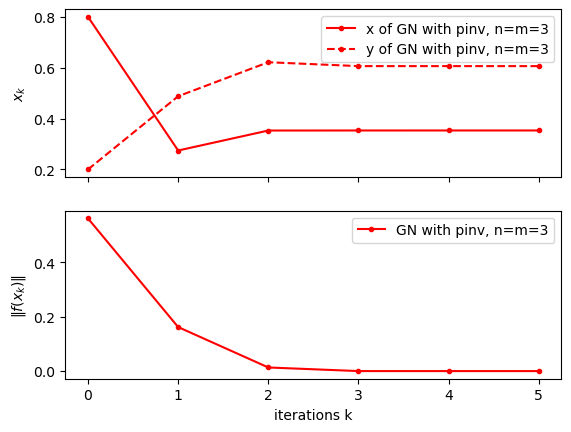

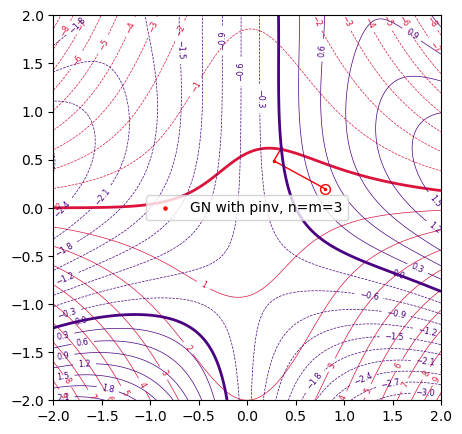

In [51]:
plot_cache = PlotCacheXk([
    cache_callback
    ])
figs = plot_cache.plot_2d(plot_mse=False)


x [0.35324662 0.60608174]
fx [0. 0.]
x [0.35324662 0.60608174]
fx [-1.11022302e-16  0.00000000e+00]
x [0.35324662 0.60608174]
fx [1.11022302e-16 0.00000000e+00]
x [0.35324662 0.60608174]
fx [1.11022302e-16 0.00000000e+00]


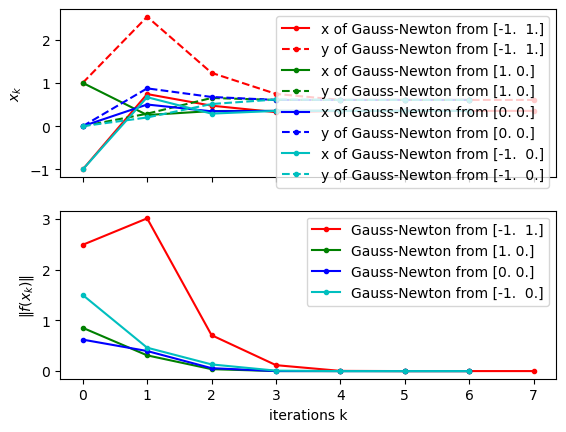

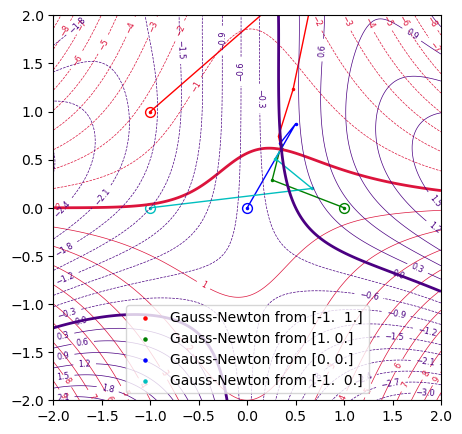

In [52]:
f = Function2D()

callback_list = []

x0_list = [
    np.array([-1.0, 1.0]),
    np.array([1.0, 0.0]),
    np.array([0.0, 0.0]),
    np.array([-1.0, 0.0]),
]
for x0 in x0_list:

    cache_callback = CacheXk(f, x0, f"Gauss-Newton from {x0}")

    x = gauss_newton_pinv(
        f,
        f.jac,
        x0,
        alpha=1.0,
        # maxiter=15,
        callback=cache_callback
    )
    print("x", x)
    print("fx", f(x))

    callback_list.append(cache_callback)

plot_cache = PlotCacheXk(callback_list)
figs = plot_cache.plot_2d()
# figs = plot_cache.plot_2d(plot_mse=True)

#### 1.6.3.2. <a id='toc1_6_3_2_'></a>[Gauss-Newton法に一致する例（$n=2, m=3$の場合）](#toc0_)

以下の実行例は$n=2, m=3$であるので，ヤコビ行列$J$は非正方行列であり，結果は擬似逆行列を用いない場合のGauss-Newton法に一致する．

x [0.362126   0.23827601]
fx [ 0.30824088 -0.06369297  0.20829457]
x [0.36212601 0.23827601]
fx [ 0.30824088 -0.06369297  0.20829457]
x [0.36212601 0.23827601]
fx [ 0.30824088 -0.06369297  0.20829457]
x [0.36212601 0.23827601]
fx [ 0.30824088 -0.06369297  0.20829457]


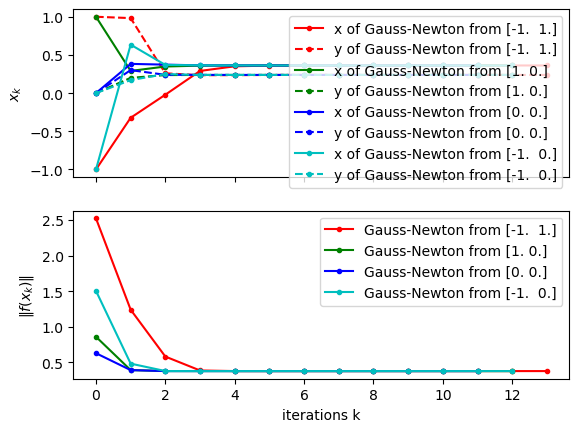

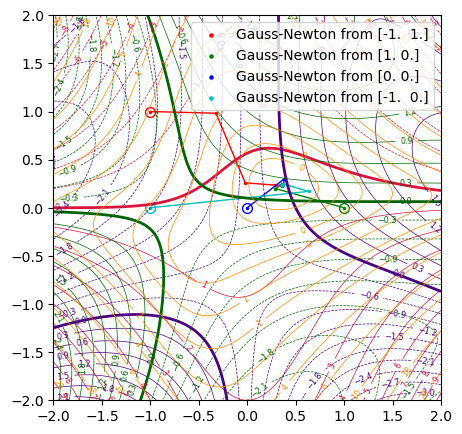

In [53]:
f = Function2D(m=3)

callback_list = []

x0_list = [
    np.array([-1.0, 1.0]),
    np.array([1.0, 0.0]),
    np.array([0.0, 0.0]),
    np.array([-1.0, 0.0]),
]
for x0 in x0_list:

    cache_callback = CacheXk(f, x0, f"Gauss-Newton from {x0}")

    x = gauss_newton_pinv(
        f,
        f.jac,
        x0,
        alpha=1.0,
        # maxiter=15,
        callback=cache_callback
    )
    print("x", x)
    print("fx", f(x))

    callback_list.append(cache_callback)

plot_cache = PlotCacheXk(callback_list)
figs = plot_cache.plot_2d(plot_mse=True)

### 1.6.4. <a id='toc1_6_4_'></a>[SVDと擬似逆行列](#toc0_)

上記で説明したように，最小二乗解および最小ノルム解のMoore-Penrose擬似逆行列は次のように表される．

- **最小二乗解**（$ m > n $ の場合）:
$$
A^+ = (A^T A)^{-1} A^T
$$
- **最小ノルム解**（$ m < n $ の場合）:
$$
A^+ = A^T (A A^T)^{-1}
$$

しかし，この2つを分けて考えると，どちらの問題であるかを判定しなければならず，統一的に扱うのが難しい．この問題を解決する方法が **特異値分解 (Singular Value Decomposition, SVD)** である．SVDを用いることで，どちらの場合でも擬似逆行列を統一的に構成できる．

#### 1.6.4.1. <a id='toc1_6_4_1_'></a>[SVDの復習](#toc0_)

$ A \in R^{m \times n} $ の特異値分解（thin SVD）は次のように表される．

$$
A = U W V^T
$$

ここで，

- $ p = \min(m, n) $は$ A $ の行数 $ m $ と列数 $ n $ の小さい方，
- $ U \in R^{m \times p} $は左特異ベクトルからなる（列）直交行列，
- $ V \in R^{n \times p} $は右特異ベクトルからなる（列）直交行列，
- $ W \in R^{p \times p} $は対角成分に特異値 $\sigma_1 \geq \sigma_2 \geq \dots \geq \sigma_p \geq 0$ を持つ対角行列
$$
W =
\begin{pmatrix}
\sigma_1 \\
& \sigma_2 \\
&& \ddots \\
&&& \sigma_p
\end{pmatrix}
$$

である．

ここで0でない特異値の個数を$p' \le p$
（つまり$\sigma_{p'+1} = \cdots = \sigma_p = 0$）とすると，
$$
W =
\begin{pmatrix}
\sigma_1 \\
& \ddots \\
&& \sigma_{p'} \\
&&& 0 \\
&&&& \ddots \\
&&&&& 0 \\
\end{pmatrix}
$$
である．
このとき，$U$と$V$は列直交なので
$\operatorname{rank}(U) = \operatorname{rank}(V) = p$であり，
$\operatorname{rank}(W) = p'$であるので，
$$
\operatorname{rank}(A) = p'
$$
つまり$A$のランクは0でない特異値の個数に等しい．


実際に，行列のランクを計算する`np.linalg.matrix_rank()`は，
内部でSVDを用いており，特異値のうち，しきい値（`tol`）より大きいものの個数をランクとして返す．

- https://numpy.org/doc/stable/reference/generated/numpy.linalg.matrix_rank.html
    > Return matrix rank of array using SVD method.
    > Rank of the array is the number of singular values of the array that are greater than tol.

以下はランダムな行列のランクを計算する例である．

In [54]:
with np.printoptions(formatter={'float': '{: 12.8f}'.format}, suppress=True, linewidth=1000):
    m = 4
    n = 5
    A = rng.random(size=(m, n))
    print("A\n", A, sep="")
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    print("singular values", s)

    print("rank(A)", matrix_rank(A))
    print("rank(A), tol=0.5", matrix_rank(A, tol=0.5))

A
[[  0.54967488   0.03680519   0.70348035   0.73738718   0.67983267]
 [  0.30272522   0.61934636   0.21666661   0.36655208   0.49458550]
 [  0.83576392   0.28424609   0.85922605   0.68461166   0.39830154]
 [  0.08981689   0.04400267   0.32054796   0.89676414   0.20577533]]
singular values [  2.24558039   0.62657452   0.53295276   0.30061292]
rank(A) 4
rank(A), tol=0.5 3


#### 1.6.4.2. <a id='toc1_6_4_2_'></a>[フルランクの場合](#toc0_)

$p' = p$のとき，つまり全ての特異値が0よりも大きい場合には，

- 優決定（$m > n$）のときは$A^T A \in R^{n \times n}$がフルランク（つまり$\mathrm{rank}(A^T A) = n$）になり，
- 劣決定（$m < n$）のときは$A A^T \in R^{m \times m}$がフルランク（$\mathrm{rank}(A A^T) = m$）になる．

そのため，どちらの場合でも
$$
A = U W V^T
$$
の擬似逆行列は
$$
A^+ = V W^{-1} U^T
$$
と書ける．
以下で具体的に検証してみる．

##### 1.6.4.2.1. <a id='toc1_6_4_2_1_'></a>[優決定（$m > n$）の場合](#toc0_)

この場合の擬似逆行列は$(A^T A)^{-1} A^T$であるが，
この場合には$V \in R^{n \times n}$であり，したがって$V^T V = V V^T = I$より，
\begin{align*}
(A^T A)^{-1} A^T
&=
((U W V^T)^T (U W V^T))^{-1} (U W V^T)^T
\\
&=
(V W U^T U W V^T)^{-1} V W U^T
\\
&=
(V W^2 V^T)^{-1} V W U^T
\\
&=
V W^{-2} V^T V W U^T
\\
&=
V W^{-1} U^T
\end{align*}


##### 1.6.4.2.2. <a id='toc1_6_4_2_2_'></a>[劣決定（$m < n$）の場合](#toc0_)

この場合の擬似逆行列は$A^T (A A^T)^{-1}$であるが，
この場合には$U \in R^{m \times m}$であり，したがって$U^T U = U U^T = I$より，
\begin{align*}
A^T (A A^T)^{-1}
&=
(U W V^T)^T ((U W V^T) (U W V^T)^T)^{-1}
\\
&=
V W U^T (U W V^T V W U^T)^{-1}
\\
&=
V W U^T (U W^2 U^T)^{-1}
\\
&=
V W U^T U W^{-2} U^T
\\
&=
V W^{-1} U^T
\end{align*}


#### 1.6.4.3. <a id='toc1_6_4_3_'></a>[ランク落ちの場合](#toc0_)


$p' < p$ のとき，つまりいくつかの特異値が0の場合について説明する．
この場合，行列 $A$ はフルランクではなく，ランク落ちしている（つまり$\mathrm{rank}(A) < \min(n, m)$）．

このとき，
$$
A = U W V^T
$$
の擬似逆行列は次のように表される（証明略）．
$$
A^+ = V W^+ U^T
$$

ここで
$$
W^+ =
\begin{pmatrix}
1/\sigma_1 \\
& \ddots \\
&& 1/\sigma_{p'} \\
&&& 0 \\
&&&& \ddots \\
&&&&& 0 \\
\end{pmatrix}
\in R^{p \times p}
$$
である．つまり0の特異値は0のままであり，それ以外は$W$の対角要素を逆数にした行列である．

- [Gene H. Golub, Charles F. Van Loan, Matrix Computations, 4th edition, Johns Hopkins Univ Press, 2012](https://www.press.jhu.edu/books/title/10678/matrix-computations), p.290, 5.5.2, A Note on the Pseudoinverse
- [柳井晴夫, 竹内啓, 射影行列・一般逆行列・特異値分解　新装版, UP応用数学選書10, 東京大学出版会, 2018](https://www.utp.or.jp/book/b375477.htmlv), p.122, 特異値分解と一般逆行列, 定理5.6
- [岩波数学辞典, 第4版, 岩波書店, 2007.](https://www.iwanami.co.jp/book/b256653.html), 140.N 特異値の数値解法, p.391


このように，行列 $A$ がランク落ちしている場合でも，特異値分解を用いて統一的に擬似逆行列 $A^+$ を構成することができる．

#### 1.6.4.4. <a id='toc1_6_4_4_'></a>[scipyとnumpyの実装](#toc0_)

前述した`scipy.linalg.pinv()`と`numpy.linalg.pinv()`は
Moore-Penrose擬似逆行列を計算するために，特異値分解を利用する．
これらの関数では，特異値の大きさにしきい値を設定して，そのしきい値よりも（相対的に）小さい特異値は0にする．

以下のマニュアルの記述のとおり，具体的なしきい値の挙動は関数によって異なる．`np.linalg.pinv()`の場合には，引数`rcond`と最大特異値との積がしきい値であり，それよりも小さい特異値は0に打ち切られる．

- https://numpy.org/doc/stable/reference/generated/numpy.linalg.pinv.html
  > Compute the (Moore-Penrose) pseudo-inverse of a matrix.
  - 引数`rcond`
    > rcond :
    > Cutoff for small singular values. Singular values less than or equal to rcond * largest_singular_value are set to zero. Broadcasts against the stack of matrices.
- 一般行列用：https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.pinv.html
  > Compute the (Moore-Penrose) pseudo-inverse of a matrix.
  > If s is the maximum singular value of a, then the significance cut-off value is determined by atol + rtol * s. Any singular value below this value is assumed insignificant.
  - 引数`atol`, `rtol`：絶対・相対許容誤差
  - 引数`return_rank=True`：ランクを返す
- 対称行列用：https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.pinvh.html
  > Compute the (Moore-Penrose) pseudo-inverse of a Hermitian matrix.
  > Calculate a generalized inverse of a complex Hermitian/real symmetric matrix using its eigenvalue decomposition and including all eigenvalues with ‘large’ absolute value
  - 引数`atol`, `rtol`：絶対・相対許容誤差
  - 引数`return_rank=True`：ランクを返す


以下のコードは，`np.linalg.pinv()`の引数`rcond`に0.5を設定して求めた擬似逆行列と，`np.linalg.pinv()`の挙動通りにしきい値を設定して計算した擬似逆行列とが一致していることを確認している．

In [55]:
with np.printoptions(formatter={'float': '{: 12.8f}'.format}, suppress=True, linewidth=1000):

    m = 3
    n = 5
    A = rng.random(size=(m, n))
    print("A\n", A, sep="")
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    W = diag(s)
    print("singular values", s)
    print("A == U W V^T", np.allclose(A, U @ W @ Vt))

    # デフォルト設定で擬似逆行列を計算
    Apinv = np.linalg.pinv(A)
    print("A^+\n", Apinv, sep="")
    print("A^+ == V W^{-1} U^T", np.allclose(Apinv, Vt.T @ diag(1 / s) @ U.T))

    # しきい値 rcond を設定して擬似逆行列を計算
    rcond = 0.5
    Apinv = np.linalg.pinv(A, rcond=rcond)
    print("A^+\n", Apinv, sep="")
    print("singular values", s)

    # しきい値で特異値を打ち切り（最大特異値のrcond倍よりも小さいものは0にする）
    inv_s_truncated = np.array([1 / sv if sv > s[0] * rcond else 0 for sv in s])
    print("1 / singular values", inv_s_truncated)
    Apinv2 = Vt.T @ diag(inv_s_truncated) @ U.T
    # 2つの擬似逆行列が正しいか確認
    print("A^+ == V W^{-1} U^T", np.allclose(Apinv, Apinv2))


A
[[  0.00689348   0.23728324   0.22979071   0.41726168   0.67758808]
 [  0.03113263   0.31570427   0.98846533   0.48942517   0.10221730]
 [  0.08128860   0.75708926   0.93673346   0.67786465   0.43162714]]
singular values [  1.93064568   0.62423422   0.23680791]
A == U W V^T True
A^+
[[ -0.25492148  -0.32480470   0.39468560]
 [ -1.41159972  -2.21870533   2.63980908]
 [  0.04177800   1.57243488  -0.72782163]
 [  0.49730014   0.30721514  -0.13268391]
 [  1.65233390   0.05782361  -0.59991115]]
A^+ == V W^{-1} U^T True
A^+
[[  0.00761487   0.01222360   0.01616526]
 [  0.07803816   0.12526897   0.16566359]
 [  0.12628989   0.20272395   0.26809496]
 [  0.08768511   0.14075451   0.18614266]
 [  0.05834653   0.09365943   0.12386115]]
singular values [  1.93064568   0.62423422   0.23680791]
1 / singular values [  0.51796143   0.00000000   0.00000000]
A^+ == V W^{-1} U^T True


## 1.7. <a id='toc1_7_'></a>[$A \boldsymbol{x} = 0$](#toc0_)

最後に，右辺が0である線形連立方程式の特殊な場合について述べておく．
これまで扱っていた連立方程式は$A \boldsymbol{x} = \boldsymbol{b}$であるが，
ここでは右辺が $\boldsymbol{b} = \boldsymbol{0}$ の場合を考える．

つまり右辺が0の，以下の連立方程式を考える．
$$
A \boldsymbol{x} = 0
$$

この方程式の自明な解は $\boldsymbol{x} = \boldsymbol{0}$ であるが，
行列 $A$ が **フルランクではない場合** には，
非自明な解（$\boldsymbol{x} \neq \boldsymbol{0}$）が存在する．

しかし，これまでの解法を利用しようとしても，まったく使えない．


### 1.7.1. <a id='toc1_7_1_'></a>[連立方程式の解法](#toc0_)

#### 1.7.1.1. <a id='toc1_7_1_1_'></a>[最小二乗解](#toc0_)

最小二乗解を求めようとすると，正規方程式は次のようになる．
$$
A^T A \boldsymbol{x} = 0
$$
これは右辺が0であるため，
これを解く方法を考えるのは堂々巡りである．

#### 1.7.1.2. <a id='toc1_7_1_2_'></a>[リッジ回帰](#toc0_)

さらに，以下のようにリッジ回帰の正則化を導入しても，
$$
(A^T A + \lambda I ) \boldsymbol{x} = 0
$$
となり，状況は同じである．

#### 1.7.1.3. <a id='toc1_7_1_3_'></a>[最小ノルム解](#toc0_)

最小ノルム解を考えても次のようになる．
\begin{align*}
\boldsymbol{x} &= -A^T \boldsymbol{\lambda} \\
A A^T \boldsymbol{\lambda} &= 0 \\
\end{align*}



### 1.7.2. <a id='toc1_7_2_'></a>[勾配法による最適化](#toc0_)

それでは
$\min_{\boldsymbol{x}} f(\boldsymbol{x}) = \frac{1}{2} \| A \boldsymbol{x} \|^2$
という最適化問題を考えてみる．


#### 1.7.2.1. <a id='toc1_7_2_1_'></a>[ニュートン法](#toc0_)

ところがニュートン法を適用すると，自明な解しか得られない．

目的関数を変形すると
\begin{align*}
f(\boldsymbol{x}) &= \frac{1}{2} \| A \boldsymbol{x} \|^2
= \frac{1}{2} \boldsymbol{x}^T A^T A \boldsymbol{x}
\end{align*}
となり，勾配ベクトルとヘッセ行列は以下のようになる．
\begin{align*}
\nabla f(\boldsymbol{x}) &= A^T A \boldsymbol{x} \\
\nabla^2 f(\boldsymbol{x}) &= A^T A
\end{align*}
これを用いると，ニュートン法の更新式は以下のようになる．
\begin{align*}
\boldsymbol{x}^{(k+1)} &= \boldsymbol{x}^{(k)} - (A^T A)^{-1} A^T A \boldsymbol{x}^{(k)} \\
&= \boldsymbol{x}^{(k)} - \boldsymbol{x}^{(k)} \\
&= \boldsymbol{0}
\end{align*}

#### 1.7.2.2. <a id='toc1_7_2_2_'></a>[ニュートン法＋固定ステップサイズ](#toc0_)

ステップサイズを使う場合でも，以下のようになる．
\begin{align*}
\boldsymbol{x}^{(k+1)} &= \boldsymbol{x}^{(k)} - \alpha (A^T A)^{-1} A^T A \boldsymbol{x}^{(k)} \\
&= \boldsymbol{x}^{(k)} - \alpha \boldsymbol{x}^{(k)} \\
&= (1 - \alpha) \boldsymbol{x}^{(k)} \\
&= (1 - \alpha)^{(k+1)} \boldsymbol{x}^{(0)}
\end{align*}

これは以下の3つの場合がある．

- **$\alpha = 0$**：初期値$\boldsymbol{x}^{(0)}$から変化しない．
- **$0 < \alpha < 1$**：$\boldsymbol{x}$ は$\boldsymbol{0}$に収束する．
- **$\alpha > 1$**：$\boldsymbol{x}$ は発散する．

この式からわかるように，$\alpha$ の選び方に関わらず，非自明な解は得られれない．



#### 1.7.2.3. <a id='toc1_7_2_3_'></a>[最急降下法](#toc0_)

単純な最急降下法を考えたとしても，同様である．

最急降下法の更新式は次のようになる．
\begin{align*}
\boldsymbol{x}^{(k+1)}
&= \boldsymbol{x}^{(k)} - \alpha A^T A \boldsymbol{x}^{(k)} \\
&= (I - \alpha A^T A) \boldsymbol{x}^{(k)} \\
&= (I - \alpha A^T A)^{(k+1)} \boldsymbol{x}^{(0)}
\end{align*}

この式に行列ノルムの性質（$\| A \boldsymbol{x} \| \le \| A \| \| \boldsymbol{x} \|$
）を適用すると，以下の式が得られる．

\begin{align*}
\| \boldsymbol{x}^{(k+1)} \|
&\le \|I - \alpha A^T A\|^{k+1} \| \boldsymbol{x}^{(0)} \| \\
\end{align*}


ここで$A^T A$の最大・最小固有値を$\lambda_{1}, \lambda_{n}$とすると，
行列ノルム（2ノルム）は
\begin{align*}
\|I - \alpha A^T A\|
&= \max (
    |1 - \alpha \lambda_{1}|,
    |1 - \alpha \lambda_{n}|
    )
\end{align*}
となる．
したがって，$\alpha$ の選び方に関わらず，解のノルム$\| \boldsymbol{x}^{(k+1)} \|$は0に収束するか発散する．

$A^T A$の対角化を$U \Sigma U^T$とすると以下のことがわかる．
\begin{align*}
I - \alpha A^T A
&= I - \alpha U \Sigma U^T \\
&= U (I - \alpha \Sigma) U^T \\
&= U D U^T
\end{align*}
したがって
\begin{align*}
\boldsymbol{x}^{(k+1)} &= U D^{k+1} U^T \boldsymbol{x}^{(0)} \\
U^T \boldsymbol{x}^{(k+1)} &= D^{k+1} U^T \boldsymbol{x}^{(0)} \\
\end{align*}
つまり固定の$U$において$U \boldsymbol{x}^{(0)}$の各要素を$D^{k+1}$で定数倍したものが$U \boldsymbol{x}^{(k+1)}$なので，
$\alpha$ の選び方に関わらず，要素は0に収束するか発散する．

### 1.7.3. <a id='toc1_7_3_'></a>[解：最小固有値に対応する固有ベクトル](#toc0_)


ここで連立方程式 $A \boldsymbol{x} = \boldsymbol{0}$ に対して非自明な解を求めるため，
与えられた行列 $A$ に対して，次の最適化問題を考える．
$$
\min_{\boldsymbol{x}} \boldsymbol{x}^T A^T A \boldsymbol{x} \quad \text{s.t.} \quad \| \boldsymbol{x} \|_2^2 = 1.
$$
ここで$\| \boldsymbol{x} \|=1$という制約は，
もともとの連立方程式において右辺が0であるため，$x$のノルムは不定であるためである．

この問題は，主成分分析のときに見たものと同じである．
つまり解$\boldsymbol{x}$は，$A^T A$の固有ベクトル（つまり$A$の特異ベクトル）である．


$A^T A$の固有値を$\lambda$（これは$A$の特異値の2乗）とすると，以下の式が成り立つ．
$$
\boldsymbol{x}^T A^T A \boldsymbol{x} = \lambda
$$
このうち最小のものは最小固有値$\lambda_n$であるので，
求める解$\boldsymbol{x}$は，$\lambda_n$に対応する固有ベクトルである（なお，重複を含めて考える）．

$A^T A$の最小固有値$\lambda_n$が0か否かによって，以下の2つの場合が存在する．

- $\lambda_n=0$：この場合，$A$はランク落ちしており，制約$\| \boldsymbol{x} \|=1$を満たす非自明な解$\boldsymbol{x}$が得られる．
- $\lambda_n > 0$：この場合には，制約を満たす非自明な解は存在しない．得られた近似解$\boldsymbol{x}$は，与えられた方程式を満たさない（$\| A \boldsymbol{x} \|^2 \neq \boldsymbol{0}$）が，$\| A \boldsymbol{x} \|^2$の最小解である．


以下のコードでは，
ランク落ちしている行列`A2`の場合には制約を満たす非自明な解が得られていることを確認している．
一方，フルランクである行列`A1`の場合には，得られた解は方程式を満たしていない（$\| A \boldsymbol{x} \|^2 \neq \boldsymbol{0}$）ことがわかる．


In [56]:
with np.printoptions(formatter={'float': '{: 12.8f}'.format}, suppress=True, linewidth=1000):

    # 行列Aのランクは5（フルランク）
    m = 10
    n = 5
    A1 = rng.random(size=(m, n))  # rank(A1) == n

    # 行列A2のランクは4（ランク落ち）
    a_rank = n - 1
    U, s, Vt = np.linalg.svd(A1, full_matrices=False)
    s[a_rank:] = 0  # lambda_n = 0
    A2 = U @ diag(s) @ Vt  # rank(A2) == n-1

    b = np.zeros(m)

    for A in [A1, A2]:
        print("rank(A)", np.linalg.matrix_rank(A))

        print("==== lstsq ====")
        solusion = np.linalg.lstsq(A, b)
        x = solusion[0]  # 最小二乗解または最小ノルム解
        print("x", x)    # 自明な解0しか得られない
        print("Ax", A @ x)
        print("||Ax||", norm(A @ x))

        print("==== eigh ====")
        d, U = np.linalg.eigh(A.T @ A)
        x = U[:, 0]  # 最小固有値に対応する固有ベクトル
        print("x", x)
        print("Ax", A @ x)
        print("||Ax||", norm(A @ x))

        print("==== svd ====")
        U, s, Vt = np.linalg.svd(A)
        x = Vt[-1]   # 最小特異値に対応する特異値ベクトル
        print("x", x)
        print("Ax", A @ x)
        print("||Ax||", norm(A @ x))

        print()

rank(A) 5
==== lstsq ====
x [  0.00000000   0.00000000   0.00000000   0.00000000   0.00000000]
Ax [  0.00000000   0.00000000   0.00000000   0.00000000   0.00000000   0.00000000   0.00000000   0.00000000   0.00000000   0.00000000]
||Ax|| 0.0
==== eigh ====
x [  0.10623192  -0.48297153  -0.19182840  -0.49660690   0.68704929]
Ax [ -0.07528183   0.11757013   0.19923719  -0.09209131  -0.05718652  -0.12189310  -0.08146801  -0.01894854   0.00693547   0.06725177]
||Ax|| 0.3120281517753122
==== svd ====
x [ -0.10623192   0.48297153   0.19182840   0.49660690  -0.68704929]
Ax [  0.07528183  -0.11757013  -0.19923719   0.09209131   0.05718652   0.12189310   0.08146801   0.01894854  -0.00693547  -0.06725177]
||Ax|| 0.3120281517753121

rank(A) 4
==== lstsq ====
x [  0.00000000   0.00000000   0.00000000   0.00000000   0.00000000]
Ax [  0.00000000   0.00000000   0.00000000   0.00000000   0.00000000   0.00000000   0.00000000   0.00000000   0.00000000   0.00000000]
||Ax|| 0.0
==== eigh ====
x [  0.106231

なお$A \boldsymbol{x} = \boldsymbol{0}$を解くだけであれば，最小固有値に対応する固有ベクトルだけを求めれば良い．そのため，計算量の多い特異値分解や固有値分解を用いる必要はなく，逆反復法だけで求めることもできる．


In [57]:
def inverse_iteration(
    A: np.ndarray,
    maxiter: int = 5000,
) -> Tuple[float, np.ndarray]:
    """
    逆反復法によって行列Aの最小固有値に対応する固有ベクトルを求める

    Args:
        A (np.ndarray): nxnの正方行列
        maxiter (int, optional): 最大反復回数. デフォルトは5000.

    Returns:
        Tuple[float, np.ndarray]: 最小固有値とその固有ベクトル
    """
    assert A.ndim == 2
    assert A.shape[0] == A.shape[1]
    n = A.shape[0]
    u = np.ones(n)

    LU, pivot = scipy.linalg.lu_factor(A)

    Au = u
    u_pre = u.copy()
    for i in range(maxiter):
        u = Au
        u /= norm(u)
        Au = scipy.linalg.lu_solve((LU, pivot), u)

        with np.printoptions(formatter={'float': '{: 12.12f}'.format}, suppress=True, linewidth=100):
            print(f"{i:2d}", u)

        if np.allclose(u, u_pre) or np.allclose(u, -u_pre):
            break
        u_pre = u.copy()

    l = u.T @ A @ u
    return l, u


In [58]:
with np.printoptions(formatter={'float': '{: 12.8f}'.format}, suppress=True, linewidth=1000):
    _, x = inverse_iteration(A.T @ A)
    print("x", x)
    print("Ax", A @ x)
    print("||Ax||", norm(A @ x))

 0 [ 0.447213595500  0.447213595500  0.447213595500  0.447213595500  0.447213595500]
 1 [ 0.106231924525 -0.482971533871 -0.191828395885 -0.496606903352  0.687049289176]
 2 [-0.106231924525  0.482971533871  0.191828395885  0.496606903352 -0.687049289176]
x [ -0.10623192   0.48297153   0.19182840   0.49660690  -0.68704929]
Ax [  0.00000000   0.00000000   0.00000000   0.00000000   0.00000000  -0.00000000  -0.00000000   0.00000000   0.00000000   0.00000000]
||Ax|| 4.484050470211362e-16
